This notebook is used to analyze the temporal evolution of disease trajectories

In [1]:
import pandas as pd
import pickle as pk
import networkx as nx
import collections
import random as rd
import itertools as it
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import gseapy as gp
from gseapy import dotplot


In [2]:
#Now, let's compute how similar these two genesets are:
def overlap_genelists(lstA, lstB):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= G_ppi.number_of_nodes() #total number of genes
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))

    return str(stats.hypergeom.sf(x-1, M, n, N))

import scipy  
from scipy import stats

#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

def reduce_dict(input_dict):
    # Initialize an empty set to keep track of seen lists
    seen = set()
    result = {}
    
    for key, value in input_dict.items():
        # Convert the list to a frozenset for comparison (order-independent and hashable)
        current_set = frozenset(value)
        
        # If the set has not been seen before, add it to the result
        if current_set not in seen:
            result[key] = value
            # Add the set to the seen sets
            seen.add(current_set)
    
    return result
    
#Let's calculate the Cohen's d as an effect size
def calculate_ttest_and_effect_size(list1, list2):
    from scipy import stats
    import numpy as np
    t_value, p_value = stats.ttest_ind(list1, list2)

    n1 = len(list1)
    n2 = len(list2)
    dof = n1 + n2 - 2

    mean1 = np.mean(list1)
    mean2 = np.mean(list2)
    var1 = np.var(list1, ddof=1)
    var2 = np.var(list2, ddof=1)

    pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / dof
    effect_size = (mean1 - mean2) / np.sqrt(pooled_var)

    return t_value, p_value, effect_size

def net_modularity(genelist,network):
    geneset=set(genelist)&network.nodes()
    if len(geneset)>2:
        G_sub = nx.subgraph(network,geneset)
        Gsub_lcc = G_sub.subgraph(max(nx.connected_components(G_sub), key=len))  # extract lcc graph
        number_of_connected_component=Gsub_lcc.number_of_nodes()
        f_lcc_size = Gsub_lcc.number_of_nodes()
        l_random_lccs = []
        S = 1000
        for s in range(S):
            gene_sample = rd.sample(list(network.nodes()),len(geneset))
            G_sub_rnd = nx.subgraph(network,gene_sample)
            G_sub_rnd_lcc = G_sub_rnd.subgraph(max(nx.connected_components(G_sub_rnd), key=len))  # extract lcc graph
            lcc_size = G_sub_rnd_lcc.number_of_nodes()
            l_random_lccs.append(lcc_size)
        mu = np.mean(l_random_lccs)
        std = np.std(l_random_lccs)
        z = (f_lcc_size-mu)/std
    else:
        number_of_connected_component=0
        z='nan'
    return z

#Enrichment time

def enrichment_from_genelist(gene_list,libraries):   #This function returns the enrichment df for GOBP,GOCC,GOMF,KeGG  
    import gseapy as gp
    enr_df_dict={}
    for l in libraries:
        enr_df = gp.enrichr(gene_list=gene_list,
                             gene_sets=l,
                             organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                             outdir=None, # don't write to disk
                            )
        enr_df_dict[l]=enr_df

    return enr_df_dict

lib_list=['GO_Biological_Process_2025','GO_Molecular_Function_2025','GO_Cellular_Component_2025','KEGG_2021_Human']



In [3]:
male_trajectories_df=pd.read_excel('input/All identified trajectories in males. trajectories smaller than 100 members.xlsx')

In [99]:
with open('output/male_trajectories_dict_filtered_v2026_official.pickle', 'rb') as handle:
    male_trajectories_dict_filtered = pk.load(handle)

with open('output/male_trajectories_dict_filtered_unique_v2026_official.pickle', 'rb') as handle:
    male_trajectories_dict_filtered_unique = pk.load(handle)

with open('output/male_trajectories_dict_filtered_unique_agglomerated_genes_v2026_official.pickle', 'rb') as handle:
    male_trajectories_dict_filtered_unique_agglomerated_genes = pk.load(handle)


In [5]:
diverge_pairs_male_df = pd.read_csv("input/Diverge_Pairs/Diverge_Pairs_Males.csv")

In [6]:
diverge_pairs_female_df = pd.read_csv("input/Diverge_Pairs/Diverge_Pairs_Females.csv")

In [7]:

male_diverge_pairs_dict_dis_differences = {}
for i,v in diverge_pairs_male_df.iterrows():
    dis_difference_1 = []
    dis_difference_2 = []
    trj_1 = v['Cluster1'].replace("__","-")
    trj_2 = v['Cluster2'].replace("__","-")
    new_trj_1 = trj_1.replace(" ","")
    new_trj_2 = trj_2.replace(" ","")
    dis_list_trj_1 = []
    for distim in new_trj_1.split(","):
        dis_list_trj_1.append(distim.split("-")[0])
    dis_list_trj_2 = []
    for distim in new_trj_2.split(","):
        dis_list_trj_2.append(distim.split("-")[0])
    for dis in dis_list_trj_1:
        if dis not in dis_list_trj_2:
            dis_difference_1.append(dis)
    for dis in dis_list_trj_2:
        if dis not in dis_list_trj_1:
            dis_difference_2.append(dis)
    if len(set(dis_difference_1))>0 and len(set(dis_difference_2))>0:
        male_diverge_pairs_dict_dis_differences[i]=[set(dis_difference_1),set(dis_difference_2)]




In [60]:

#Here, we define the PPI
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')
#Let's import the Elma diseases
#Let's import the ICD-gene associations
with open('output/allsources_icd_gene_dict_unified_v2026_official.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)
    
icd_genes_ppi_dict={}

for dis,genelist in allsources_icd_gene_dict_unified.items():
    new_genelist=set(genelist)&G_ppi.nodes()
    if len(new_genelist)>0:
        icd_genes_ppi_dict[dis]=new_genelist

print(len(icd_genes_ppi_dict))


759


In [13]:
#Let's try to extract the genes that are representative of these differences

male_diverge_pairs_dict_gene_differences = {}
for idx,div_pair_list in male_diverge_pairs_dict_dis_differences.items():
    gene_list_1 = []
    gene_list_2 = []
    for dis in div_pair_list[0]:
        try:
            for gene in icd_genes_ppi_dict[dis]:
                if gene not in gene_list_1:
                    gene_list_1.append(gene)
        except:
            pass
    for dis in div_pair_list[1]:
        try:
            for gene in icd_genes_ppi_dict[dis]:
                if gene not in gene_list_2:
                    gene_list_2.append(gene)
        except:
            pass
    male_diverge_pairs_dict_gene_differences[idx]=[set(gene_list_1),set(gene_list_2)]
    

In [ ]:
male_diverge_pairs_dict_gene_differences_pval = {}
male_diverge_pairs_dict_gene_differences_fdr = {}


for idx,geneset_list in male_diverge_pairs_dict_gene_differences.items():
    pval_ov = float(overlap_genelists(geneset_list[0],geneset_list[1]))
    male_diverge_pairs_dict_gene_differences_pval[idx] = pval_ov

adj_pval=fdr_adjustment(list(male_diverge_pairs_dict_gene_differences_pval.values()),0.05)
pair_list=list(male_diverge_pairs_dict_gene_differences_pval.keys())
for i in range(len(adj_pval)):
    male_diverge_pairs_dict_gene_differences_fdr[pair_list[i]]=adj_pval[i]
print(len([trj for trj in male_diverge_pairs_dict_gene_differences_fdr.keys() if male_diverge_pairs_dict_gene_differences_fdr[trj]<0.05]))
print(len(male_diverge_pairs_dict_gene_differences))
#23 out of 30 trajectories show gene similarities between the two possibilities

23
30


In [15]:
#Let's check for the degree in the PPI
male_diverge_pairs_dict_gene_degree_differences = {}
for idx,genesetlist in male_diverge_pairs_dict_gene_differences.items():
    deg_list_1 = []
    deg_list_2 = []
    for gene in genesetlist[0]:
        deg_list_1.append(G_ppi.degree(gene))
    for gene in genesetlist[1]:
        deg_list_2.append(G_ppi.degree(gene))
    male_diverge_pairs_dict_gene_degree_differences[idx]=[deg_list_1,deg_list_2]
        

In [16]:
#Let's see whether there are differences in degree by performing a Mann-Withney test


male_diverge_pairs_dict_gene_degree_differences_pval = {}
male_diverge_pairs_dict_gene_degree_differences_fdr = {}

for idx,deg_list in male_diverge_pairs_dict_gene_degree_differences.items():
    try:
        t, p = stats.mannwhitneyu(deg_list[0], deg_list[1])
        male_diverge_pairs_dict_gene_degree_differences_pval[idx] = float(p)
    except:
        pass

adj_pval=fdr_adjustment(list(male_diverge_pairs_dict_gene_degree_differences_pval.values()),0.05)
pair_list=list(male_diverge_pairs_dict_gene_degree_differences_pval.keys())
for i in range(len(adj_pval)):
    male_diverge_pairs_dict_gene_degree_differences_fdr[pair_list[i]]=adj_pval[i]
    
print(len([trj for trj in male_diverge_pairs_dict_gene_degree_differences_fdr.keys() if male_diverge_pairs_dict_gene_degree_differences_fdr[trj]<0.05]))

#Most of these trajectories are statistically significantly different for degree

5


In [22]:
#Let's try with keeping the gene repetition

male_diverge_pairs_dict_gene_degree_differences_pval = {}
male_diverge_pairs_dict_gene_degree_differences_fdr = {}
male_diverge_pairs_dict_gene_degree_differences = {}
for trj,trj_dis_set in male_diverge_pairs_dict_dis_differences.items():
    genelist_1 = []
    genelist_2 = []
    for dis in trj_dis_set[0]:
        try:
            genelist_1.extend(icd_genes_ppi_dict[dis])
        except:
            pass
    for dis in trj_dis_set[1]:
        try:
            genelist_2.extend(icd_genes_ppi_dict[dis])
        except:
            pass
    genelist_1_deg = [G_ppi.degree(gene) for gene in genelist_1]
    genelist_2_deg = [G_ppi.degree(gene) for gene in genelist_2]
    try:
        male_diverge_pairs_dict_gene_degree_differences[trj] = [genelist_1_deg,genelist_2_deg]
        t, p = stats.mannwhitneyu(genelist_1_deg, genelist_2_deg)
        if str(p)!='nan':
            male_diverge_pairs_dict_gene_degree_differences_pval[trj] = float(p)
    except:
        pass


adj_pval=fdr_adjustment(list(male_diverge_pairs_dict_gene_degree_differences_pval.values()),0.05)
pair_list=list(male_diverge_pairs_dict_gene_degree_differences_pval.keys())
for i in range(len(adj_pval)):
    male_diverge_pairs_dict_gene_degree_differences_fdr[pair_list[i]]=adj_pval[i]
    
print(len([trj for trj in male_diverge_pairs_dict_gene_degree_differences_fdr.keys() if male_diverge_pairs_dict_gene_degree_differences_fdr[trj]<0.05]))



5


In [23]:
male_diverge_pairs_dict_gene_degree_differences_fdr

{0: 0.33846937021792245,
 1: 0.445337142133473,
 2: 0.445337142133473,
 3: 7.989703340165283e-05,
 4: 0.005718736537172242,
 5: 0.1138590002301172,
 6: 0.00014890123517127756,
 7: 0.04979539838481448,
 9: 0.08792035619673218,
 10: 0.15073809906086993,
 11: 0.26361389340253794,
 13: 0.5395004548444836,
 14: 0.26361389340253794,
 15: 0.08792035619673218,
 17: 0.08792035619673218,
 19: 0.445337142133473,
 20: 0.26361389340253794,
 22: 0.26361389340253794,
 23: 0.17401647803417356,
 24: 0.08792035619673218,
 25: 0.30992914577159897,
 26: 0.024433053689715132,
 28: 0.7526327471857227,
 29: 0.777865341327376,
 30: 0.445337142133473,
 31: 0.08792035619673218,
 32: 0.445337142133473,
 33: 0.7526327471857227,
 34: 0.445337142133473}

In [24]:
len(male_diverge_pairs_dict_dis_differences[6][1])

3

In [25]:
len(male_diverge_pairs_dict_dis_differences[6][0])

2

In [26]:
male_diverge_pairs_dict_dis_differences[6][0]

{'C61', 'D40'}

In [27]:
male_diverge_pairs_dict_dis_differences[6][1]

{'N21', 'N41', 'N42'}

In [28]:
diverge_pairs_male_df.loc[6]['Cluster1']

'C61-40-49, N32-40-49, N40-40-49, C61-50-59, D40-50-59, N32-50-59'

In [29]:
diverge_pairs_male_df.loc[6]['Cluster2']

'N32-40-49, N40-40-49, N41-40-49, N21-50-59, N40-50-59, N41-50-59, N42-50-59, N41-60-69, N42-60-69'

In [30]:
np.median(male_diverge_pairs_dict_gene_degree_differences[6][1])

23.0

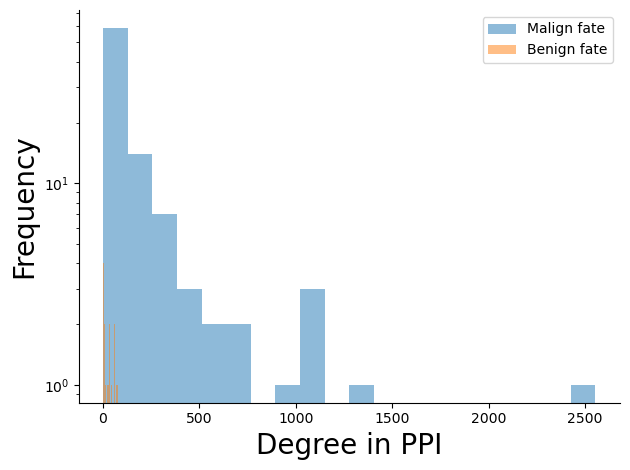

In [32]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Malign fate',
        'Benign fate']

plt.xlabel('Degree in PPI',fontsize=20)
comparing_group_list= [male_diverge_pairs_dict_gene_degree_differences[6][0],male_diverge_pairs_dict_gene_degree_differences[6][1]]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
# Plot histogram for each list in comparing_group_list
num_bins = 20  # Choose an appropriate number of bins for your data
for data, label in zip(comparing_group_list, labels):
    # Create a histogram for each set of data
    counts, bins, patches = ax1.hist(data, num_bins, label=label, alpha=0.5)
plt.yscale("log")
plt.ylabel("Frequency",fontsize=20)
ax1.legend()  # Add a legend if you want to label each histogram
plt.tight_layout()
plt.savefig('Figures/Divergent_Trj_Degree_Distribution_Example_2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [193]:

malign_data = male_diverge_pairs_dict_gene_degree_differences[6][0]
benign_data = male_diverge_pairs_dict_gene_degree_differences[6][1]

all_data = np.concatenate([malign_data, benign_data])

# -----------------------------
# 2. Define shared bins (important!)
# -----------------------------
num_bins = 20
counts_all, bin_edges = np.histogram(all_data, bins=num_bins)

# Assign bin index to each observation
def assign_bin(value, edges):
    return np.digitize(value, edges, right=False)

rows = []

for value in malign_data:
    rows.append({
        "Group": "Malign fate",
        "PPI_Degree": value,
        "Bin_Index": assign_bin(value, bin_edges),
        "metadata": None
    })

for value in benign_data:
    rows.append({
        "Group": "Benign fate",
        "PPI_Degree": value,
        "Bin_Index": assign_bin(value, bin_edges),
        "metadata": None
    })

df_hist = pd.DataFrame(rows)

# Deterministic sorting
df_hist = df_hist.sort_values(["Group", "PPI_Degree"]).reset_index(drop=True)

# -----------------------------
# 3. Metadata rows
# -----------------------------
metadata_entries = [
    "Histogram bins shared across groups",
    f"Number_of_bins: {num_bins}",
    "Y-axis scale: log",
    f"Total_Malign_N: {len(malign_data)}",
    f"Total_Benign_N: {len(benign_data)}"
]

# Save bin edges explicitly
for i in range(len(bin_edges) - 1):
    metadata_entries.append(
        f"Bin_{i+1}_range: {bin_edges[i]} to {bin_edges[i+1]}"
    )

metadata_df = pd.DataFrame({
    "Group": [None]*len(metadata_entries),
    "PPI_Degree": [None]*len(metadata_entries),
    "Bin_Index": [None]*len(metadata_entries),
    "metadata": metadata_entries
})

source_df = pd.concat([df_hist, metadata_df], ignore_index=True)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig4I", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [33]:
np.median(male_diverge_pairs_dict_gene_degree_differences[6][0])

87.0

In [34]:
np.median(male_diverge_pairs_dict_gene_degree_differences[6][1])

23.0

In [35]:

malign_fate_enr_df=enrichment_from_genelist(list(male_diverge_pairs_dict_gene_differences[6][0]),lib_list)
malign_fate_enr_aggdf=pd.concat([v.res2d for v in list(malign_fate_enr_df.values())], join="inner")


In [36]:
from gseapy import barplot, dotplot

ax = dotplot(malign_fate_enr_aggdf,
              column="Adjusted P-value",ofname='Figures/Male_DivergingExample_MalignFate_Enrichment_2026_official.pdf',
              x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
              size=5,
              top_term=3,
              figsize=(3,5),
              title = "Agglomerate Libraries",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=True, # set to False to revmove outer ring
              marker='o',
             )

In [37]:
benign_fate_enr_df=enrichment_from_genelist(list(male_diverge_pairs_dict_gene_differences[6][1]),lib_list)
benign_fate_enr_aggdf=pd.concat([v.res2d for v in list(benign_fate_enr_df.values())], join="inner")


In [38]:
from gseapy import barplot, dotplot

ax = dotplot(benign_fate_enr_aggdf,
              column="Adjusted P-value",ofname='Figures/Male_DivergingExample_BenignFate_Enrichment_2026_official.pdf',
              x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
              size=5,
              top_term=3,
              figsize=(3,5),
              title = "Agglomerate Libraries",
              xticklabels_rot=45, # rotate xtick labels
              show_ring=True, # set to False to revmove outer ring
              marker='o',
             )

In [9]:
male_trajectories_df_copy=pd.DataFrame()
male_trajectories_df_copy['Community_ID']=male_trajectories_df['Community_ID']

new_members_of_com_list=[]
for i in male_trajectories_df['Members of community'].tolist():
    new_i=i.replace("__","-")
    new_new_i=new_i.replace(" ","")
    new_members_of_com_list.append(new_new_i)
male_trajectories_df_copy['Members of community']=new_members_of_com_list

male_trajectories_df_copy.head()

,Community_ID,Members of community
0,1,"K35-10-19,K37-10-19,K56-10-19,K65-10-19"
1,2,"A04-0-9,A08-0-9,B09-0-9,F50-0-9,J10-0-9"
2,3,"A09-0-9,H73-0-9,K92-0-9"
3,4,"A41-0-9,C91-0-9,N10-0-9,A41-10-19,C91-10-19"
4,5,"A49-0-9,B27-0-9,J03-0-9,J06-0-9,J11-0-9,J38-0-..."


In [12]:
male_trajectories_dict={}
for i,v in male_trajectories_df_copy.iterrows():
    dis_list=[]
    for dis in v['Members of community'].split(','):
        clean_dis=dis.split("-")[0]
        if clean_dis in allsources_icd_gene_dict_unified.keys():
            dis_list.append(dis)
    male_trajectories_dict[v['Community_ID']]=dis_list

#Now, let's remove all the trajectories that are obvious (same disease)
male_trajectories_dict_filtered={}
for trj,dislist in male_trajectories_dict.items():
    new_dislist=[]
    if len(dislist)>1:
        for dis in dislist:
            new_dis=dis[:3]
            if new_dis not in new_dislist:
                if new_dis in allsources_icd_gene_dict_unified.keys():
                    new_dislist.append(new_dis)
    if len(new_dislist)>1:
        male_trajectories_dict_filtered[trj]=new_dislist

print(len(male_trajectories_dict_filtered))

362


In [ ]:
#from dict to dataframe
male_trajectories_df = pd.DataFrame(list(male_trajectories_dict.items()), columns=['Community_ID', 'Members of community']) 
male_trajectories_df.to_csv("output/Male_Trajectories_DiseaseList_withGenes.tsv",index=False,sep="\t")

In [13]:

#First of all, is it always the case that when you have those diseases, their temporal evolution is established?

time_ordered=['0-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79']

male_trajectories_dis_sort_bytime_dict={}
for trj in male_trajectories_dict_filtered.keys():
    dislist = male_trajectories_dict[trj]
    dis_ordered_string=''
    for t in time_ordered:
        for dis in dislist:
            if t in dis:
                dis_ordered_string += str(dis[:3])
                dis_ordered_string += "_"
            else:
                dis_ordered_string += ">"
    male_trajectories_dis_sort_bytime_dict[trj]=dis_ordered_string
                
                


In [14]:
#Now that we have ordered diseases based on their temporal occurance, we can group them to identify only the emergence
#of new diseases
import re
def extract_elements(s):
    # Define a regular expression pattern for one or more '>' characters
    pattern = r'>+'
    
    # Use the re.split function to split the string by the specified pattern
    elements = re.split(pattern, s)
    
    # Filter out empty strings that may have resulted from splitting
    non_empty_elements = list(filter(None, elements))
    
    return non_empty_elements

male_trajectories_dis_sort_bytime_grouped_dict={}
for trj,dis_string in male_trajectories_dis_sort_bytime_dict.items():
    male_trajectories_dis_sort_bytime_grouped_dict[trj]=extract_elements(dis_string)
    

In [16]:
#Let's group disease trajectories based on the stage of occurrence

male_trajectories_dis_sort_bytime_grouped_add_dict={}

for trj,dislist in male_trajectories_dis_sort_bytime_grouped_dict.items():
    if len(dislist)>0:
        cl_dislist=[]
        for dis in dislist:
            new_dislist=dis.split("_")
            cl_dislist.append(new_dislist[:-1])
        male_trajectories_dis_sort_bytime_grouped_add_dict[trj]=cl_dislist

print(len(male_trajectories_dis_sort_bytime_grouped_add_dict))

male_trajectories_dis_sort_bytime_grouped_all_add_dict = {}
for trj, dislist in male_trajectories_dis_sort_bytime_grouped_add_dict.items():
    dis_dict_gen = {}
    for i in range(len(dislist)):
        dis_dict_gen[i + 1] = dislist[i]

    male_trajectories_dis_sort_bytime_grouped_all_add_dict[trj] = dis_dict_gen

print(len(male_trajectories_dis_sort_bytime_grouped_all_add_dict))


#with open('output/male_trajectories_dis_sort_bytime_grouped_all_add_dict_v2026_official.pickle', 'wb') as handle:
#    pk.dump(male_trajectories_dis_sort_bytime_grouped_all_add_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

362
362


In [18]:

#Now we will select only those diseases that occur in different period of times
male_trajectories_dis_sort_bytime_grouped_add_dict={}

for trj,dislist in male_trajectories_dis_sort_bytime_grouped_dict.items():
    if len(dislist)>1:
        cl_dislist=[]
        for dis in dislist:
            new_dislist=dis.split("_")
            cl_dislist.append(new_dislist[:-1])
        male_trajectories_dis_sort_bytime_grouped_add_dict[trj]=cl_dislist

print(len(male_trajectories_dis_sort_bytime_grouped_add_dict))

275


In [20]:
male_trajectories_dis_sort_bytime_grouped_all_add_dict = {}
for trj, dislist in male_trajectories_dis_sort_bytime_grouped_add_dict.items():
    dis_dict_gen = {}
    for i in range(len(dislist)):
        dis_dict_gen[i + 1] = dislist[i]

    male_trajectories_dis_sort_bytime_grouped_all_add_dict[trj] = dis_dict_gen

print(len(male_trajectories_dis_sort_bytime_grouped_all_add_dict))

275


In [22]:

#Let's extract only the evolving disease-trajectories
male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict = {}

for trj,gen_dict in male_trajectories_dis_sort_bytime_grouped_all_add_dict.items():
    if len(gen_dict)>1:
        new_dict = {}
        
        # Track diseases seen so far
        seen_diseases = set()
        
        # Iterate through the original dictionary
        for diseases in gen_dict.values():
            # Check if the list contains new diseases
            if any(disease not in seen_diseases for disease in diseases):
                # Add the list to the result with updated index
                new_dict[len(new_dict) + 1] = diseases
                # Update seen diseases with the current list
                seen_diseases.update(diseases)
        if len(new_dict)>1:
            male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj] = new_dict
            
print(len(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict))

190


In [27]:
len([k for k,v in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items() if len(v)==4])

9

In [48]:
for trj,stagedict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    for stage,dislit in stagedict.items():
        if "E10" in dislit:
            print(trj,stagedict)

373 {1: ['E10', 'E13', 'E16'], 2: ['E10', 'E13', 'E16', 'I79']}
373 {1: ['E10', 'E13', 'E16'], 2: ['E10', 'E13', 'E16', 'I79']}
450 {1: ['H36'], 2: ['E10', 'E13', 'E16', 'H26', 'H33', 'H35', 'H36']}


In [28]:

for trj,stagedict in male_trajectories_dis_sort_bytime_grouped_all_add_dict.items():
    for stage,dislit in stagedict.items():
        if "E10" in dislit:
            print(trj,stagedict)

15 {1: ['E10', 'E14', 'E16'], 2: ['E10', 'E14', 'E16']}
15 {1: ['E10', 'E14', 'E16'], 2: ['E10', 'E14', 'E16']}
73 {1: ['E10', 'E14', 'E16'], 2: ['E10', 'E14', 'E16'], 3: ['E10', 'E14', 'E16']}
73 {1: ['E10', 'E14', 'E16'], 2: ['E10', 'E14', 'E16'], 3: ['E10', 'E14', 'E16']}
73 {1: ['E10', 'E14', 'E16'], 2: ['E10', 'E14', 'E16'], 3: ['E10', 'E14', 'E16']}
122 {1: ['E10', 'E16', 'H36'], 2: ['E10', 'E16', 'H36']}
122 {1: ['E10', 'E16', 'H36'], 2: ['E10', 'E16', 'H36']}
194 {1: ['E10', 'E16', 'H36'], 2: ['E16']}
292 {1: ['E10', 'E13', 'E16'], 2: ['E16']}
373 {1: ['E10', 'E13', 'E16'], 2: ['E10', 'E13', 'E16', 'I79'], 3: ['E16', 'I79']}
373 {1: ['E10', 'E13', 'E16'], 2: ['E10', 'E13', 'E16', 'I79'], 3: ['E16', 'I79']}
450 {1: ['H36'], 2: ['E10', 'E13', 'E16', 'H26', 'H33', 'H35', 'H36']}


In [29]:

male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df = pd.DataFrame.from_dict(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, orient='index')
male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df.to_csv("output/male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df_v2026_official.tsv",sep="\t")




In [30]:


with open('output/male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [120]:
with open('output/male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_v2026_official.pickle', 'rb') as handle:
    male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict = pk.load(handle)

In [32]:
#Let's see how many diseases are present at each stage for any trajectory:

tot_s1_dis_list=[]
tot_s2_dis_list=[]
tot_s3_dis_list=[]
tot_s4_dis_list=[]


trj_s1_dis_list=[]
trj_s2_dis_list=[]
trj_s3_dis_list=[]
trj_s4_dis_list=[]

for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    try:
        tot_s1_dis_list.extend(stage_dict[1])
    except:
        pass
    try:
        tot_s2_dis_list.extend(stage_dict[2])
    except:
        pass
    try:
        tot_s3_dis_list.extend(stage_dict[3])
    except:
        pass
    try:
        tot_s4_dis_list.extend(stage_dict[4])
    except:
        pass


for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    try:
        trj_s1_dis_list.append(len(stage_dict[1]))
    except:
        pass
    try:
        trj_s2_dis_list.append(len(stage_dict[2]))
    except:
        pass
    try:
        trj_s3_dis_list.append(len(stage_dict[3]))
    except:
        pass
    try:
        trj_s4_dis_list.append(len(stage_dict[4]))
    except:
        pass


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/226914606.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

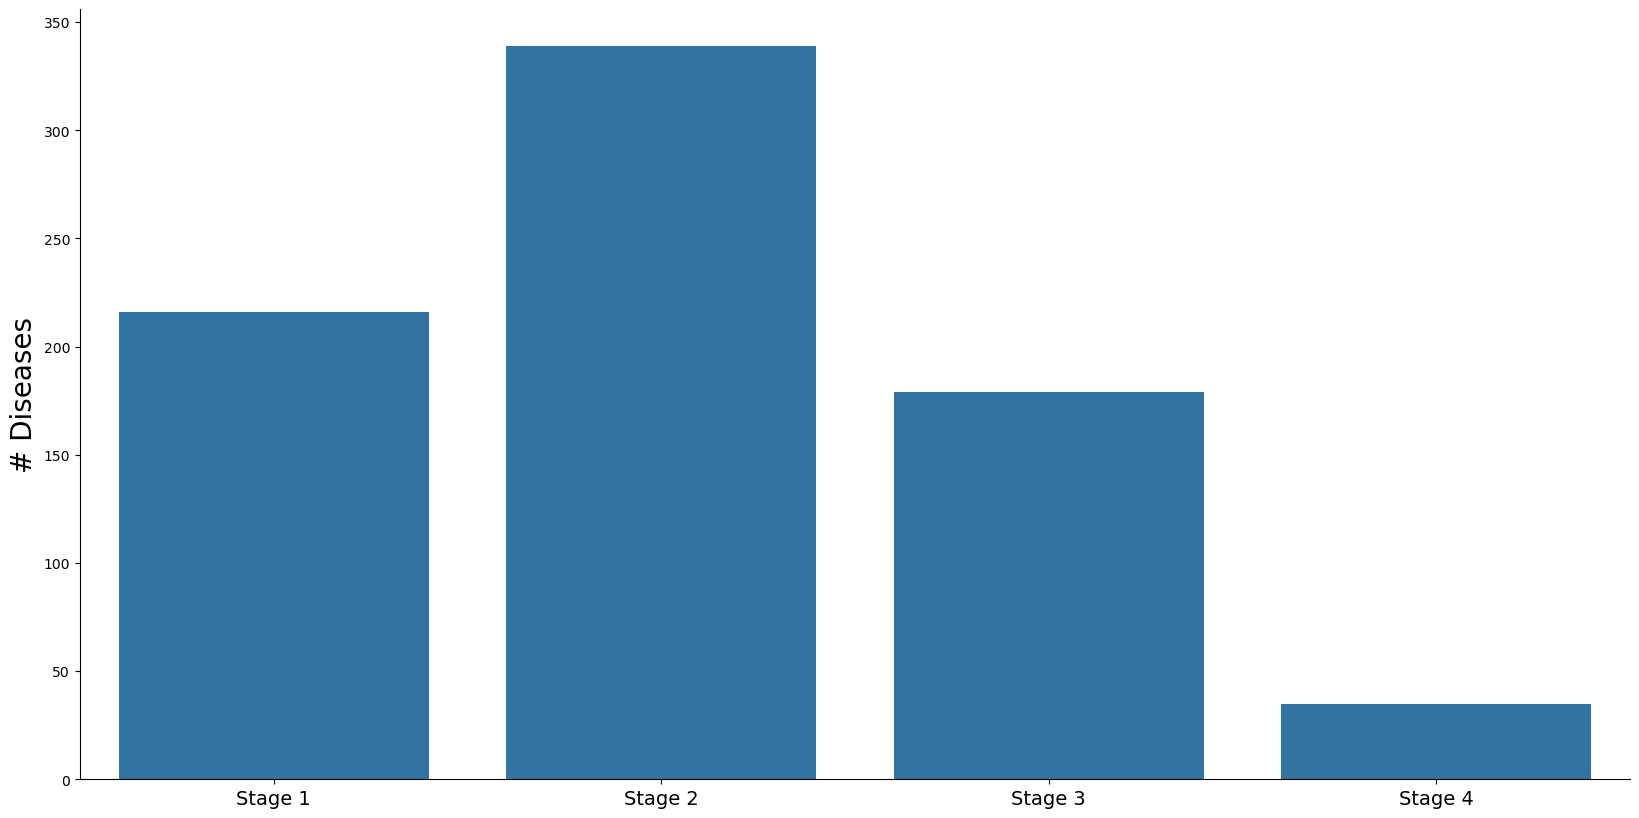

In [33]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(set(tot_s1_dis_list)),len(set(tot_s2_dis_list)),len(set(tot_s3_dis_list)),len(set(tot_s4_dis_list))]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/NumberDiseasesperStage_Male_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show

In [55]:

stage_dict = {
    "Stage 1": sorted(set(tot_s1_dis_list)),
    "Stage 2": sorted(set(tot_s2_dis_list)),
    "Stage 3": sorted(set(tot_s3_dis_list)),
    "Stage 4": sorted(set(tot_s4_dis_list))
}

# -----------------------------
# 2. Build long-format dataframe
# -----------------------------
rows = []

for stage, diseases in stage_dict.items():
    for d in diseases:
        rows.append({
            "Stage": stage,
            "Disease_ID": d,
            "Unique_Disease_Count": len(diseases),
            "metadata": None
        })

df_stage = pd.DataFrame(rows)

# -----------------------------
# 3. Add metadata rows
# -----------------------------
metadata_entries = [
    "Unique_Disease_Count computed using len(set(stage_disease_list))",
    f"N_unique_Stage_1: {len(stage_dict['Stage 1'])}",
    f"N_unique_Stage_2: {len(stage_dict['Stage 2'])}",
    f"N_unique_Stage_3: {len(stage_dict['Stage 3'])}",
    f"N_unique_Stage_4: {len(stage_dict['Stage 4'])}"
]

metadata_df = pd.DataFrame({
    "Stage": [None]*len(metadata_entries),
    "Disease_ID": [None]*len(metadata_entries),
    "Unique_Disease_Count": [None]*len(metadata_entries),
    "metadata": metadata_entries
})

source_df = pd.concat([df_stage, metadata_df], ignore_index=True)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig4C", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/2333796608.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

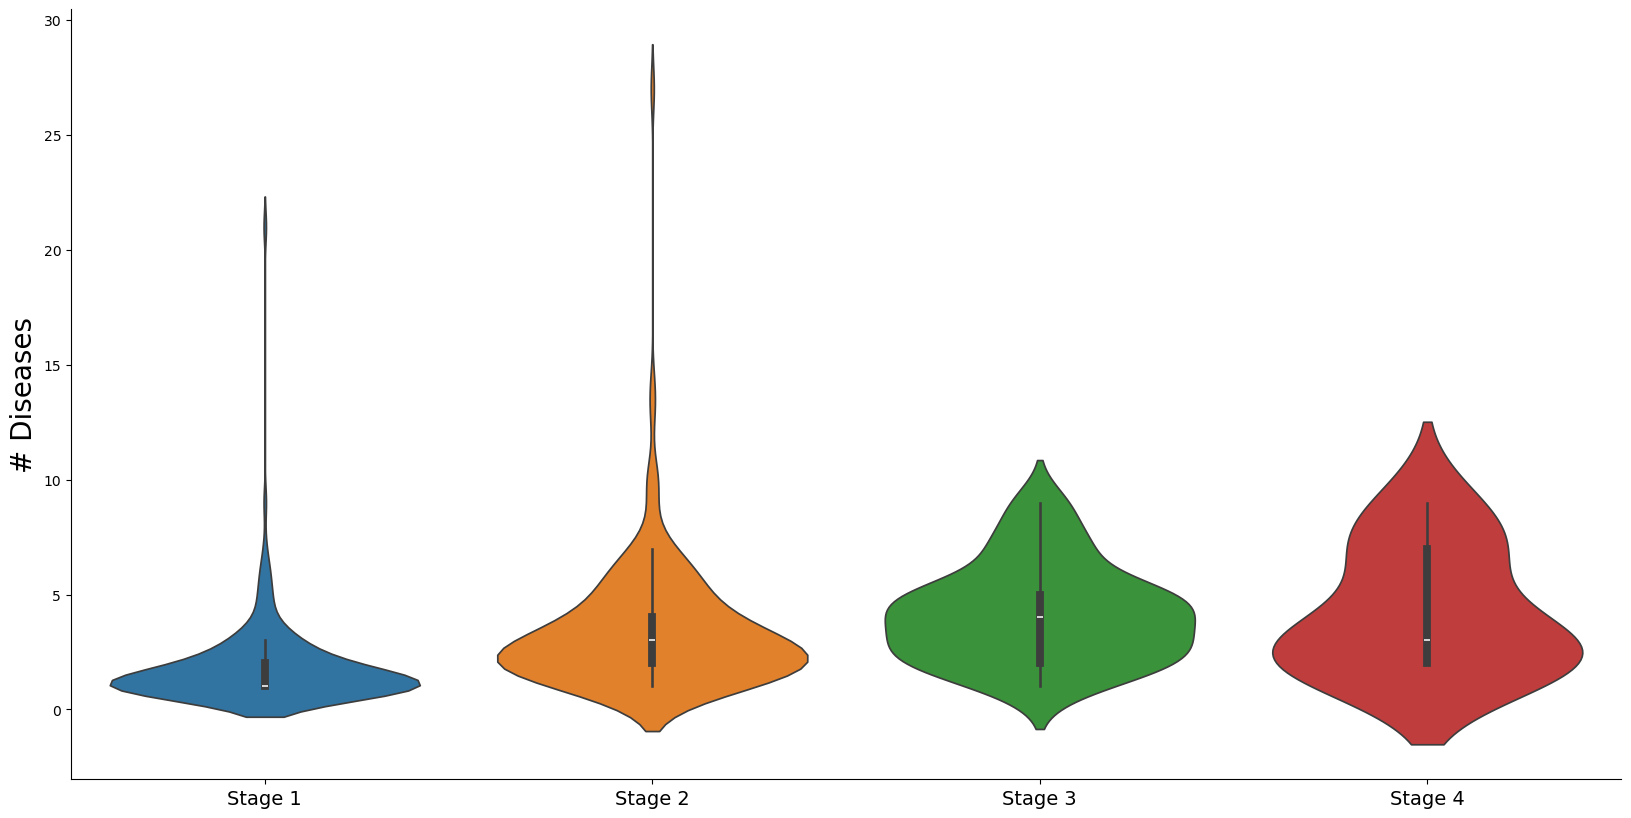

In [34]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_dis_list,trj_s2_dis_list,trj_s3_dis_list,trj_s4_dis_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeDiseaseTrajperStage_Male_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show


In [59]:

stage_data = {
    "Stage 1": [v for v in trj_s1_dis_list if pd.notna(v)],
    "Stage 2": [v for v in trj_s2_dis_list if pd.notna(v)],
    "Stage 3": [v for v in trj_s3_dis_list if pd.notna(v)],
    "Stage 4": [v for v in trj_s4_dis_list if pd.notna(v)]
}

# -----------------------------
# 2. Build long-format dataframe
# -----------------------------
rows = []

for stage, values in stage_data.items():
    for val in values:
        rows.append({
            "Stage": stage,
            "Trajectory_Size": val,
            "metadata": None
        })

df_stage_traj = pd.DataFrame(rows)

# Deterministic sorting
df_stage_traj = df_stage_traj.sort_values(["Stage", "Trajectory_Size"]).reset_index(drop=True)

# -----------------------------
# 3. Add metadata rows
# -----------------------------
metadata_entries = [
    "Violin plot shows full distribution of trajectory sizes per stage",
    f"N_Stage_1: {len(stage_data['Stage 1'])}",
    f"N_Stage_2: {len(stage_data['Stage 2'])}",
    f"N_Stage_3: {len(stage_data['Stage 3'])}",
    f"N_Stage_4: {len(stage_data['Stage 4'])}"
]

metadata_df = pd.DataFrame({
    "Stage": [None]*len(metadata_entries),
    "Trajectory_Size": [None]*len(metadata_entries),
    "metadata": metadata_entries
})

source_df = pd.concat([df_stage_traj, metadata_df], ignore_index=True)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig4D", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [35]:

print("The number of disease trajectory in Stage 1 is %s and their average size is %s"%(len(trj_s1_dis_list),np.median(trj_s1_dis_list)))
print("The number of disease trajectory in Stage 2 is %s and their average size is %s"%(len(trj_s2_dis_list),np.median(trj_s2_dis_list)))
print("The number of disease trajectory in Stage 3 is %s and their average size is %s"%(len(trj_s3_dis_list),np.median(trj_s3_dis_list)))
print("The number of disease trajectory in Stage 4 is %s and their average size is %s"%(len(trj_s4_dis_list),np.median(trj_s4_dis_list)))


The number of disease trajectory in Stage 1 is 190 and their average size is 1.0
The number of disease trajectory in Stage 2 is 190 and their average size is 3.0
The number of disease trajectory in Stage 3 is 61 and their average size is 4.0
The number of disease trajectory in Stage 4 is 9 and their average size is 3.0


In [36]:
from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(trj_s1_dis_list,trj_s2_dis_list)
print("T-test Stage 1 vs Stage 2, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s1_dis_list,trj_s3_dis_list)
print("T-test Stage 1 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s1_dis_list,trj_s4_dis_list)
print("T-test Stage 1 vs Stage 4, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s2_dis_list,trj_s3_dis_list)
print("T-test Stage 2 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s2_dis_list,trj_s4_dis_list)
print("T-test Stage 2 vs Stage 4, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s3_dis_list,trj_s4_dis_list)
print("T-test Stage 3 vs Stage 4, p-value is %s"%p_value)

T-test Stage 1 vs Stage 2, p-value is 2.5905699153405196e-10
T-test Stage 1 vs Stage 3, p-value is 1.8974181822535056e-14
T-test Stage 1 vs Stage 4, p-value is 0.000334138155008628
T-test Stage 2 vs Stage 3, p-value is 0.055929888539643646
T-test Stage 2 vs Stage 4, p-value is 0.38830216273079166
T-test Stage 3 vs Stage 4, p-value is 0.9240930518787389


In [37]:
#Let's make a dictionary that takes all the diseases at each stage and their frequency

tot_gen_dis_dict={}
for i in range(1,5):
    tot_dislist = []
    for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        try:
            tot_dislist.extend(list(stage_dict[i]))
        except:
            pass
    tot_gen_dis_dict[i] = tot_dislist


tot_gen_dis_counter_dict={}
for gen,dislist in tot_gen_dis_dict.items():
    dislist_count=Counter(dislist).most_common()
    tot_gen_dis_counter_dict[gen]=dislist_count

In [38]:
for gen,dislist in tot_gen_dis_counter_dict.items():
    print(gen)
    print(dislist[:10])

1
[('M43', 5), ('F20', 4), ('K73', 4), ('M42', 4), ('H93', 4), ('K83', 4), ('J30', 3), ('H02', 3), ('K76', 3), ('E88', 3)]
2
[('B18', 8), ('M54', 6), ('K86', 5), ('C22', 5), ('M42', 5), ('I99', 5), ('G83', 5), ('C24', 5), ('E78', 4), ('I10', 4)]
3
[('H10', 5), ('D52', 4), ('G54', 4), ('N05', 4), ('C22', 3), ('F05', 3), ('G31', 3), ('H61', 3), ('I77', 3), ('J39', 3)]
4
[('N62', 2), ('D21', 2), ('L08', 2), ('C10', 1), ('C13', 1), ('E53', 1), ('F22', 1), ('H10', 1), ('I86', 1), ('K64', 1)]


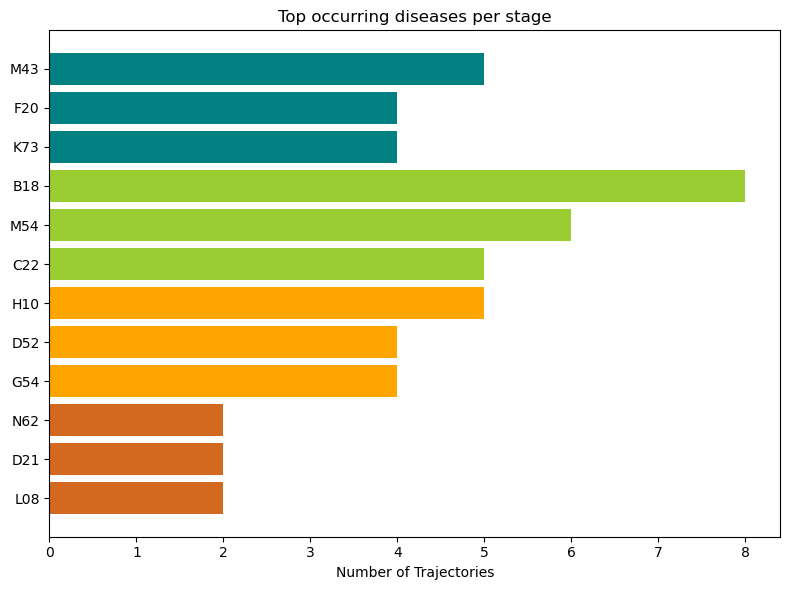

In [65]:
#Let's make it as a barplot
dis_list = ['M43','F20','K73','B18','M54','C22','H10','D52','G54','N62','D21','L08']
frequency_list = [5,4,4,8,6,5,5,4,4,2,2,2]
color_list = ['teal', 'yellowgreen','orange','chocolate']
# Assign colors cycling every three bars
bar_colors = [color_list[(i // 3) % len(color_list)] for i in range(len(dis_list))]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(dis_list))

ax.barh(y_pos, frequency_list, color=bar_colors, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dis_list)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top occurring diseases per stage')

plt.tight_layout()
plt.savefig('Figures/MaleDisFrequencyBarplot_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [67]:

stage_index = [(i // 3) + 1 for i in range(len(dis_list))]

df_freq = pd.DataFrame({
    "Disease_Code": dis_list,
    "Number_of_Trajectories": frequency_list,
    "Stage_Index_from_ColorCycle": stage_index,
    "Bar_Color": bar_colors,
    "metadata": None
})

# Deterministic ordering (same as plotted order)
df_freq = df_freq.reset_index(drop=True)

# -----------------------------
# Add metadata rows
# -----------------------------
metadata_entries = [
    "Barplot type: horizontal (ax.barh)",
    "Bars grouped in blocks of 3 diseases per stage",
    "Colors assigned via (i // 3) % len(color_list)",
    f"Total_diseases_plotted: {len(dis_list)}"
]

metadata_df = pd.DataFrame({
    "Disease_Code": [None]*len(metadata_entries),
    "Number_of_Trajectories": [None]*len(metadata_entries),
    "Stage_Index_from_ColorCycle": [None]*len(metadata_entries),
    "Bar_Color": [None]*len(metadata_entries),
    "metadata": metadata_entries
})

source_df = pd.concat([df_freq, metadata_df], ignore_index=True)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig4E", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [ ]:
# M43 = Other deforming dorsopathies
# K73 = Chronic hepatitis, not elsewhere classified
# M42 = Spinal osteochondrosis

# B18 = Chronic viral hepatitis
# M54 = Dorsalgia
# K86 = Other diseases of pancreas

# H10 = Conjunctivitis
# C22 = Malignant neoplasm of liver and intrahepatic bile ducts
# D52 = Folate deficiency anemia

# N62 = Hypertrophy of breast 
# D21 = Other benign neoplasms of connective and other soft tissue
# L08 = Other local infections of skin and subcutaneous tissue

In [39]:
#Now, let's select the total number of genes associated with each stage

tot_s1_gene_list=[]
tot_s2_gene_list=[]
tot_s3_gene_list=[]
tot_s4_gene_list=[]

for dis in tot_s1_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s1_gene_list:
                tot_s1_gene_list.append(gene)
    except:
        pass

for dis in tot_s2_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s2_gene_list:
                tot_s2_gene_list.append(gene)
    except:
        pass

for dis in tot_s3_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s3_gene_list:
                tot_s3_gene_list.append(gene)
    except:
        pass
        
for dis in tot_s4_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s4_gene_list:
                tot_s4_gene_list.append(gene)
    except:
        pass



/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/636071272.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

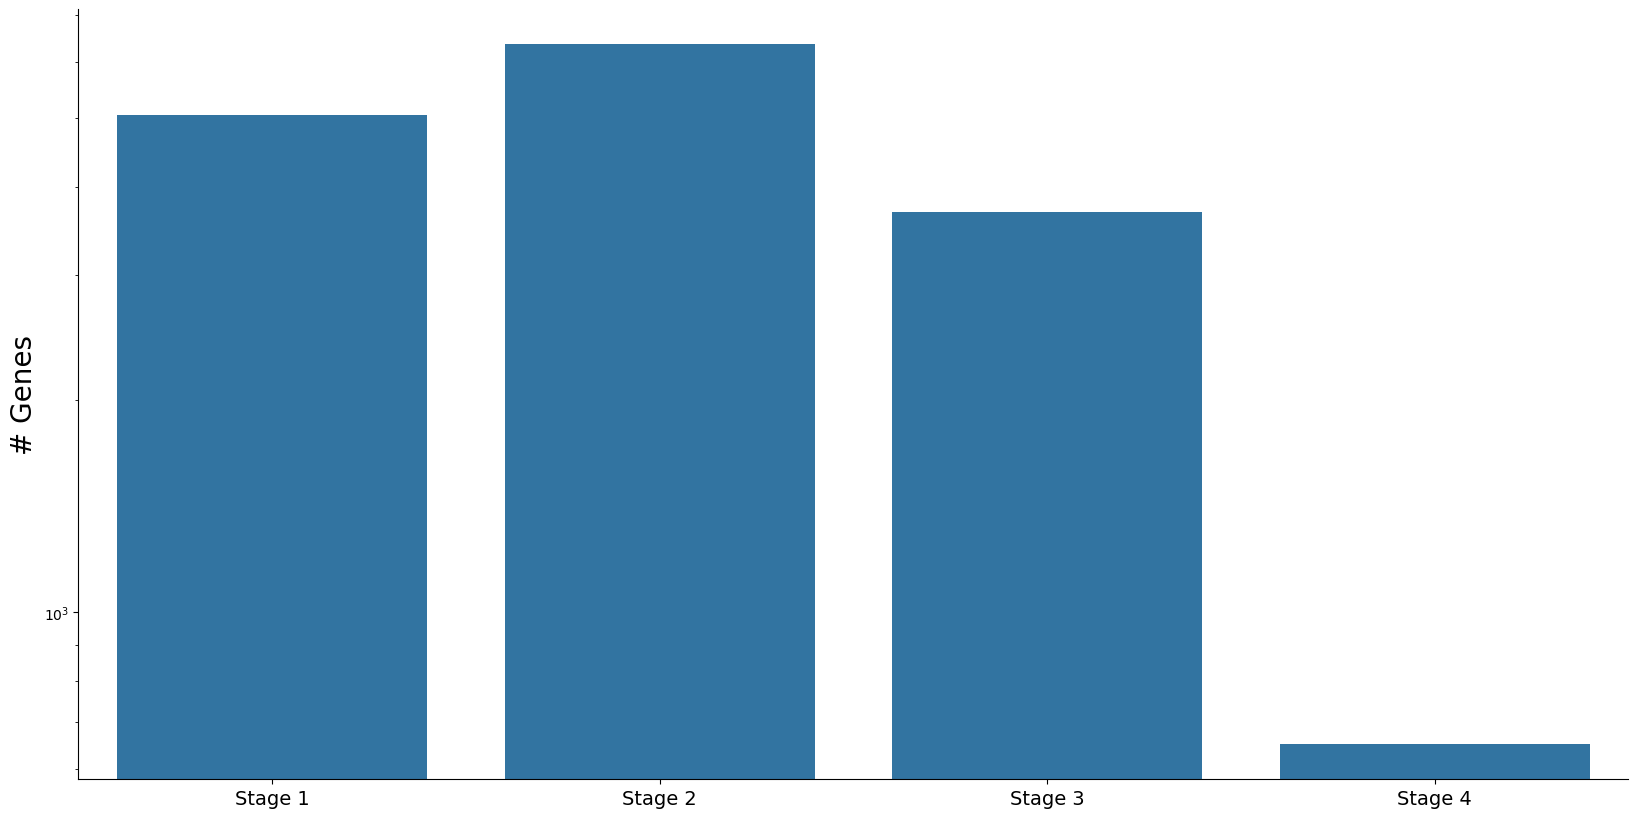

In [40]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(tot_s1_gene_list),len(tot_s2_gene_list),len(tot_s3_gene_list),len(tot_s4_gene_list)]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/NumberGenesperStage_Male_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show

In [70]:

stage_dict = {
    "Stage 1": sorted(set(tot_s1_gene_list)),
    "Stage 2": sorted(set(tot_s2_gene_list)),
    "Stage 3": sorted(set(tot_s3_gene_list)),
    "Stage 4": sorted(set(tot_s4_gene_list))
}

rows = []

for stage, diseases in stage_dict.items():
    for d in diseases:
        rows.append({
            "Stage": stage,
            "Gene_ID": d,
            "Unique_Gene_Count": len(diseases),
            "metadata": None
        })

df_stage = pd.DataFrame(rows)

# -----------------------------
# 3. Add metadata rows
# -----------------------------
metadata_entries = [
    "Unique_Gene_Count computed using len(set(stage_gene_list))",
    f"N_unique_Stage_1: {len(stage_dict['Stage 1'])}",
    f"N_unique_Stage_2: {len(stage_dict['Stage 2'])}",
    f"N_unique_Stage_3: {len(stage_dict['Stage 3'])}",
    f"N_unique_Stage_4: {len(stage_dict['Stage 4'])}"
]

metadata_df = pd.DataFrame({
    "Stage": [None]*len(metadata_entries),
    "Gene_ID": [None]*len(metadata_entries),
    "Unique_Gene_Count": [None]*len(metadata_entries),
    "metadata": metadata_entries
})

source_df = pd.concat([df_stage, metadata_df], ignore_index=True)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig4F", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [41]:

trj_s1_gene_list=[]
trj_s2_gene_list=[]
trj_s3_gene_list=[]
trj_s4_gene_list=[]


for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    genelist_s4 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    trj_s1_gene_list.append(len(genelist_s1))
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s2:
                        genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    trj_s2_gene_list.append(len(genelist_s2))
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s3:
                        genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    trj_s3_gene_list.append(len(genelist_s3))
    try:
        for dis in stage_dict[4]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s4:
                        genelist_s4.append(gene)
            except:
                pass
    except:
        pass
    trj_s4_gene_list.append(len(genelist_s4))


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/3563405933.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

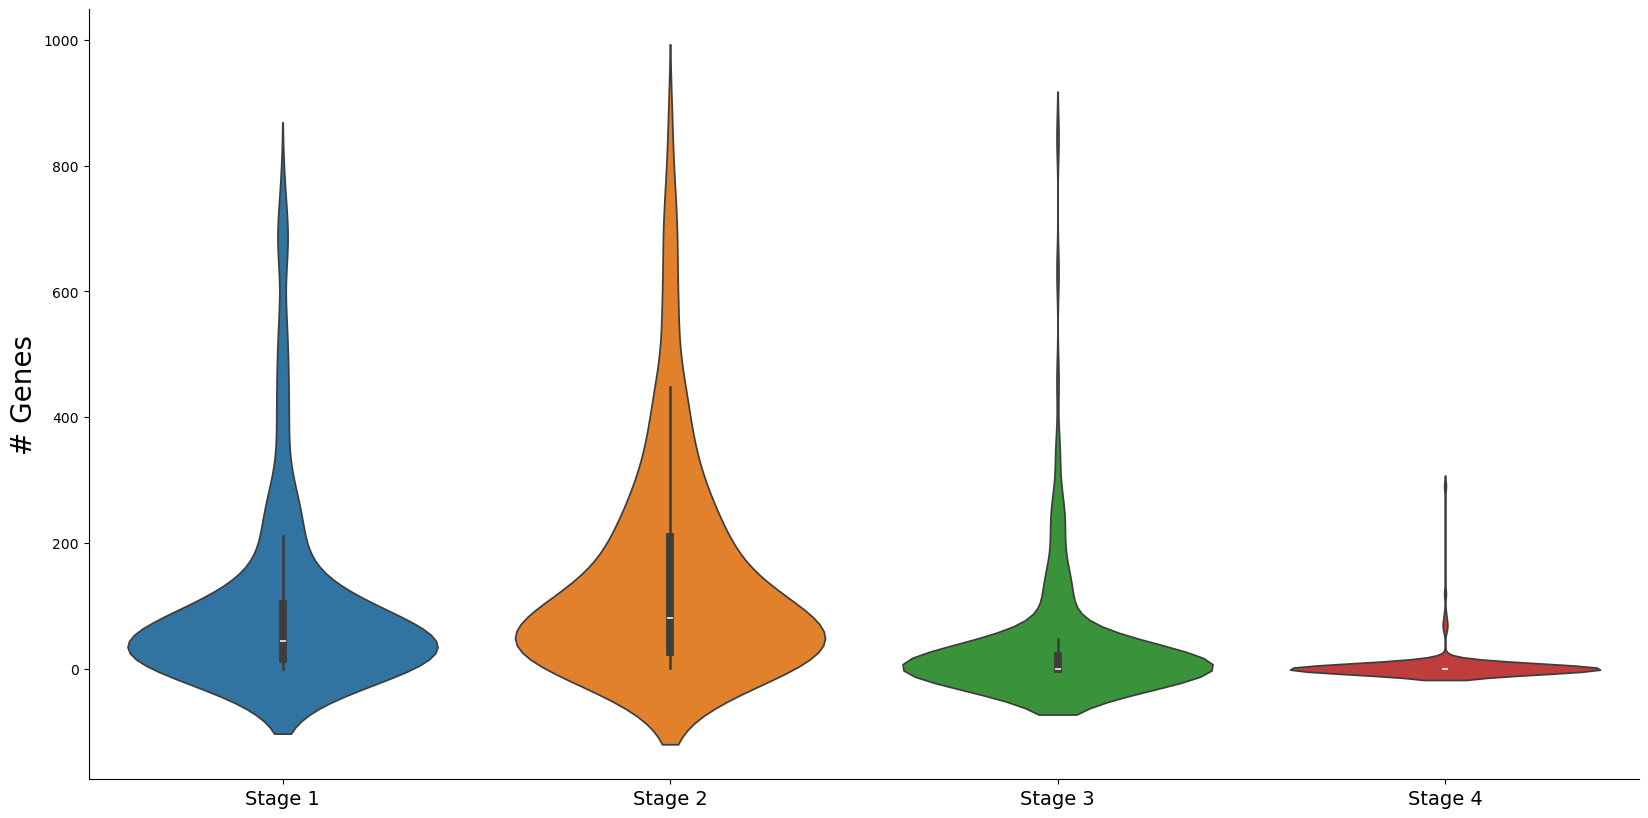

In [42]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_gene_list,trj_s2_gene_list,trj_s3_gene_list,trj_s4_gene_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeGenesTrajperStage_Male_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/2536753365.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


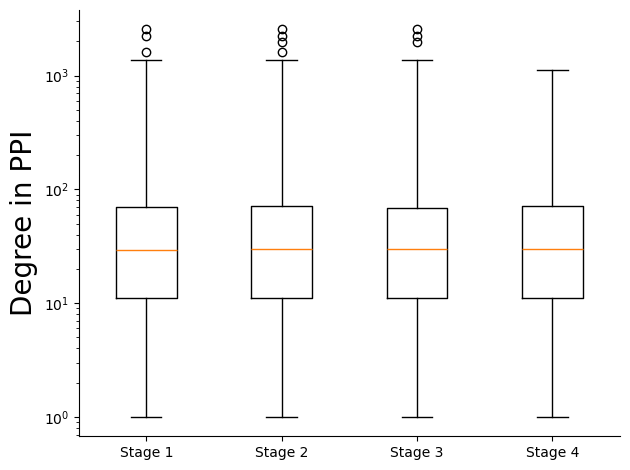

In [43]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

plt.ylabel('Degree in PPI',fontsize=20)
comparing_group_list= [
            [G_ppi.degree(gene) for gene in tot_s1_gene_list],
            [G_ppi.degree(gene) for gene in tot_s2_gene_list],
            [G_ppi.degree(gene) for gene in tot_s3_gene_list],
            [G_ppi.degree(gene) for gene in tot_s4_gene_list]
]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.yscale("log")
plt.tight_layout()

plt.savefig('Figures/DegreeInteractomeTrajperStage_Male_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()




In [44]:
print(np.median([G_ppi.degree(gene) for gene in tot_s1_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s2_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s3_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s4_gene_list]))


29.5
30.0
30.0
30.0


In [45]:


#Let's make a dictionary that takes all the genes associated with the trajectories at each stage
#Here, we will count the number of trajectories each gene appear for each stage
#This is different than counting the number of diseases, because we are treating the trajectories as meta-diseases
#which means that if we have a trajectory with 5 diseases targeting the same gene, that gene will be counted just one

tot_gen_gene_dict={}
for i in range(1,5):
    tot_genelist = []
    for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        genelist = []
        try:
            for dis in stage_dict[i]:
                for gene in list(icd_genes_ppi_dict[dis]):
                    if gene not in genelist:
                        genelist.append(gene)
        except:
            pass
        tot_genelist.extend(genelist)
    tot_gen_gene_dict[i] = tot_genelist


tot_gen_gene_counter_dict={}
for gen,genelist in tot_gen_gene_dict.items():
    genelist_count=Counter(genelist).most_common()
    tot_gen_gene_counter_dict[gen]=genelist_count

In [46]:
tot_gen_gene_counter_dict[1][:10]


[('TNF', 70),
 ('APOE', 44),
 ('HLA-DQB1', 42),
 ('IL6', 42),
 ('PTGS2', 38),
 ('IL1B', 36),
 ('MTHFR', 36),
 ('FTO', 36),
 ('TGFB1', 34),
 ('NR3C1', 33)]

In [47]:
tot_gen_gene_counter_dict[2][:10]


[('TNF', 82),
 ('APOE', 66),
 ('NR3C1', 57),
 ('PTGS2', 56),
 ('IL6', 55),
 ('HLA-DQB1', 55),
 ('IL1B', 53),
 ('MTHFR', 50),
 ('ABO', 48),
 ('FTO', 48)]

In [48]:
tot_gen_gene_counter_dict[3][:10]


[('TNF', 23),
 ('IL6', 22),
 ('NR3C1', 21),
 ('VEGFA', 18),
 ('APOE', 17),
 ('PTGS2', 17),
 ('HLA-DQB1', 17),
 ('TCF7L2', 16),
 ('HLA-DQA1', 16),
 ('CDKN2B-AS1', 15)]

In [49]:
tot_gen_gene_counter_dict[4][:10]


[('NR3C1', 5),
 ('GC', 3),
 ('FTO', 3),
 ('ABO', 3),
 ('TNF', 3),
 ('TNXB', 3),
 ('IL10', 3),
 ('HLA-DQB1', 2),
 ('APOE', 2),
 ('IL2', 2)]

In [50]:
for gen,genelist in tot_gen_gene_dict.items():
    print(gen,len(set(genelist)))

1 5062
2 6341
3 3679
4 651


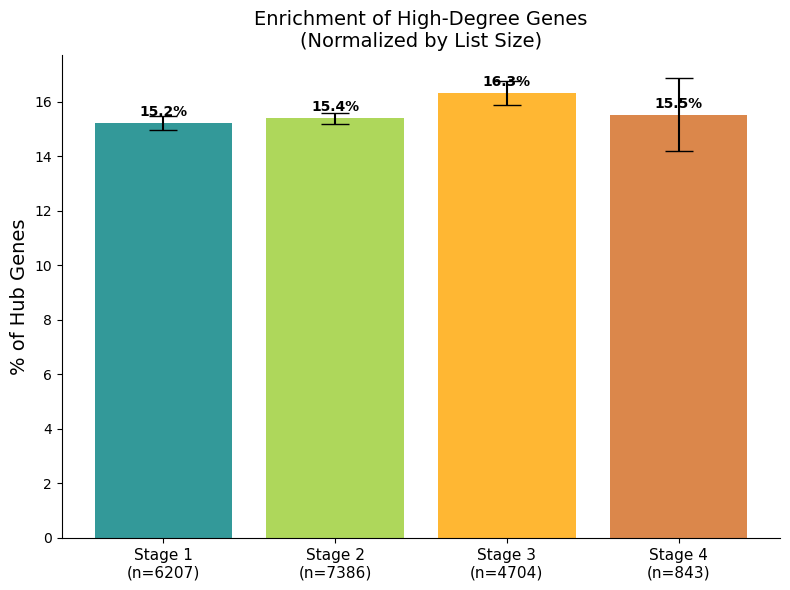

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

# 1. Gather your data
data_lists = [
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict[1]], # Stage 1
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict[2]], # Stage 2
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict[3]], # Stage 3
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict[4]]  # Stage 4
]
labels = ['Stage 1\n(n=6207)', 'Stage 2\n(n=7386)', 'Stage 3\n(n=4704)', 'Stage 4\n(n=843)']

# 2. Define "High Degree" (The Tail)
# In scale-free networks, the median is always low. The difference is in the top 10%.
# Let's define "Hubs" as the top 10% of the combined data, or a fixed number (e.g., > 20 connections)
all_degrees = np.concatenate(data_lists)
hub_threshold = np.percentile(list(dict(nx.degree(G_ppi)).values()), 90) # Top 10% cutoff
# Alternatively, set a hard threshold: hub_threshold = 50

proportions = []
errors = []

for data in data_lists:
    n = len(data)
    # Count how many genes are "Hubs"
    hub_count = sum(1 for x in data if x >= hub_threshold)
    
    # Calculate Proportion
    p = hub_count / n
    proportions.append(p * 100) # Convert to %
    
    # Calculate Standard Error for Proportion: sqrt( p*(1-p) / n )
    # This specifically accounts for the small N of Stage 4!
    sem = sqrt((p * (1 - p)) / n)
    errors.append(sem * 100) # Convert to %

# 3. Plot
fig, ax = plt.subplots(figsize=(8, 6))

x_pos = np.arange(len(labels))
bars = ax.bar(x_pos, proportions, yerr=errors, align='center', 
              alpha=0.8, ecolor='black', capsize=10, 
              color=['teal', 'yellowgreen','orange','chocolate'])

ax.set_ylabel(f'% of Hub Genes', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11)
ax.set_title(f'Enrichment of High-Degree Genes\n(Normalized by List Size)', fontsize=14)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig('Figures/Hub_Percentage_Male_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [135]:
import pandas as pd
import numpy as np
import networkx as nx
from math import sqrt

# -----------------------------
# 1. Compute hub threshold
# -----------------------------
all_network_degrees = list(dict(nx.degree(G_ppi)).values())
hub_threshold = np.percentile(all_network_degrees, 90)

# -----------------------------
# 2. Collect per-gene data
# -----------------------------
rows = []
summary_rows = []

for stage in [1, 2, 3, 4]:
    
    gene_list = tot_gen_gene_dict[stage]
    degrees = [G_ppi.degree(g) for g in gene_list]
    
    n = len(degrees)
    hub_count = sum(1 for x in degrees if x >= hub_threshold)
    p = hub_count / n
    sem = sqrt((p * (1 - p)) / n)
    
    # Save per-gene data
    for gene, deg in zip(gene_list, degrees):
        rows.append({
            "Stage": f"Stage {stage}",
            "Gene_ID": gene,
            "PPI_Degree": deg,
            "Is_Hub": deg >= hub_threshold,
            "Hub_Threshold": hub_threshold,
            "metadata": None
        })
    
    # Save stage summary
    summary_rows.append({
        "Stage": f"Stage {stage}",
        "Gene_ID": None,
        "PPI_Degree": None,
        "Is_Hub": None,
        "Hub_Threshold": hub_threshold,
        "metadata": f"Summary_Stage_{stage}: N={n}, Hub_Count={hub_count}, Hub_%={p*100:.4f}, SEM_%={sem*100:.6f}"
    })

df_genes = pd.DataFrame(rows)
df_summary = pd.DataFrame(summary_rows)

# -----------------------------
# 3. Global metadata
# -----------------------------
metadata_entries = [
    f"Hub definition: PPI degree >= {hub_threshold} (90th percentile of full PPI network)",
    "Proportion calculated as hub_count / N",
    "Standard error = sqrt(p*(1-p)/N)",
    "Bars represent percentage of hub genes per stage"
]

metadata_df = pd.DataFrame({
    "Stage": [None]*len(metadata_entries),
    "Gene_ID": [None]*len(metadata_entries),
    "PPI_Degree": [None]*len(metadata_entries),
    "Is_Hub": [None]*len(metadata_entries),
    "Hub_Threshold": [hub_threshold]*len(metadata_entries),
    "metadata": metadata_entries
})

# Combine all
source_df = pd.concat([df_genes, df_summary, metadata_df], ignore_index=True)

# Deterministic sorting
source_df = source_df.sort_values(["Stage", "PPI_Degree"], na_position='last')

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig4H", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [52]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

# 1. Setup Data (Recalculating the counts from your lists)
# ---------------------------------------------------------
data_lists = [
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict[1]], # Stage 1
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict[2]], # Stage 2
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict[3]], # Stage 3
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict[4]]  # Stage 4
]
stage_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
hub_threshold = np.percentile(list(dict(nx.degree(G_ppi)).values()), 90)

# Create a summary table: [Successes (Hubs), Total N]
successes = []
nobs = [] # Number of observations

for data in data_lists:
    n = len(data)
    count_hubs = sum(1 for x in data if x >= hub_threshold)
    successes.append(count_hubs)
    nobs.append(n)

print(f"Threshold for 'High Degree': >= {hub_threshold}")
print(f"Counts of Hubs: {successes}")
print(f"Total Genes (N): {nobs}")
print("-" * 30)

# 2. Global Test: Chi-Squared
# ---------------------------------------------------------
# We construct a contingency table:
# [[Non-Hubs_S1, Hubs_S1],
#  [Non-Hubs_S2, Hubs_S2], ...]
contingency_table = []
for i in range(4):
    contingency_table.append([nobs[i] - successes[i], successes[i]])

chi2, p_global, dof, expected = chi2_contingency(contingency_table)

print(f"Global Chi-Squared Test P-value: {p_global:.2e}")
if p_global < 0.05:
    print(">> Result: Significant difference found among stages.")
else:
    print(">> Result: No significant difference found.")

print("-" * 30)

# 3. Post-Hoc Test: Pairwise Z-Test (Stage X vs Stage Y)
# ---------------------------------------------------------
# Only meaningful if Global P < 0.05
if p_global < 0.05:
    print("Pairwise Comparisons (Stage vs Stage):")
    
    # Compare Stage 1 vs Stage 4 (or any other pair)
    # You can loop through all combinations if needed
    pairs_to_test = [(0, 1), (0, 2), (0, 3), (2, 3)] # Indices of stages to compare
    
    for i, j in pairs_to_test:
        count = np.array([successes[i], successes[j]])
        nobs_pair = np.array([nobs[i], nobs[j]])
        
        stat, p_val = proportions_ztest(count, nobs_pair)
        
        # Bonferroni correction: Multiply p-value by number of tests done? 
        # Or just keep it raw for now. Usually, p < 0.05/Number_of_tests is safe.
        
        sig = "*" if p_val < 0.05 else "ns"
        print(f"{stage_names[i]} vs {stage_names[j]}: p={p_val:.2e} ({sig})")

Threshold for 'High Degree': >= 118.5
Counts of Hubs: [2857, 4314, 1188, 114]
Total Genes (N): [18754, 28019, 7272, 734]
------------------------------
Global Chi-Squared Test P-value: 1.65e-01
>> Result: No significant difference found.
------------------------------


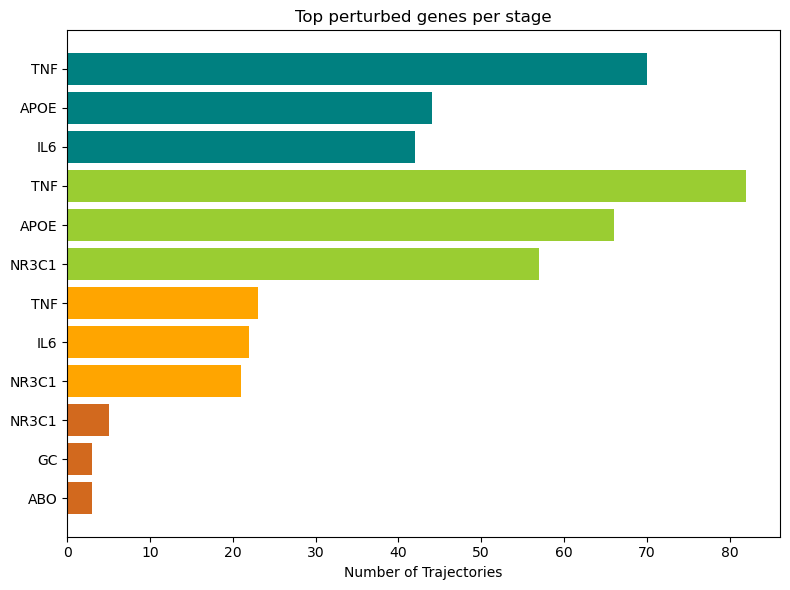

In [53]:
#Let's make it as a barplot
dis_list = ['TNF','APOE','IL6','TNF','APOE','NR3C1','TNF','IL6','NR3C1','NR3C1','GC','ABO']
frequency_list = [70,44,42,82,66,57,23,22,21,5,3,3]
color_list = ['teal', 'yellowgreen','orange','chocolate']
# Assign colors cycling every three bars
bar_colors = [color_list[(i // 3) % len(color_list)] for i in range(len(dis_list))]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(dis_list))

ax.barh(y_pos, frequency_list, color=bar_colors, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dis_list)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top perturbed genes per stage')

plt.tight_layout()
plt.savefig('Figures/MaleGeneFrequencyBarplot_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()



In [130]:
#ENRICH

In [54]:

tot_gen_genes_counter_dict_df={}

for gen,genecount in tot_gen_gene_counter_dict.items():
    rank_df=pd.DataFrame(columns=('gene', 'rank'))
    gene_list=[]
    rank_genelist=[]
    for el in genecount:
        gene_list.append(el[0])
        rank_genelist.append(el[1])
    rank_df['gene']=gene_list
    rank_df['rank']=rank_genelist
    rank_df=rank_df.sort_values(by=['rank'],ascending=False)
    tot_gen_genes_counter_dict_df[gen]=rank_df

In [55]:


for gen,rank_df in tot_gen_genes_counter_dict_df.items():
        
    lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
                     processes=4,min_size=3,max_size=5000,outdir=None,   #we impose at least 5 enriched common genes
                     permutation_num=500) # reduce number to speed up testing
    # to save your figure, make sure that ``ofname`` is not None
    ax = dotplot(lib_pre_res.res2d,
                 column="FDR q-val",
                 title='Male KEGG at stage %s'%gen,
                 cmap=plt.cm.viridis,
                 size=6, # adjust dot size
                 figsize=(4,5), cutoff=0.25, ofname='Figures/Male KEGG at stage %s_v2026_official.pdf'%gen, show_ring=False)

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/1444568668.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2026-03-09 17:01:10,093 [WARNING] Duplicated values found in preranked stats: 99.25% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/1444568668.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2026-03-09 17:01:11,070 [WARNING] Duplicated values found in preranked stats: 99.18% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/1444568668.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2026-03-09 17:01:12,424 

In [56]:
#Let's calculate the z-score connectivity for the genes associated at each stage in each trajectory

tot_gen_connectivity_zscore_dict={}
for i in range(1,5):
    tot_zscore_list = []
    for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        genelist_s_i = []
        try:
            for dis in stage_dict[i]:
                genelist_s_i.extend(list(icd_genes_ppi_dict[dis]))
        except:
            pass
        geneset_s_i = set(genelist_s_i)
        geneset_s_i_cl = [i for i in geneset_s_i if str(i)!='nan']
        z_score_s_i = net_modularity(geneset_s_i_cl,G_ppi)
        if str(z_score_s_i)!='nan':
            tot_zscore_list.append(z_score_s_i)
        
    tot_gen_connectivity_zscore_dict[i] = tot_zscore_list

In [57]:

with open('output/tot_gen_connectivity_zscore_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(tot_gen_connectivity_zscore_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [58]:
with open('output/tot_gen_connectivity_zscore_dict_v2026_official.pickle', 'rb') as handle:
    tot_gen_connectivity_zscore_dict = pk.load(handle)

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/4265049304.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


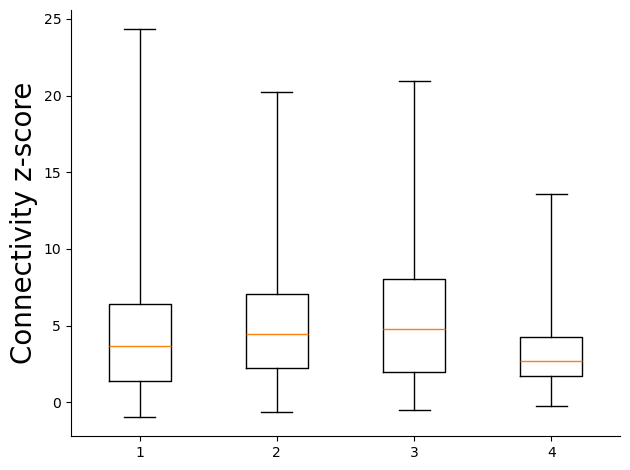

In [59]:


fig1, ax1 = plt.subplots()
labels=list([str(i) for i in tot_gen_connectivity_zscore_dict.keys()])
plt.ylabel('Connectivity z-score',fontsize=20)
comparing_group_list= list(tot_gen_connectivity_zscore_dict.values())
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

#plt.yscale("log")
plt.tight_layout()
plt.savefig('Figures/ConnectivityzscoreperStage_Male_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [60]:

# -----------------------------
# 2. Build long-format dataframe
# -----------------------------
rows = []

for stage, values in tot_gen_connectivity_zscore_dict.items():
    for val in values:
        rows.append({
            "Stage": stage,
            "Interactome_zscore": val,
            "metadata": None
        })

df_stage_traj = pd.DataFrame(rows)

# Deterministic sorting
df_stage_traj = df_stage_traj.sort_values(["Stage", "Interactome_zscore"]).reset_index(drop=True)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_stage_traj.to_excel(writer, sheet_name="Fig4G", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [61]:


t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[1],tot_gen_connectivity_zscore_dict[2])
print("T-test Stage 1 vs Stage 2, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[1],tot_gen_connectivity_zscore_dict[3])
print("T-test Stage 1 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[1],tot_gen_connectivity_zscore_dict[4])
print("T-test Stage 1 vs Stage 4, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[2],tot_gen_connectivity_zscore_dict[3])
print("T-test Stage 2 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[2],tot_gen_connectivity_zscore_dict[4])
print("T-test Stage 2 vs Stage 4, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[3],tot_gen_connectivity_zscore_dict[4])
print("T-test Stage 3 vs Stage 4, p-value is %s"%p_value)

T-test Stage 1 vs Stage 2, p-value is 0.501202663501821
T-test Stage 1 vs Stage 3, p-value is 0.3941668038912307
T-test Stage 1 vs Stage 4, p-value is 0.49944667932678255
T-test Stage 2 vs Stage 3, p-value is 0.6521460687849057
T-test Stage 2 vs Stage 4, p-value is 0.31655209764830616
T-test Stage 3 vs Stage 4, p-value is 0.27630245540997117


In [121]:
hub_threshold = np.percentile(list(dict(nx.degree(G_ppi)).values()), 90)

trj_hub_dict = {}
for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    stage_hub_dict = {}
    for stage, dislist in stage_dict.items():
        tot_genelist = []
        for dis in dislist:
            try:
                genelist = list(icd_genes_ppi_dict[dis])
                tot_genelist.extend(genelist)
            except:
                pass
        data = [G_ppi.degree(gene) for gene in tot_genelist]
        hub_count = sum(1 for x in data if x >= hub_threshold)
        # Calculate Proportion
        p = hub_count / len(data) if data else 0
        stage_hub_dict[stage] = p * 100
    trj_hub_dict[trj] = stage_hub_dict



In [ ]:
#Let's divide the trajectories in those which stage-specific genes degree tend to increase and those that decreases
#We will just compare the last and the first stage point

ascending_trj = []
descending_trj = []
for trj,hub in trj_hub_dict.items():
    gen_max_degree_idx = np.argmax(list(hub.values())) 
    if gen_max_degree_idx !=0:
        ascending_trj.append(trj)
    else:
        descending_trj.append(trj)

print(len(ascending_trj))
print(len(descending_trj))

98
92


In [ ]:

male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict

,trj,status,max_stage_idx,max_stage_val,disease_with_max_hub_percentage
0,10,Ascending,2,21.052632,D80
1,11,Ascending,2,27.777778,C79
2,13,Descending,1,15.277778,J01
3,18,Ascending,2,11.563169,I10
4,19,Descending,1,26.229508,E84


In [65]:
male_trj_evolving_status_df.to_csv("output/male_trj_evolving_status_df_official.csv",index=False)

In [189]:
for trj in descending_trj:
    if len(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])>3:
        print(trj,male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])

189 {1: ['M45'], 2: ['E13', 'M45'], 3: ['D35', 'I10', 'I12', 'I72', 'I77', 'K20', 'L98', 'M45', 'N05'], 4: ['I12', 'I13', 'M45', 'N05']}
281 {1: ['C67'], 2: ['C67', 'C68'], 3: ['C67', 'C68', 'N30'], 4: ['C65', 'C68']}
290 {1: ['K51'], 2: ['D73', 'J04', 'K51'], 3: ['K29', 'K51'], 4: ['A69', 'D16', 'D21', 'K51', 'L50', 'N10', 'N62']}
390 {1: ['G91', 'I60'], 2: ['D73', 'F52', 'G30', 'G91', 'I60', 'L28'], 3: ['E11', 'E55', 'F00', 'F05', 'G30', 'G91', 'H49'], 4: ['A48', 'C76', 'D34', 'G91', 'H60', 'L08', 'L28', 'M00', 'N04']}


In [190]:
for trj in ascending_trj:
    if len(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])>3:
        print(trj,male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])

119 {1: ['F70'], 2: ['D75', 'F70'], 3: ['D52', 'F10', 'F22', 'F70', 'G31', 'L21'], 4: ['C10', 'C13', 'E53', 'F22', 'H10', 'I86', 'N62']}
156 {1: ['K63'], 2: ['D12', 'I84', 'K62', 'K63'], 3: ['D12', 'I84', 'K62', 'K64'], 4: ['D21', 'K64']}
176 {1: ['K74'], 2: ['I85', 'K74'], 3: ['C22', 'I85', 'K31', 'K72', 'K74'], 4: ['B99', 'K72']}
197 {1: ['E88'], 2: ['E88', 'H47'], 3: ['E66', 'E88'], 4: ['E61', 'L08']}
198 {1: ['G47'], 2: ['G25', 'G47'], 3: ['E66', 'G25', 'G47'], 4: ['G25', 'H66', 'K46']}


In [192]:
male_trj_evolving_status_df[male_trj_evolving_status_df['trj']==390]

,trj,status,max_stage_idx,max_stage_val,disease_with_max_hub_percentage
151,390,Descending,1,21.212121,G91


In [125]:
#Let's import the trajectory dataset
male_trj_evolving_status_df = pd.read_csv("output/male_trj_evolving_status_df_official.csv")

In [126]:
#Let's collect the hub genes of the disease with the highest hub percentage for ascending and discending trajectories
hub_threshold = np.percentile(list(dict(nx.degree(G_ppi)).values()), 90)
ascending_max_hub_dis_list = list(male_trj_evolving_status_df[male_trj_evolving_status_df['status']=="Ascending"]["disease_with_max_hub_percentage"].unique())
descending_max_hub_dis_list = list(male_trj_evolving_status_df[male_trj_evolving_status_df['status']=="Descending"]["disease_with_max_hub_percentage"].unique())

ascending_max_hub_gene_list = []
descending_max_hub_gene_list = []

for dis in ascending_max_hub_dis_list:
    genelist = allsources_icd_gene_dict_unified[dis]
    for g in genelist:
          if G_ppi.degree(g)>hub_threshold:
                ascending_max_hub_gene_list.append(g)

for dis in descending_max_hub_dis_list:
    genelist = allsources_icd_gene_dict_unified[dis]
    for g in genelist:
          if G_ppi.degree(g)>hub_threshold:
                descending_max_hub_gene_list.append(g)

print(len(set(ascending_max_hub_gene_list)))
print(len(set(descending_max_hub_gene_list)))

398
448


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_88360/572653997.py:12: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if G_ppi.degree(g)>hub_threshold:
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_88360/572653997.py:18: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if G_ppi.degree(g)>hub_threshold:


In [14]:
#Let's import the housekeeping and the essential genes
#Housekeeping genes
housekeeping_gene_df=pd.read_csv("input/Housekeeping_GenesHuman.csv",sep=";")
housekeeping_gene_list = list(set(housekeeping_gene_df['Gene.name'].tolist()) & G_ppi.nodes())


#I will consider now a list of essential genes from https://github.com/macarthur-lab/gene_lists

Essential_genes=[]


file1 = open('input/culture_essential.txt', 'r')
Lines = file1.readlines()
count = 0
# Strips the newline character
for line in Lines:
    count += 1
    Essential_genes.append(line.strip())

file1 = open('input/CRISPR_essential.txt', 'r')
Lines = file1.readlines()
count = 0
# Strips the newline character
for line in Lines:
    count += 1
    Essential_genes.append(line.strip())    
    
file1 = open('input/mice_essential.txt', 'r')
Lines = file1.readlines()
count = 0
# Strips the newline character
for line in Lines:
    count += 1
    Essential_genes.append(line.strip())    
    
essential_genes_ppi=[]
for gene in Essential_genes:
    if gene in G_ppi.nodes():
        essential_genes_ppi.append(gene)
        
print("There are %s essential genes" %(len(set(essential_genes_ppi))))    

There are 3020 essential genes


In [19]:
print(overlap_genelists(set(essential_genes_ppi),set(ascending_max_hub_gene_list)))
print(overlap_genelists(set(essential_genes_ppi),set(descending_max_hub_gene_list)))
print(overlap_genelists(set(housekeeping_gene_list),set(ascending_max_hub_gene_list)))
print(overlap_genelists(set(housekeeping_gene_list),set(descending_max_hub_gene_list)))

1.5500097091517547e-80
8.216765746104365e-81
9.521770871357021e-28
4.0382530088584375e-21


In [25]:
def overlap_genelists_with_repetition(reference_set, gene_list_with_rep, background,
                                       n_perm=10000, alternative='greater', seed=0):
    """
    Enrichment test that accounts for repeated elements in gene_list_with_rep.

    reference_set      : set of genes to test enrichment against (e.g. essential_genes_ppi)
    gene_list_with_rep : list WITH repeats (e.g. ascending_max_hub_gene_list)
    background         : the universe of genes repeats 
    """
    rng = np.random.default_rng(seed)
    background_arr = np.array(list(background))
    in_ref = np.isin(background_arr, list(reference_set))  # boolean lookup over background

    n_draws = len(gene_list_with_rep)
    observed = sum(1 for g in gene_list_with_rep if g in reference_set)

    # vectorized permutations: draw n_perm random lists of length n_draws from background,
    # with replacement (matches the fact that your real list has repeats)
    idx = rng.integers(0, len(background_arr), size=(n_perm, n_draws))
    null_hits = in_ref[idx].sum(axis=1)

    if alternative == 'greater':
        p_value = (np.sum(null_hits >= observed) + 1) / (n_perm + 1)
    elif alternative == 'less':
        p_value = (np.sum(null_hits <= observed) + 1) / (n_perm + 1)
    else:
        p_value = (np.sum(np.abs(null_hits - null_hits.mean()) >= abs(observed - null_hits.mean())) + 1) / (n_perm + 1)

    return observed, p_value


# --- usage, mirroring your original print statements ---
comparisons = [
    ("essential_genes_ppi", essential_genes_ppi, "ascending", ascending_max_hub_gene_list),
    ("essential_genes_ppi", essential_genes_ppi, "descending", descending_max_hub_gene_list),
    ("housekeeping_gene_list", housekeeping_gene_list, "ascending", ascending_max_hub_gene_list),
    ("housekeeping_gene_list", housekeeping_gene_list, "descending", descending_max_hub_gene_list),
]

background_universe = G_ppi.nodes()

for ref_name, ref_genes, direction, hub_list in comparisons:
    obs, p = overlap_genelists_with_repetition(set(ref_genes), hub_list, background_universe, n_perm=10000)
    print(f"{ref_name} vs {direction}: observed hits = {obs}, p-value = {p:.4g}")

essential_genes_ppi vs ascending: observed hits = 393, p-value = 9.999e-05
essential_genes_ppi vs descending: observed hits = 448, p-value = 9.999e-05
housekeeping_gene_list vs ascending: observed hits = 180, p-value = 9.999e-05
housekeeping_gene_list vs descending: observed hits = 196, p-value = 9.999e-05


In [27]:
ascending_max_hub_gene_list_unique = set(ascending_max_hub_gene_list) - set(descending_max_hub_gene_list)
descending_max_hub_gene_list_unique = set(descending_max_hub_gene_list) - set(ascending_max_hub_gene_list)

print(len(ascending_max_hub_gene_list_unique))
print(len(descending_max_hub_gene_list_unique))

157
207


In [28]:
print(overlap_genelists(set(essential_genes_ppi),set(ascending_max_hub_gene_list_unique)))
print(overlap_genelists(set(essential_genes_ppi),set(descending_max_hub_gene_list_unique)))
print(overlap_genelists(set(housekeeping_gene_list),set(ascending_max_hub_gene_list_unique)))
print(overlap_genelists(set(housekeeping_gene_list),set(descending_max_hub_gene_list_unique)))

9.296698535508963e-30
1.8050882099895024e-30
5.687307763969525e-20
8.790410113081846e-12


In [122]:
#Let's collect the full trajectories
ascending_trj_list = [str(el) for el in list(male_trj_evolving_status_df[male_trj_evolving_status_df['status']=="Ascending"]["trj"].unique())]
descending_trj_list = [str(el) for el in list(male_trj_evolving_status_df[male_trj_evolving_status_df['status']=="Descending"]["trj"].unique())]


ascending_trj_genelist = []
descending_trj_genelist = []
for trj,genelist in male_trajectories_dict_filtered_unique_agglomerated_genes.items():
    if trj in ascending_trj_list:
        ascending_trj_genelist.extend(genelist)
    elif trj in descending_trj_list:
        descending_trj_genelist.extend(genelist)

ascending_trj_hub_genelist = []
for g in ascending_trj_genelist:
    if G_ppi.degree(g)>hub_threshold:
        ascending_trj_hub_genelist.append(g)
        
descending_trj_hub_genelist = []
for g in descending_trj_genelist:
    if G_ppi.degree(g)>hub_threshold:
        descending_trj_hub_genelist.append(g)

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_88360/60901045.py:16: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if G_ppi.degree(g)>hub_threshold:
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_88360/60901045.py:21: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if G_ppi.degree(g)>hub_threshold:


In [72]:
print(overlap_genelists(set(housekeeping_gene_list),set(ascending_trj_hub_genelist)))
print(overlap_genelists(set(housekeeping_gene_list),set(descending_trj_hub_genelist)))

1.5036776654138927e-48
1.068362008751934e-40


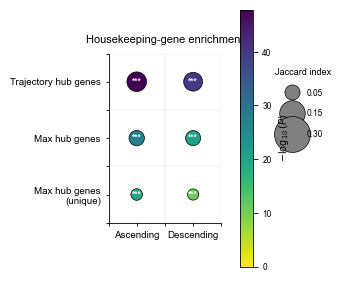

In [42]:
"""
Housekeeping-gene enrichment: ascending vs. descending hub-gene trajectories
============================================================================

Produces a Nature-style bubble/dot heatmap:
    - rows    = hub-gene list variant (trajectory hubs / max hubs / max hubs, unique)
    - columns = trajectory direction (ascending / descending)
    - dot size  -> Jaccard index of the overlap with housekeeping_gene_list
    - dot color -> enrichment significance (-log10 p-value, Fisher's exact test)

This is self-contained: it recomputes Jaccard index and Fisher's exact p-value
directly from a background gene universe, rather than relying on the internals
of `overlap_genelists`, so the two encodings (size, color) are guaranteed to be
consistent with each other.

Requires: ascending_trj_hub_genelist, descending_trj_hub_genelist,
          ascending_max_hub_gene_list, descending_max_hub_gene_list,
          ascending_max_hub_gene_list_unique, descending_max_hub_gene_list_unique,
          housekeeping_gene_list, and a `background_genes` universe
          (e.g. all genes in the PPI network) already defined in your session.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import fisher_exact

# ----------------------------------------------------------------------
# 0. Nature-style rcParams
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": 7,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "pdf.fonttype": 42,   # editable text in Illustrator
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


# ----------------------------------------------------------------------
# 1. Enrichment statistics (Jaccard index + Fisher's exact p-value)
# ----------------------------------------------------------------------
def enrichment_stats(set_a, set_b, background):
    """
    Jaccard index and one-sided (over-representation) Fisher's exact p-value
    for the overlap of set_a and set_b within a shared background universe.
    """
    background = set(background)
    a = set(set_a) & background
    b = set(set_b) & background

    intersection = a & b
    union = a | b
    jaccard = len(intersection) / len(union) if union else 0.0

    n_total = len(background)
    n_a_only = len(a - b)
    n_b_only = len(b - a)
    n_neither = n_total - len(a | b)

    table = [[len(intersection), n_b_only],
             [n_a_only, n_neither]]
    _, p_value = fisher_exact(table, alternative="greater")

    return jaccard, p_value


# ----------------------------------------------------------------------
# 2. Assemble the comparisons
# ----------------------------------------------------------------------
row_labels = [
    "Trajectory hub genes",
    "Max hub genes",
    "Max hub genes\n(unique)",
]

ascending_lists = [
    ascending_trj_hub_genelist,
    ascending_max_hub_gene_list,
    ascending_max_hub_gene_list_unique,
]

descending_lists = [
    descending_trj_hub_genelist,
    descending_max_hub_gene_list,
    descending_max_hub_gene_list_unique,
]

col_labels = ["Ascending", "Descending"]


background = set(G_ppi.nodes())

n_rows, n_cols = len(row_labels), len(col_labels)
jaccard_mat = np.zeros((n_rows, n_cols))
pval_mat = np.ones((n_rows, n_cols))

for i, (asc_list, desc_list) in enumerate(zip(ascending_lists, descending_lists)):
    for j, gene_list in enumerate([asc_list, desc_list]):
        jacc, p = enrichment_stats(housekeeping_gene_list, gene_list, background)
        jaccard_mat[i, j] = jacc
        pval_mat[i, j] = p

neglog10_p = -np.log10(np.clip(pval_mat, 1e-300, None))


# ----------------------------------------------------------------------
# 3. Plot: bubble / dot heatmap
# ----------------------------------------------------------------------
fig_width_in = 89 / 25.4    # single-column Nature width (89 mm)
fig_height_in = 1.55 * fig_width_in * (n_rows / 4)
fig, ax = plt.subplots(figsize=(fig_width_in, max(fig_height_in, 2.0)))

x_coords, y_coords = np.meshgrid(np.arange(n_cols), np.arange(n_rows))

# Scale Jaccard (0-1, typically small) to a legible marker-size range
size_scale = 2200
sizes = jaccard_mat.flatten() * size_scale + 8  # small floor so 0 is still visible as a dot

cmap = plt.cm.viridis_r
vmin, vmax = 0, max(neglog10_p.max(), 2)  # ensure colorbar is informative even for small effects

sc = ax.scatter(
    x_coords.flatten(), y_coords.flatten(),
    s=sizes, c=neglog10_p.flatten(),
    cmap=cmap, vmin=vmin, vmax=vmax,
    edgecolors="black", linewidths=0.5, zorder=3,
)

# Significance asterisks
sig_thresholds = [(0.001, "***"), (0.01, "**"), (0.05, "*")]
for i in range(n_rows):
    for j in range(n_cols):
        p = pval_mat[i, j]
        label = next((s for thr, s in sig_thresholds if p < thr), "")
        if label:
            ax.text(j, i, label, ha="center", va="center",
                    fontsize=6, color="white", fontweight="bold", zorder=4)

# Axes cosmetics
ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(col_labels)
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(row_labels)
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(n_rows - 0.5, -0.5)
ax.set_aspect("equal")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(length=2)
ax.set_title("Housekeeping-gene enrichment", fontsize=8, pad=8)

# Faint gridlines to guide the eye across the dot grid
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="grey", linewidth=0.3, alpha=0.3, zorder=0)

# Colorbar for -log10(p-value)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.12)
cbar.set_label(r"$-\log_{10}(P)$", fontsize=7)
cbar.ax.tick_params(labelsize=6)

# Size legend for Jaccard index
legend_jaccard_values = [0.05, 0.15, 0.30]
legend_handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="grey", markeredgecolor="black", markeredgewidth=0.5,
           markersize=np.sqrt(v * size_scale + 8), label=f"{v:.2f}")
    for v in legend_jaccard_values
]
legend = ax.legend(
    handles=legend_handles, title="Jaccard index",
    loc="upper left", bbox_to_anchor=(1.35, 1.0),
    frameon=False, fontsize=6, title_fontsize=6.5,
    labelspacing=1.4, borderpad=1.2,
)

fig.tight_layout()

# ----------------------------------------------------------------------
# 4. Save at publication quality
# ----------------------------------------------------------------------
fig.savefig("Figures/housekeeping_enrichment_bubble_heatmap.pdf",
            dpi=600, bbox_inches="tight")
fig.savefig("Figures/housekeeping_enrichment_bubble_heatmap.svg",
            dpi=600, bbox_inches="tight")

plt.show()

In [73]:
def enrichment_from_genelist(gene_list, libraries, permutation_num=1000, seed=0, threads=4):
    """
    Prerank GSEA enrichment, weighting genes by their frequency in gene_list
    (i.e. genes appearing multiple times are ranked higher).
    Returns a dict of {library_name: prerank_result}.
    """
    import gseapy as gp
    import pandas as pd
    from collections import Counter

    # Collapse repeats into a single row per gene, using frequency as the rank metric
    gene_freq = Counter(gene_list)
    rnk = (
        pd.DataFrame({'gene': list(gene_freq.keys()), 'freq': list(gene_freq.values())})
        .sort_values('freq', ascending=False)
        .reset_index(drop=True)
    )

    enr_df_dict = {}
    for l in libraries:
        pre_res = gp.prerank(
            rnk=rnk,                 # two-column DataFrame: gene, score
            gene_sets=l,
            organism='human',        # match to your species
            permutation_num=permutation_num,
            seed=seed,
            threads=threads,
            outdir=None,             # don't write to disk
        )
        enr_df_dict[l] = pre_res

    return enr_df_dict


lib_list = ['GO_Biological_Process_2025']

In [77]:
male_ascending_trj_hub_enr_dict=enrichment_from_genelist(ascending_trj_hub_genelist,lib_list)
male_descending_trj_hub_enr_dict=enrichment_from_genelist(descending_trj_hub_genelist,lib_list)
male_descending_trj_hub_enr_aggdf=pd.concat([v.res2d for v in list(male_descending_trj_hub_enr_dict.values())], join="inner")
sig_male_descending_enrichment_term = len(male_descending_trj_hub_enr_aggdf[male_descending_trj_hub_enr_aggdf["FDR q-val"]<0.05])
male_ascending_trj_hub_enr_aggdf=pd.concat([v.res2d for v in list(male_ascending_trj_hub_enr_dict.values())], join="inner")
sig_male_ascending_enrichment_term = len(male_ascending_trj_hub_enr_aggdf[male_ascending_trj_hub_enr_aggdf["FDR q-val"]<0.05])


2026-07-26 15:59:17,115 [WARNING] Duplicated values found in preranked stats: 96.12% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-07-26 15:59:17,391 [WARNING] Duplicated values found in preranked stats: 96.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [66]:
#Let's see what happens if we remove the genes that were already perturbed at the previous time points of each trajectory

tot_s1_gene_list=[]
tot_s2_gene_list=[]
tot_s3_gene_list=[]
tot_s4_gene_list=[]


trj_s1_gene_list=[]
trj_s2_gene_list=[]
trj_s3_gene_list=[]
trj_s4_gene_list=[]


for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    genelist_s4 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    tot_s1_gene_list.extend(genelist_s1)
    trj_s1_gene_list.append(len(genelist_s1))
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1: 
                        if gene not in genelist_s2: 
                            genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    tot_s2_gene_list.extend(genelist_s2)
    trj_s2_gene_list.append(len(genelist_s2))
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2:
                        if gene not in genelist_s3:
                            genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    tot_s3_gene_list.extend(genelist_s3)
    trj_s3_gene_list.append(len(genelist_s3))
    try:
        for dis in stage_dict[4]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2 and gene not in genelist_s3:
                        if gene not in genelist_s4:
                            genelist_s4.append(gene)
            except:
                pass
    except:
        pass
    tot_s4_gene_list.extend(genelist_s4)
    trj_s4_gene_list.append(len(genelist_s4))




/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/1577728869.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

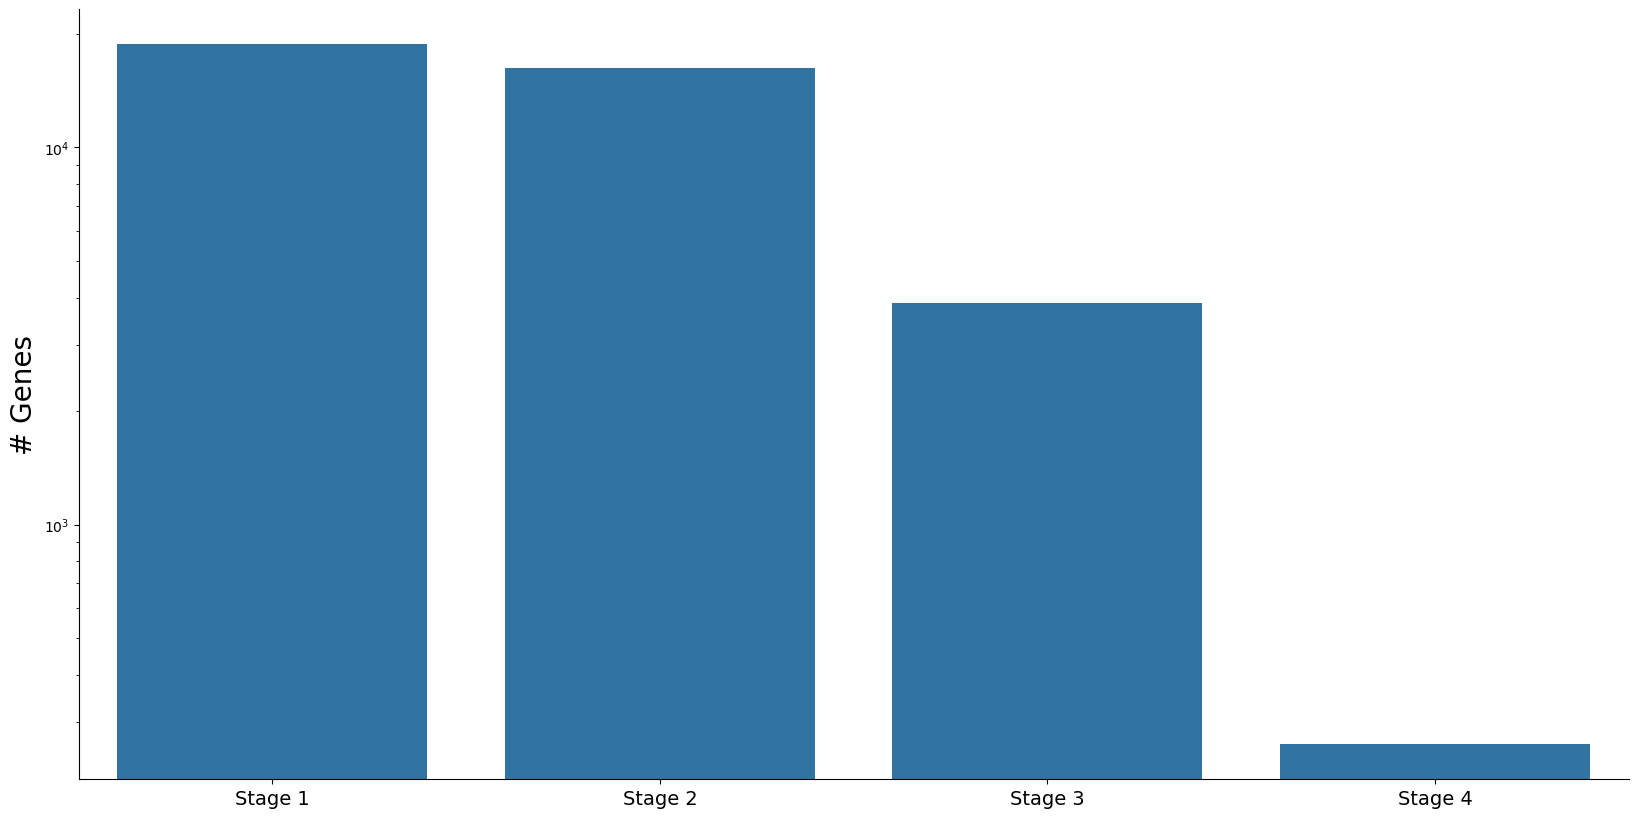

In [67]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(tot_s1_gene_list),len(tot_s2_gene_list),len(tot_s3_gene_list),len(tot_s4_gene_list)]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()
plt.savefig('Figures/NumberGenesperStage_Male_RemovedPriorGenes_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")

# Show the plot
plt.show

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/3740635484.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

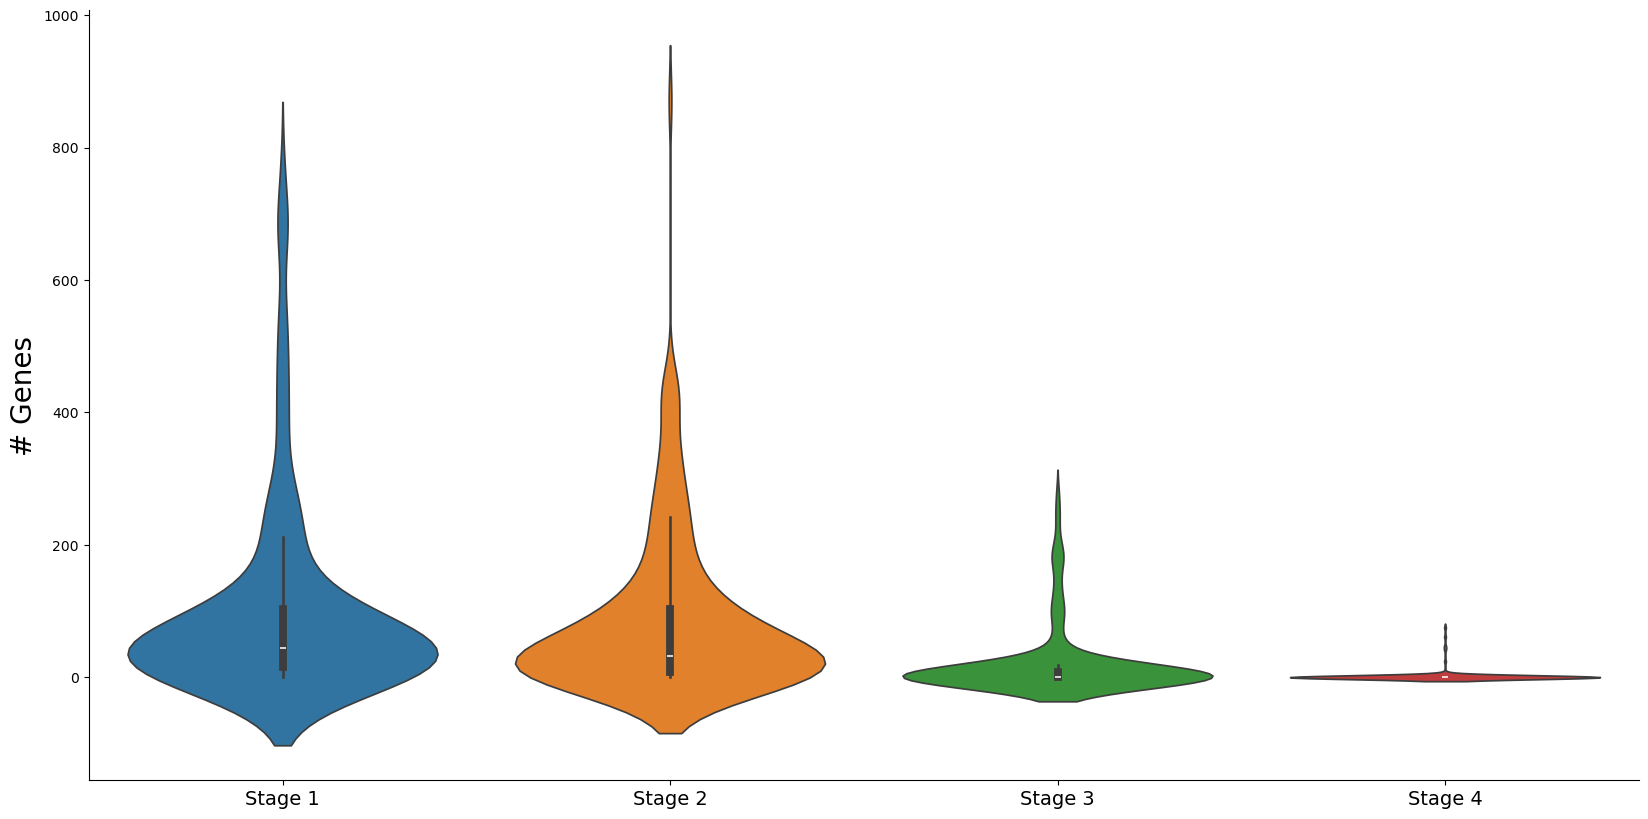

In [68]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_gene_list,trj_s2_gene_list,trj_s3_gene_list,trj_s4_gene_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeGenesTrajperStage_Male_RemovePriorGenes_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/1039938166.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


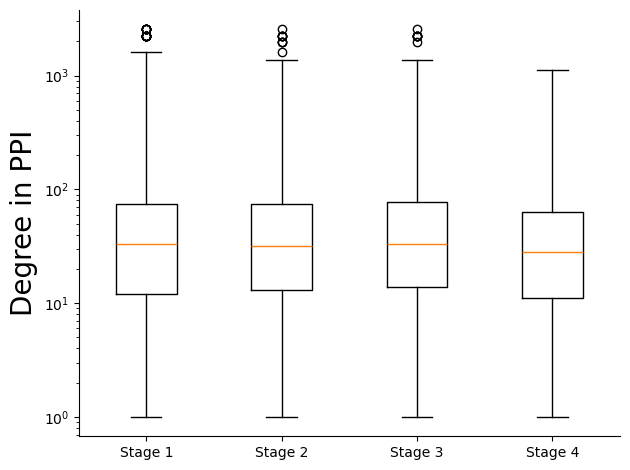

In [69]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

plt.ylabel('Degree in PPI',fontsize=20)
comparing_group_list= [
            [G_ppi.degree(gene) for gene in tot_s1_gene_list],
            [G_ppi.degree(gene) for gene in tot_s2_gene_list],
            [G_ppi.degree(gene) for gene in tot_s3_gene_list],
            [G_ppi.degree(gene) for gene in tot_s4_gene_list]
]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.yscale("log")
plt.tight_layout()

plt.show()



In [70]:
print(np.median([G_ppi.degree(gene) for gene in tot_s1_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s2_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s3_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s4_gene_list]))

33.0
32.0
33.0
28.0


In [71]:
#Let's make a dictionary that takes all the genes associated with the diseases at each stage

tot_gen_gene_dict_removed_genes={}

tot_s1_gene_list=[]
tot_s2_gene_list=[]
tot_s3_gene_list=[]
tot_s4_gene_list=[]


for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    genelist_s4 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    tot_s1_gene_list.extend(genelist_s1)
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1: 
                        if gene not in genelist_s2: 
                            genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    tot_s2_gene_list.extend(genelist_s2)
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2:
                        if gene not in genelist_s3:
                            genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    tot_s3_gene_list.extend(genelist_s3)
    try:
        for dis in stage_dict[4]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2 and gene not in genelist_s3:
                        if gene not in genelist_s4:
                            genelist_s4.append(gene)
            except:
                pass
    except:
        pass
    tot_s4_gene_list.extend(genelist_s4)
    
tot_gen_gene_dict_removed_genes[1] = tot_s1_gene_list
tot_gen_gene_dict_removed_genes[2] = tot_s2_gene_list
tot_gen_gene_dict_removed_genes[3] = tot_s3_gene_list
tot_gen_gene_dict_removed_genes[4] = tot_s4_gene_list






tot_gen_gene_dict_removed_genes_counter={}
for gen,genelist in tot_gen_gene_dict_removed_genes.items():
    genelist_count=Counter(genelist).most_common()
    tot_gen_gene_dict_removed_genes_counter[gen]=genelist_count

In [72]:
tot_gen_gene_dict_removed_genes_counter[1][:10]


[('TNF', 70),
 ('APOE', 44),
 ('HLA-DQB1', 42),
 ('IL6', 42),
 ('PTGS2', 38),
 ('IL1B', 36),
 ('MTHFR', 36),
 ('FTO', 36),
 ('TGFB1', 34),
 ('NR3C1', 33)]

In [73]:
tot_gen_gene_dict_removed_genes_counter[2][:10]


[('APOE', 40),
 ('NR3C1', 34),
 ('ACE', 33),
 ('ABO', 32),
 ('IL1B', 32),
 ('TGFB1', 31),
 ('IL6', 31),
 ('PTGS2', 31),
 ('NOS2', 30),
 ('CCL2', 30)]

In [74]:
tot_gen_gene_dict_removed_genes_counter[3][:10]


[('VEGFA', 10),
 ('PTGS2', 10),
 ('PLG', 10),
 ('HLA-DQA1', 10),
 ('IL6', 9),
 ('IL10', 9),
 ('CCL2', 8),
 ('LEP', 8),
 ('F2', 8),
 ('SIRT1', 8)]

In [75]:
tot_gen_gene_dict_removed_genes_counter[4][:10]


[('PRL', 2),
 ('CYP19A1', 2),
 ('PTHLH', 2),
 ('CCDC91', 2),
 ('RAB3GAP2', 2),
 ('ESR1', 2),
 ('EPHB1', 2),
 ('NR3C1', 2),
 ('TAAR8', 2),
 ('TAAR9', 2)]

In [76]:
for gen,genelist in tot_gen_gene_dict_removed_genes_counter.items():
    print(gen,len(set(genelist)))

1 5062
2 5173
3 2078
4 249


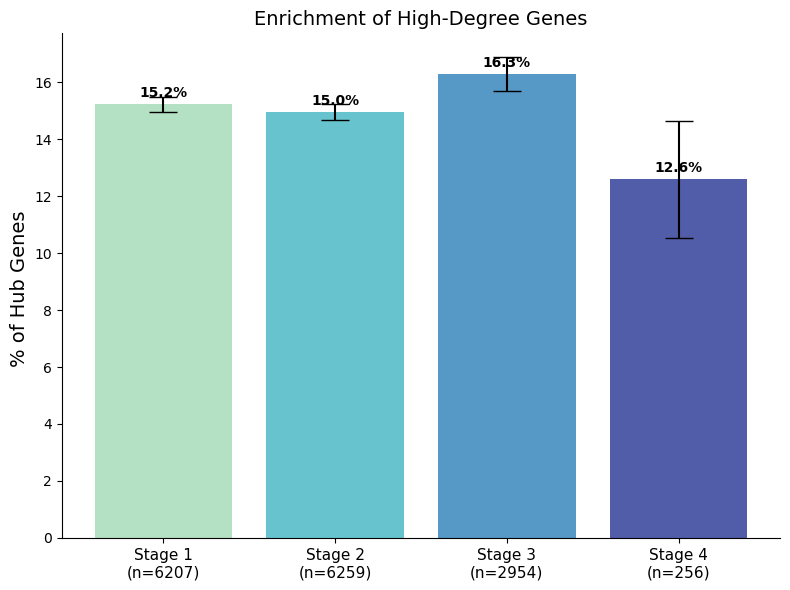

In [77]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

# 1. Gather your data
data_lists = [
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[1]], # Stage 1
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[2]], # Stage 2
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[3]], # Stage 3
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[4]]  # Stage 4
]
labels = ['Stage 1\n(n=6207)', 'Stage 2\n(n=6259)', 'Stage 3\n(n=2954)', 'Stage 4\n(n=256)']

# 2. Define "High Degree" (The Tail)
# In scale-free networks, the median is always low. The difference is in the top 10%.
# Let's define "Hubs" as the top 10% of the combined data, or a fixed number (e.g., > 20 connections)
all_degrees = np.concatenate(data_lists)
hub_threshold = np.percentile(list(dict(nx.degree(G_ppi)).values()), 90) # Top 10% cutoff
# Alternatively, set a hard threshold: hub_threshold = 50

proportions = []
errors = []

for data in data_lists:
    n = len(data)
    # Count how many genes are "Hubs"
    hub_count = sum(1 for x in data if x >= hub_threshold)
    
    # Calculate Proportion
    p = hub_count / n
    proportions.append(p * 100) # Convert to %
    
    # Calculate Standard Error for Proportion: sqrt( p*(1-p) / n )
    # This specifically accounts for the small N of Stage 4!
    sem = sqrt((p * (1 - p)) / n)
    errors.append(sem * 100) # Convert to %

# 3. Plot
fig, ax = plt.subplots(figsize=(8, 6))

x_pos = np.arange(len(labels))
bars = ax.bar(x_pos, proportions, yerr=errors, align='center', 
              alpha=0.8, ecolor='black', capsize=10, 
              color=['#a1dab4', '#41b6c4', '#2c7fb8', '#253494'])

ax.set_ylabel(f'% of Hub Genes ', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11)
ax.set_title(f'Enrichment of High-Degree Genes', fontsize=14)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()


plt.savefig('Figures/Hub_Percentage_Male_RemovedGenes_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [78]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

# 1. Setup Data (Recalculating the counts from your lists)
# ---------------------------------------------------------
data_lists = [
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[1]], # Stage 1
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[2]], # Stage 2
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[3]], # Stage 3
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[4]]  # Stage 4
]
stage_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
hub_threshold = np.percentile(list(dict(nx.degree(G_ppi)).values()), 90)

# Create a summary table: [Successes (Hubs), Total N]
successes = []
nobs = [] # Number of observations

for data in data_lists:
    n = len(data)
    count_hubs = sum(1 for x in data if x >= hub_threshold)
    successes.append(count_hubs)
    nobs.append(n)

print(f"Threshold for 'High Degree': >= {hub_threshold}")
print(f"Counts of Hubs: {successes}")
print(f"Total Genes (N): {nobs}")
print("-" * 30)

# 2. Global Test: Chi-Squared
# ---------------------------------------------------------
# We construct a contingency table:
# [[Non-Hubs_S1, Hubs_S1],
#  [Non-Hubs_S2, Hubs_S2], ...]
contingency_table = []
for i in range(4):
    contingency_table.append([nobs[i] - successes[i], successes[i]])

chi2, p_global, dof, expected = chi2_contingency(contingency_table)

print(f"Global Chi-Squared Test P-value: {p_global:.2e}")
if p_global < 0.05:
    print(">> Result: Significant difference found among stages.")
else:
    print(">> Result: No significant difference found.")

print("-" * 30)

# 3. Post-Hoc Test: Pairwise Z-Test (Stage X vs Stage Y)
# ---------------------------------------------------------
# Only meaningful if Global P < 0.05
if p_global < 0.05:
    print("Pairwise Comparisons (Stage vs Stage):")
    
    # Compare Stage 1 vs Stage 4 (or any other pair)
    # You can loop through all combinations if needed
    pairs_to_test = [(0, 1), (0, 2), (0, 3), (2, 3)] # Indices of stages to compare
    
    for i, j in pairs_to_test:
        count = np.array([successes[i], successes[j]])
        nobs_pair = np.array([nobs[i], nobs[j]])
        
        stat, p_val = proportions_ztest(count, nobs_pair)
        
        # Bonferroni correction: Multiply p-value by number of tests done? 
        # Or just keep it raw for now. Usually, p < 0.05/Number_of_tests is safe.
        
        sig = "*" if p_val < 0.05 else "ns"
        print(f"{stage_names[i]} vs {stage_names[j]}: p={p_val:.2e} ({sig})")

Threshold for 'High Degree': >= 118.5
Counts of Hubs: [2858, 2423, 630, 33]
Total Genes (N): [18760, 16206, 3869, 262]
------------------------------
Global Chi-Squared Test P-value: 1.27e-01
>> Result: No significant difference found.
------------------------------


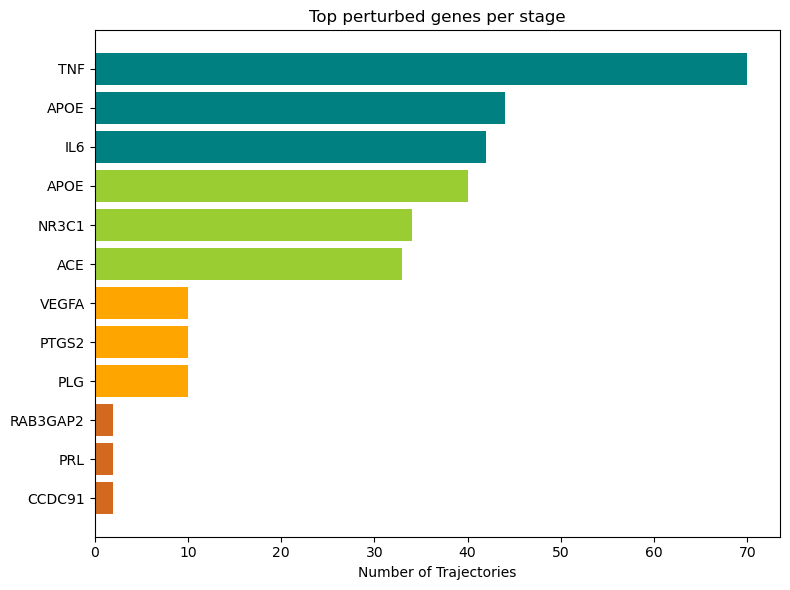

In [79]:
#Let's make it as a barplot
dis_list = ['TNF','APOE','IL6','APOE','NR3C1','ACE','VEGFA','PTGS2','PLG','RAB3GAP2','PRL','CCDC91']
frequency_list = [70,44,42,40,34,33,10,10,10,2,2,2]
color_list = ['teal', 'yellowgreen','orange','chocolate']
# Assign colors cycling every three bars
bar_colors = [color_list[(i // 3) % len(color_list)] for i in range(len(dis_list))]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(dis_list))

ax.barh(y_pos, frequency_list, color=bar_colors, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dis_list)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top perturbed genes per stage')

plt.tight_layout()
plt.savefig('Figures/MaleGeneFrequencyBarplot_RemovePriorGenes_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()




In [89]:
#ENRICH

In [80]:

tot_gen_gene_dict_removed_genes_counter_df={}

for gen,genecount in tot_gen_gene_dict_removed_genes_counter.items():
    rank_df=pd.DataFrame(columns=('gene', 'rank'))
    gene_list=[]
    rank_genelist=[]
    for el in genecount:
        gene_list.append(el[0])
        rank_genelist.append(el[1])
    rank_df['gene']=gene_list
    rank_df['rank']=rank_genelist
    rank_df=rank_df.sort_values(by=['rank'],ascending=False)
    tot_gen_gene_dict_removed_genes_counter_df[gen]=rank_df

In [81]:



for gen,rank_df in tot_gen_gene_dict_removed_genes_counter_df.items():
        
    lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
                     processes=4,min_size=3,max_size=5000,outdir=None,   #we impose at least 5 enriched common genes
                     permutation_num=500) # reduce number to speed up testing
    # to save your figure, make sure that ``ofname`` is not None
    ax = dotplot(lib_pre_res.res2d,
                 column="FDR q-val",
                 title='Male KEGG at stage %s'%gen,
                 cmap=plt.cm.viridis,
                 size=6, # adjust dot size
                 figsize=(4,5), cutoff=0.25, ofname='Figures/Male KEGG Removed Prior Genes at stage %s_v2026_official.pdf'%gen, show_ring=False)

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/4206798570.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2026-03-09 17:31:57,173 [WARNING] Duplicated values found in preranked stats: 99.25% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/4206798570.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2026-03-09 17:31:58,126 [WARNING] Duplicated values found in preranked stats: 99.38% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/4206798570.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2026-03-09 17:31:59,210 

In [82]:

trj_deg_dict = {}
for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    genelist_s4 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1: 
                        if gene not in genelist_s2: 
                            genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2:
                        if gene not in genelist_s3:
                            genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    try:
        for dis in stage_dict[4]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2 and gene not in genelist_s3:
                        if gene not in genelist_s4:
                            genelist_s4.append(gene)
            except:
                pass
    except:
        pass
    genelist_s1_deglist = [G_ppi.degree(gene) for gene in genelist_s1]
    genelist_s2_deglist = [G_ppi.degree(gene) for gene in genelist_s2]
    genelist_s3_deglist = [G_ppi.degree(gene) for gene in genelist_s3]
    genelist_s4_deglist = [G_ppi.degree(gene) for gene in genelist_s4]
    trj_deg_dict[trj] = [np.median(genelist_s1_deglist),np.median(genelist_s2_deglist),np.median(genelist_s3_deglist),np.median(genelist_s4_deglist)]
    #trj_deg_dict[trj] = [np.mean(genelist_s1_deglist),np.mean(genelist_s2_deglist),np.mean(genelist_s3_deglist),np.mean(genelist_s4_deglist)]





/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [83]:
stage_avg_deg_stage_dict = {}
for i in range(4):
    deglist = []
    for trj,avgdeglist in trj_deg_dict.items():
        if str(avgdeglist[i])!='nan':
            deglist.append(avgdeglist[i])
    stage_avg_deg_stage_dict[i+1] = deglist


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/706722444.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


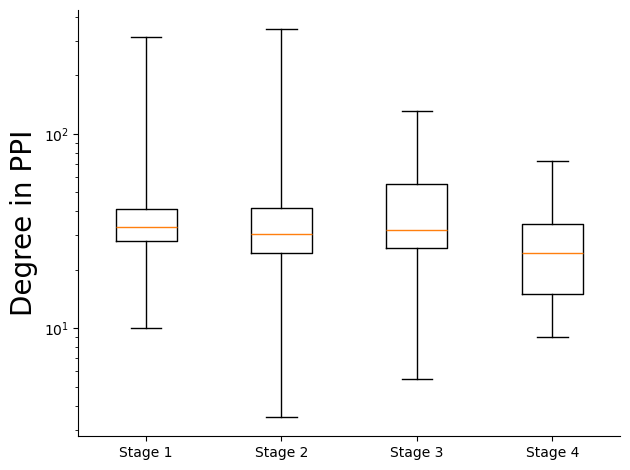

In [84]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

plt.ylabel('Degree in PPI',fontsize=20)
comparing_group_list= list(stage_avg_deg_stage_dict.values())
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.yscale("log")
plt.tight_layout()
plt.savefig('Figures/MedianDegreeperTrjperStage_Male_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()


In [85]:


t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[1],stage_avg_deg_stage_dict[2])
print("T-test Stage 1 vs Stage 2, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[1],stage_avg_deg_stage_dict[3])
print("T-test Stage 1 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[1],stage_avg_deg_stage_dict[4])
print("T-test Stage 1 vs Stage 4, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[2],stage_avg_deg_stage_dict[3])
print("T-test Stage 2 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[2],stage_avg_deg_stage_dict[4])
print("T-test Stage 2 vs Stage 4, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[3],stage_avg_deg_stage_dict[4])
print("T-test Stage 3 vs Stage 4, p-value is %s"%p_value)

T-test Stage 1 vs Stage 2, p-value is 0.22851056827147023
T-test Stage 1 vs Stage 3, p-value is 0.7184179511727407
T-test Stage 1 vs Stage 4, p-value is 0.34101982607926784
T-test Stage 2 vs Stage 3, p-value is 0.5885537172967094
T-test Stage 2 vs Stage 4, p-value is 0.5149022705524948
T-test Stage 3 vs Stage 4, p-value is 0.2685900779132761


In [356]:
#Here, we remove the diseases that have been diagnosed already the previous time-point

In [86]:
male_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict = {}

for trj, disdict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    dis_dict_gen = {}
    back_dis_state = list(disdict[1])  # Ensure this is a new list to avoid modifying the original

    for i in range(1, len(disdict) + 1):  # Start from the second key
        if i==1:
            dis_dict_gen[i] = disdict[1]
        else:
            i_dis = []
            for dis in disdict[i]:
                if dis not in back_dis_state:
                    i_dis.append(dis)
                    back_dis_state.append(dis)  # Add the new disease to the tracked state
            if i_dis:  # Only include non-empty lists
                dis_dict_gen[i] = i_dis

    if len(dis_dict_gen) > 1:  # Ensure there is more than one state to include in the result
        male_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict[trj] = dis_dict_gen

print(len(male_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict))

190


In [87]:
#Let's see how many diseases are present at each stage for any trajectory:

tot_s1_dis_list=[]
tot_s2_dis_list=[]
tot_s3_dis_list=[]
tot_s4_dis_list=[]


trj_s1_dis_list=[]
trj_s2_dis_list=[]
trj_s3_dis_list=[]
trj_s4_dis_list=[]

for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict.items():
    try:
        tot_s1_dis_list.extend(stage_dict[1])
    except:
        pass
    try:
        tot_s2_dis_list.extend(stage_dict[2])
    except:
        pass
    try:
        tot_s3_dis_list.extend(stage_dict[3])
    except:
        pass
    try:
        tot_s4_dis_list.extend(stage_dict[4])
    except:
        pass

for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict.items():
    try:
        trj_s1_dis_list.append(len(stage_dict[1]))
    except:
        pass
    try:
        trj_s2_dis_list.append(len(stage_dict[2]))
    except:
        pass
    try:
        trj_s3_dis_list.append(len(stage_dict[3]))
    except:
        pass
    try:
        trj_s4_dis_list.append(len(stage_dict[4]))
    except:
        pass
    
    

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/4209621840.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

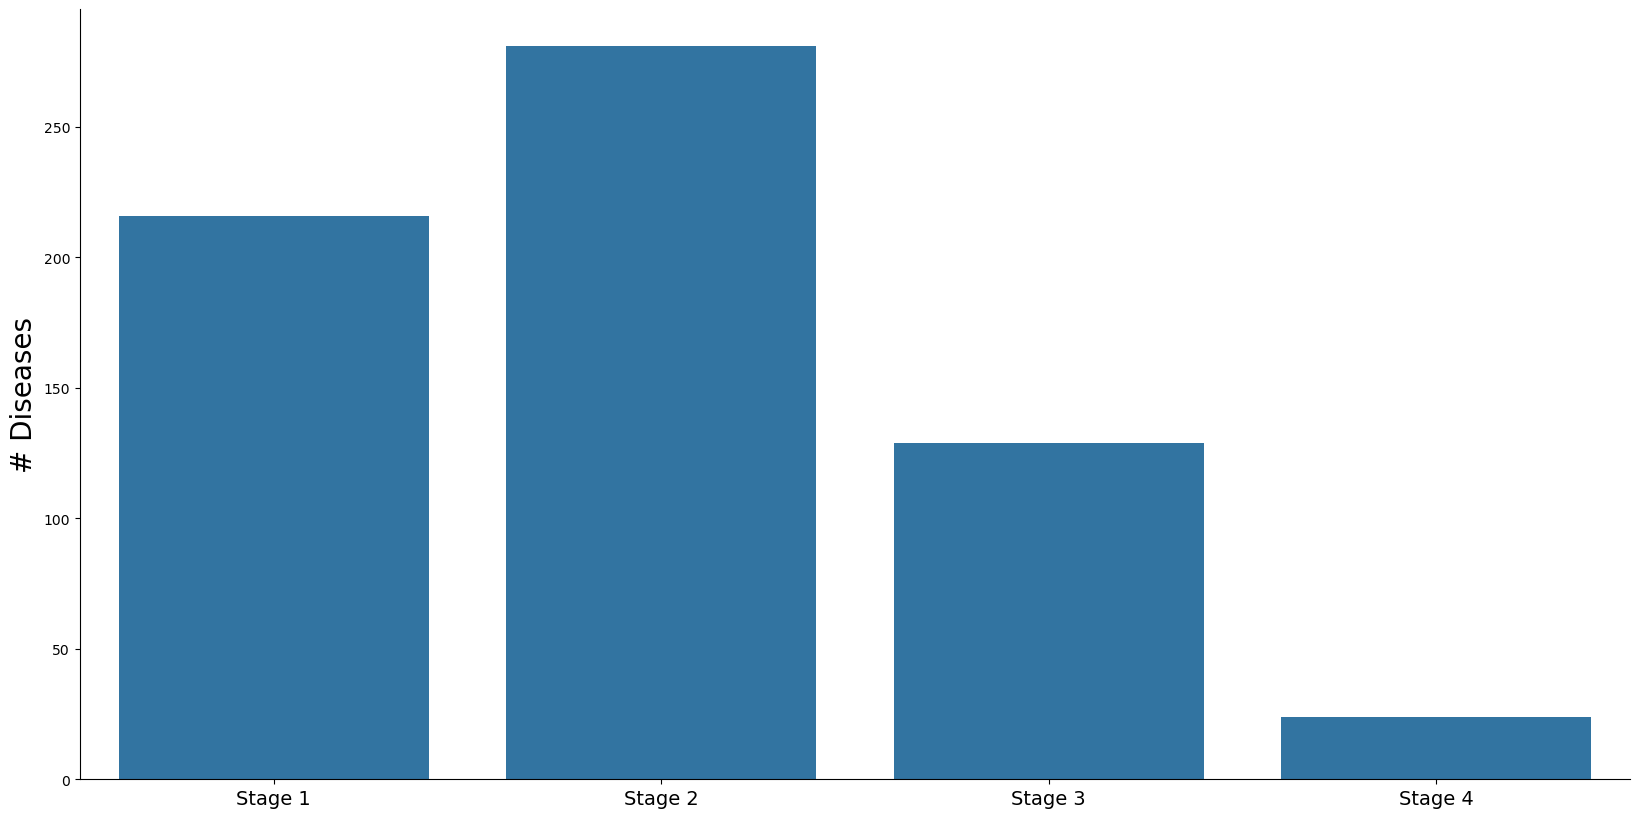

In [88]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(set(tot_s1_dis_list)),len(set(tot_s2_dis_list)),len(set(tot_s3_dis_list)),len(set(tot_s4_dis_list))]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()
plt.savefig('Figures/NumberDiseasesperStage_Male_RemovedPriorDiseases_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")

# Show the plot
plt.show

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_91494/3330392558.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

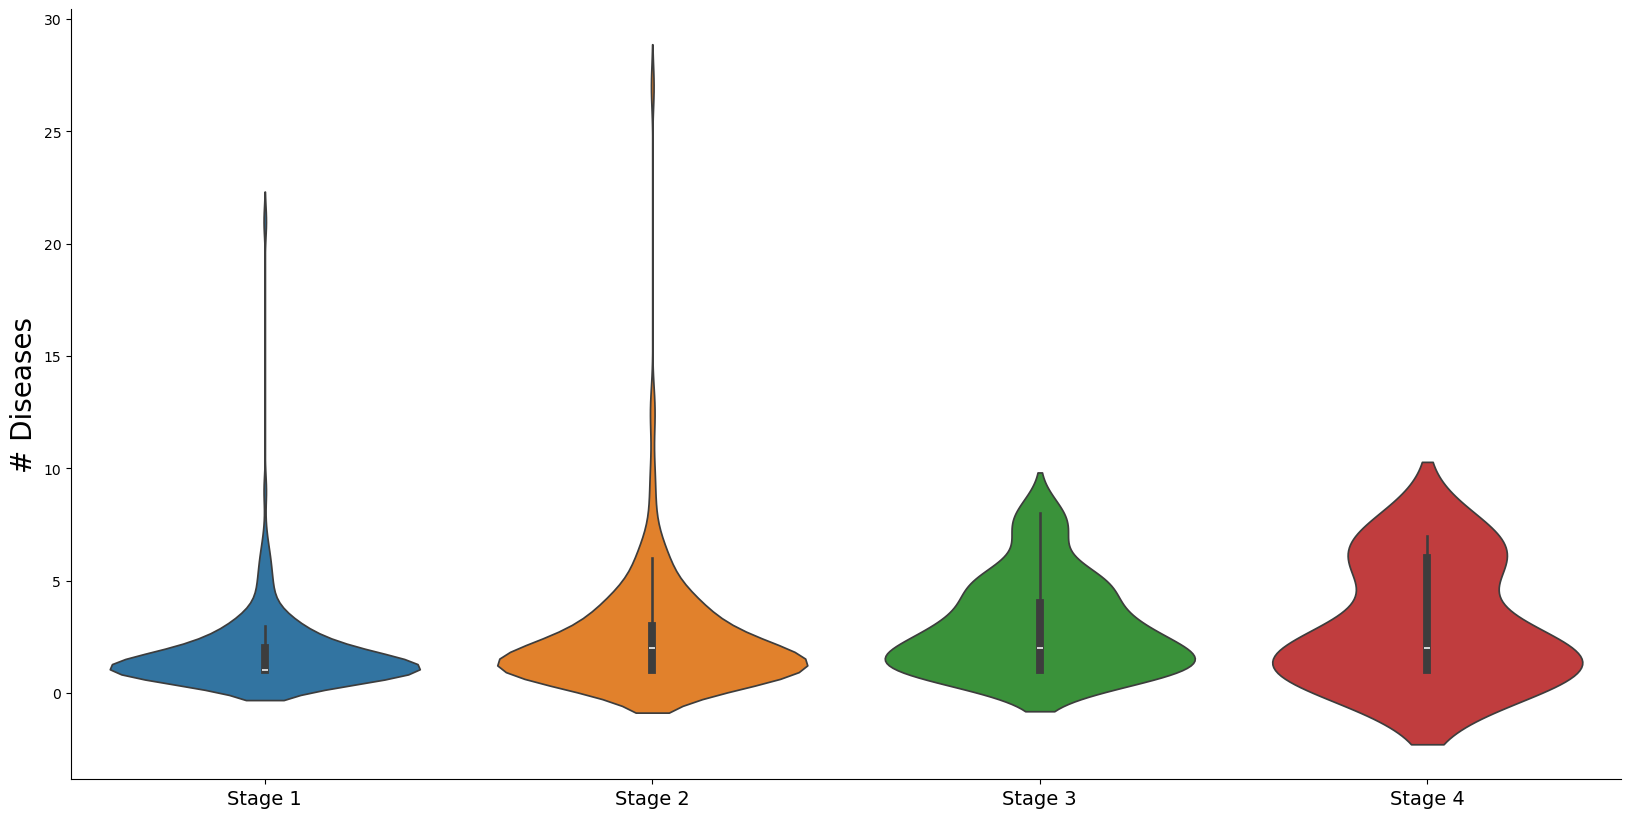

In [89]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3',
        'Stage 4']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_dis_list,trj_s2_dis_list,trj_s3_dis_list,trj_s4_dis_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeDiseaseTrajperStage_Male_RemovedPriorDiseases_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show



# Female

In [44]:
female_trajectories_df=pd.read_excel('input/All identified trajectories in females. trajectories smaller than 100 members.xlsx')

In [130]:
with open('output/female_trajectories_dict_filtered_v2026_official.pickle', 'rb') as handle:
    female_trajectories_dict_filtered = pk.load(handle)

with open('output/female_trajectories_dict_filtered_unique_v2026_official.pickle', 'rb') as handle:
    female_trajectories_dict_filtered_unique = pk.load(handle)

with open('output/female_trajectories_dict_filtered_unique_agglomerated_genes_v2026_official.pickle', 'rb') as handle:
    female_trajectories_dict_filtered_unique_agglomerated_genes = pk.load(handle)


In [9]:
len(female_trajectories_dict_filtered_unique)

305

In [200]:
diverge_pairs_female_df = pd.read_csv("input/Diverge_Pairs/Diverge_Pairs_Females.csv")

In [201]:

female_diverge_pairs_dict_dis_differences = {}
for i,v in diverge_pairs_female_df.iterrows():
    dis_difference_1 = []
    dis_difference_2 = []
    trj_1 = v['Cluster1'].replace("__","-")
    trj_2 = v['Cluster2'].replace("__","-")
    new_trj_1 = trj_1.replace(" ","")
    new_trj_2 = trj_2.replace(" ","")
    dis_list_trj_1 = []
    for distim in new_trj_1.split(","):
        dis_list_trj_1.append(distim.split("-")[0])
    dis_list_trj_2 = []
    for distim in new_trj_2.split(","):
        dis_list_trj_2.append(distim.split("-")[0])
    for dis in dis_list_trj_1:
        if dis not in dis_list_trj_2:
            dis_difference_1.append(dis)
    for dis in dis_list_trj_2:
        if dis not in dis_list_trj_1:
            dis_difference_2.append(dis)
    if len(set(dis_difference_1))>0 and len(set(dis_difference_2))>0:
        female_diverge_pairs_dict_dis_differences[i]=[set(dis_difference_1),set(dis_difference_2)]




In [202]:
#Let's try to extract the genes that are representative of these differences

female_diverge_pairs_dict_gene_differences = {}
for idx,div_pair_list in female_diverge_pairs_dict_dis_differences.items():
    gene_list_1 = []
    gene_list_2 = []
    for dis in div_pair_list[0]:
        try:
            for gene in icd_genes_ppi_dict[dis]:
                if gene not in gene_list_1:
                    gene_list_1.append(gene)
        except:
            pass
    for dis in div_pair_list[1]:
        try:
            for gene in icd_genes_ppi_dict[dis]:
                if gene not in gene_list_2:
                    gene_list_2.append(gene)
        except:
            pass
    female_diverge_pairs_dict_gene_differences[idx]=[set(gene_list_1),set(gene_list_2)]
    

In [ ]:
female_diverge_pairs_dict_gene_differences_pval = {}
female_diverge_pairs_dict_gene_differences_fdr = {}


for idx,geneset_list in female_diverge_pairs_dict_gene_differences.items():
    pval_ov = float(overlap_genelists(geneset_list[0],geneset_list[1]))
    female_diverge_pairs_dict_gene_differences_pval[idx] = pval_ov

adj_pval=fdr_adjustment(list(female_diverge_pairs_dict_gene_differences_pval.values()),0.05)
pair_list=list(female_diverge_pairs_dict_gene_differences_pval.keys())
for i in range(len(adj_pval)):
    female_diverge_pairs_dict_gene_differences_fdr[pair_list[i]]=adj_pval[i]
print(len([trj for trj in female_diverge_pairs_dict_gene_differences_fdr.keys() if female_diverge_pairs_dict_gene_differences_fdr[trj]<0.05]))
print(len(female_diverge_pairs_dict_gene_differences))
#17 out of 28 trajectories show gene similarities between the two possibilities

17
28


In [204]:
#Let's check for the degree in the PPI
female_diverge_pairs_dict_gene_degree_differences = {}
for idx,genesetlist in female_diverge_pairs_dict_gene_differences.items():
    deg_list_1 = []
    deg_list_2 = []
    for gene in genesetlist[0]:
        deg_list_1.append(G_ppi.degree(gene))
    for gene in genesetlist[1]:
        deg_list_2.append(G_ppi.degree(gene))
    female_diverge_pairs_dict_gene_degree_differences[idx]=[deg_list_1,deg_list_2]
        

In [205]:
#Let's see whether there are differences in degree by performing a Mann-Withney test


female_diverge_pairs_dict_gene_degree_differences_pval = {}
female_diverge_pairs_dict_gene_degree_differences_fdr = {}

for idx,deg_list in female_diverge_pairs_dict_gene_degree_differences.items():
    try:
        t, p = stats.mannwhitneyu(deg_list[0], deg_list[1])
        if str(p)!='nan':
            female_diverge_pairs_dict_gene_degree_differences_pval[idx] = float(p)
    except:
        pass

adj_pval=fdr_adjustment(list(female_diverge_pairs_dict_gene_degree_differences_pval.values()),0.05)
pair_list=list(female_diverge_pairs_dict_gene_degree_differences_pval.keys())
for i in range(len(adj_pval)):
    female_diverge_pairs_dict_gene_degree_differences_fdr[pair_list[i]]=adj_pval[i]
    
print(len([trj for trj in female_diverge_pairs_dict_gene_degree_differences_fdr.keys() if female_diverge_pairs_dict_gene_degree_differences_fdr[trj]<0.05]))

#Most of these trajectories are statistically significantly different for degree

5


In [206]:
#Let's try with keeping the gene repetition

female_diverge_pairs_dict_gene_degree_differences_pval = {}
female_diverge_pairs_dict_gene_degree_differences_fdr = {}
for trj,trj_dis_set in female_diverge_pairs_dict_dis_differences.items():
    genelist_1 = []
    genelist_2 = []
    for dis in trj_dis_set[0]:
        try:
            genelist_1.extend(icd_genes_ppi_dict[dis])
        except:
            pass
    for dis in trj_dis_set[1]:
        try:
            genelist_2.extend(icd_genes_ppi_dict[dis])
        except:
            pass
    if len(genelist_1)>0 and len(genelist_2)>0:
        genelist_1_deg = [G_ppi.degree(gene) for gene in genelist_1]
        genelist_2_deg = [G_ppi.degree(gene) for gene in genelist_2]
        t, p = stats.mannwhitneyu(genelist_1_deg, genelist_2_deg)
        if str(p)!='nan':
            female_diverge_pairs_dict_gene_degree_differences_pval[trj] = float(p)


adj_pval=fdr_adjustment(list(female_diverge_pairs_dict_gene_degree_differences_pval.values()),0.05)
pair_list=list(female_diverge_pairs_dict_gene_degree_differences_pval.keys())
for i in range(len(adj_pval)):
    female_diverge_pairs_dict_gene_degree_differences_fdr[pair_list[i]]=adj_pval[i]
    
print(len([trj for trj in female_diverge_pairs_dict_gene_degree_differences_fdr.keys() if female_diverge_pairs_dict_gene_degree_differences_fdr[trj]<0.05]))



5


In [45]:
female_trajectories_df_copy=pd.DataFrame()
female_trajectories_df_copy['Community ID'] = female_trajectories_df['Community ID']

new_members_of_com_list=[]
for i in female_trajectories_df['Members'].tolist():
    new_i=i.replace("__","-")
    new_new_i=new_i.replace(" ","")
    new_members_of_com_list.append(new_new_i)
female_trajectories_df_copy['Members']=new_members_of_com_list

female_trajectories_df_copy.head()


,Community ID,Members
0,1,"I88-0-9,K56-0-9,K59-0-9,K60-0-9,K56-10-19"
1,2,"A08-0-9,A38-10-19,B01-10-19,H61-10-19,J38-10-19"
2,3,"A38-0-9,B97-0-9,E45-0-9,G47-0-9,H04-0-9,J10-0-..."
3,4,"A41-0-9,C91-0-9,C91-10-19"
4,5,"B00-0-9,B99-0-9,J05-0-9,J31-0-9,J40-0-9,K52-0-..."


In [46]:
female_trajectories_dict={}
for i,v in female_trajectories_df_copy.iterrows():
    dis_list=[]
    for dis in v['Members'].split(','):
        clean_dis=dis.split("-")[0]
        if clean_dis in allsources_icd_gene_dict_unified.keys():
            dis_list.append(dis)
    female_trajectories_dict[v['Community ID']]=dis_list

#Now, let's remove all the trajectories that are obvious (same disease)
female_trajectories_dict_filtered={}
for trj,dislist in female_trajectories_dict.items():
    new_dislist=[]
    if len(dislist)>1:
        for dis in dislist:
            new_dis=dis[:3]
            if new_dis not in new_dislist:
                if new_dis in allsources_icd_gene_dict_unified.keys():
                    new_dislist.append(new_dis)
    if len(new_dislist)>1:
        female_trajectories_dict_filtered[trj]=new_dislist

print(len(female_trajectories_dict_filtered))


354


In [47]:
#from dict to dataframe
female_trajectories_df = pd.DataFrame(list(female_trajectories_dict.items()), columns=['Community_ID', 'Members of community']) 
female_trajectories_df.to_csv("output/Female_Trajectories_DiseaseList_withGenes.tsv",index=False,sep="\t")

In [209]:

#First of all, is it always the case that when you have those diseases, their temporal evolution is established?

time_ordered=['0-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79']

female_trajectories_dis_sort_bytime_dict={}
for trj in female_trajectories_dict_filtered.keys():
    dislist = female_trajectories_dict[trj]
    dis_ordered_string=''
    for t in time_ordered:
        for dis in dislist:
            if t in dis:
                dis_ordered_string += str(dis[:3])
                dis_ordered_string += "_"
            else:
                dis_ordered_string += ">"
    female_trajectories_dis_sort_bytime_dict[trj]=dis_ordered_string
                
                


In [210]:
#Now that we have ordered diseases based on their temporal occurance, we can group them to identify only the emergence
#of new diseases
import re
def extract_elements(s):
    # Define a regular expression pattern for one or more '>' characters
    pattern = r'>+'
    
    # Use the re.split function to split the string by the specified pattern
    elements = re.split(pattern, s)
    
    # Filter out empty strings that may have resulted from splitting
    non_empty_elements = list(filter(None, elements))
    
    return non_empty_elements

female_trajectories_dis_sort_bytime_grouped_dict={}
for trj,dis_string in female_trajectories_dis_sort_bytime_dict.items():
    female_trajectories_dis_sort_bytime_grouped_dict[trj]=extract_elements(dis_string)
    

In [211]:
#Let's group disease trajectories based on the stage of occurrence

female_trajectories_dis_sort_bytime_grouped_add_dict={}

for trj,dislist in female_trajectories_dis_sort_bytime_grouped_dict.items():
    if len(dislist)>0:
        cl_dislist=[]
        for dis in dislist:
            new_dislist=dis.split("_")
            cl_dislist.append(new_dislist[:-1])
        female_trajectories_dis_sort_bytime_grouped_add_dict[trj]=cl_dislist

print(len(female_trajectories_dis_sort_bytime_grouped_add_dict))

female_trajectories_dis_sort_bytime_grouped_all_add_dict = {}
for trj, dislist in female_trajectories_dis_sort_bytime_grouped_add_dict.items():
    dis_dict_gen = {}
    for i in range(len(dislist)):
        dis_dict_gen[i + 1] = dislist[i]

    female_trajectories_dis_sort_bytime_grouped_all_add_dict[trj] = dis_dict_gen

print(len(female_trajectories_dis_sort_bytime_grouped_all_add_dict))


with open('output/female_trajectories_dis_sort_bytime_grouped_all_add_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(female_trajectories_dis_sort_bytime_grouped_all_add_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

354
354


In [212]:
#Let's focus only on those trajectories that have more than a single stage
#Now we will select only those diseases that occur in different period of times
female_trajectories_dis_sort_bytime_grouped_add_dict={}

for trj,dislist in female_trajectories_dis_sort_bytime_grouped_dict.items():
    if len(dislist)>1:
        cl_dislist=[]
        for dis in dislist:
            new_dislist=dis.split("_")
            cl_dislist.append(new_dislist[:-1])
        female_trajectories_dis_sort_bytime_grouped_add_dict[trj]=cl_dislist

print(len(female_trajectories_dis_sort_bytime_grouped_add_dict))

249


In [213]:
female_trajectories_dis_sort_bytime_grouped_all_add_dict = {}
for trj, dislist in female_trajectories_dis_sort_bytime_grouped_add_dict.items():
    dis_dict_gen = {}
    for i in range(len(dislist)):
        dis_dict_gen[i + 1] = dislist[i]

    female_trajectories_dis_sort_bytime_grouped_all_add_dict[trj] = dis_dict_gen

print(len(female_trajectories_dis_sort_bytime_grouped_all_add_dict))

249


In [214]:

#Let's extract only the evolving disease-trajectories
female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict = {}

for trj,gen_dict in female_trajectories_dis_sort_bytime_grouped_all_add_dict.items():
    if len(gen_dict)>1:
        new_dict = {}
        
        # Track diseases seen so far
        seen_diseases = set()
        
        # Iterate through the original dictionary
        for diseases in gen_dict.values():
            # Check if the list contains new diseases
            if any(disease not in seen_diseases for disease in diseases):
                # Add the list to the result with updated index
                new_dict[len(new_dict) + 1] = diseases
                # Update seen diseases with the current list
                seen_diseases.update(diseases)
        if len(new_dict)>1:
            female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj] = new_dict
            
print(len(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict))

161


In [215]:
with open('output/female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [216]:
female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df = pd.DataFrame.from_dict(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict, orient='index')
female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df.to_csv("output/female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df_v2026_official.tsv",sep="\t")


In [10]:
female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df = pd.read_csv("output/female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_df_v2026_official.tsv",sep="\t",index_col=0)

In [217]:
#Let's see how many diseases are present at each stage for any trajectory:

tot_s1_dis_list=[]
tot_s2_dis_list=[]
tot_s3_dis_list=[]



trj_s1_dis_list=[]
trj_s2_dis_list=[]
trj_s3_dis_list=[]


for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    try:
        tot_s1_dis_list.extend(stage_dict[1])
    except:
        pass
    try:
        tot_s2_dis_list.extend(stage_dict[2])
    except:
        pass
    try:
        tot_s3_dis_list.extend(stage_dict[3])
    except:
        pass



for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    try:
        trj_s1_dis_list.append(len(stage_dict[1]))
    except:
        pass
    try:
        trj_s2_dis_list.append(len(stage_dict[2]))
    except:
        pass
    try:
        trj_s3_dis_list.append(len(stage_dict[3]))
    except:
        pass



/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/2787720037.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

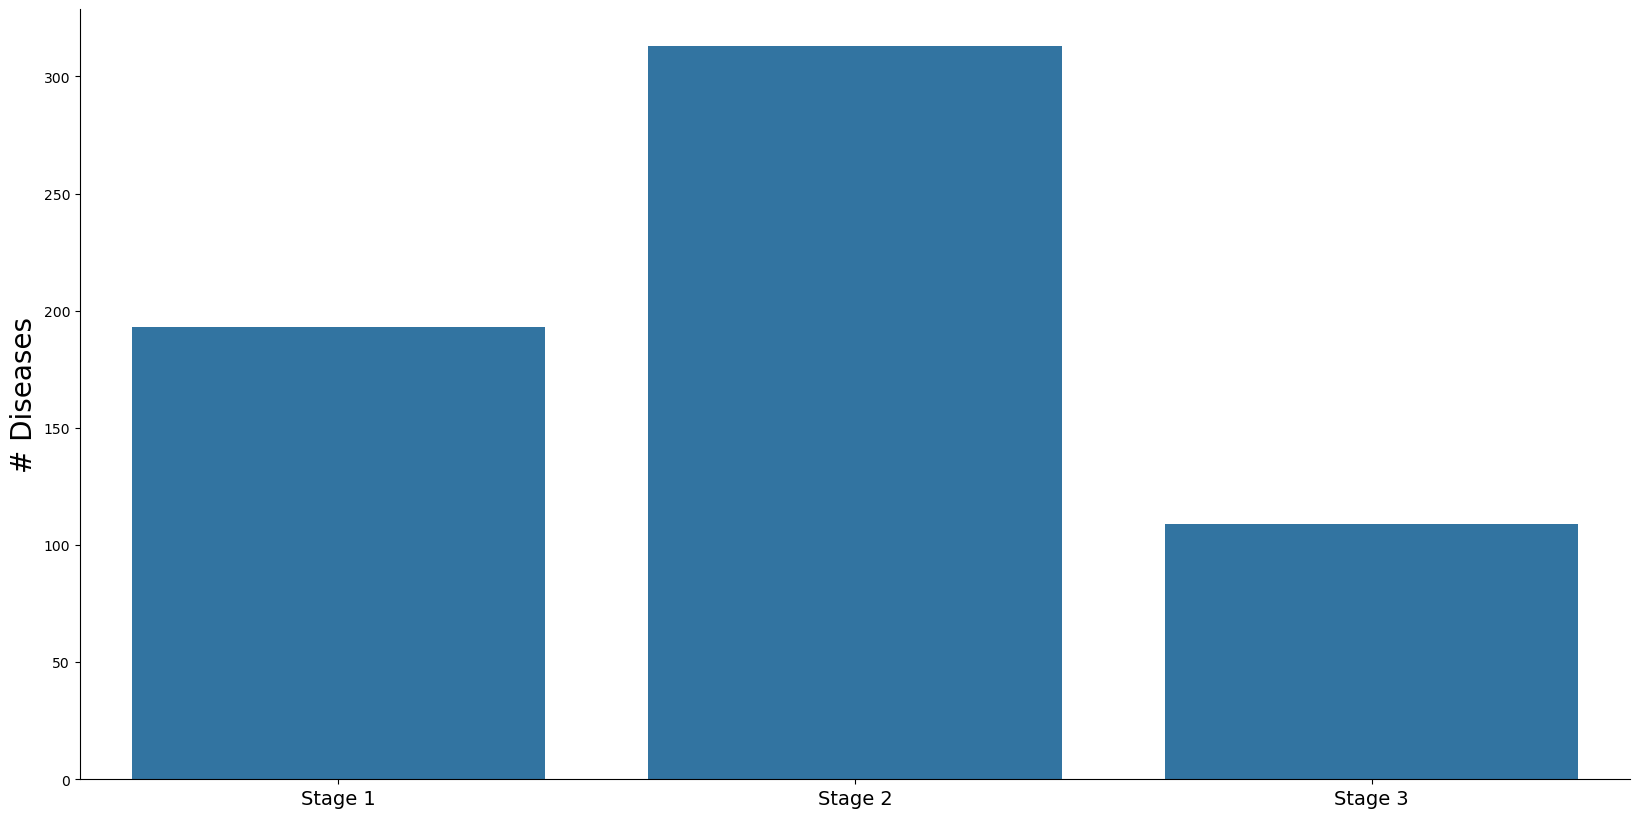

In [218]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(set(tot_s1_dis_list)),len(set(tot_s2_dis_list)),len(set(tot_s3_dis_list))]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/NumberDiseasesperStage_Female_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/212828456.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

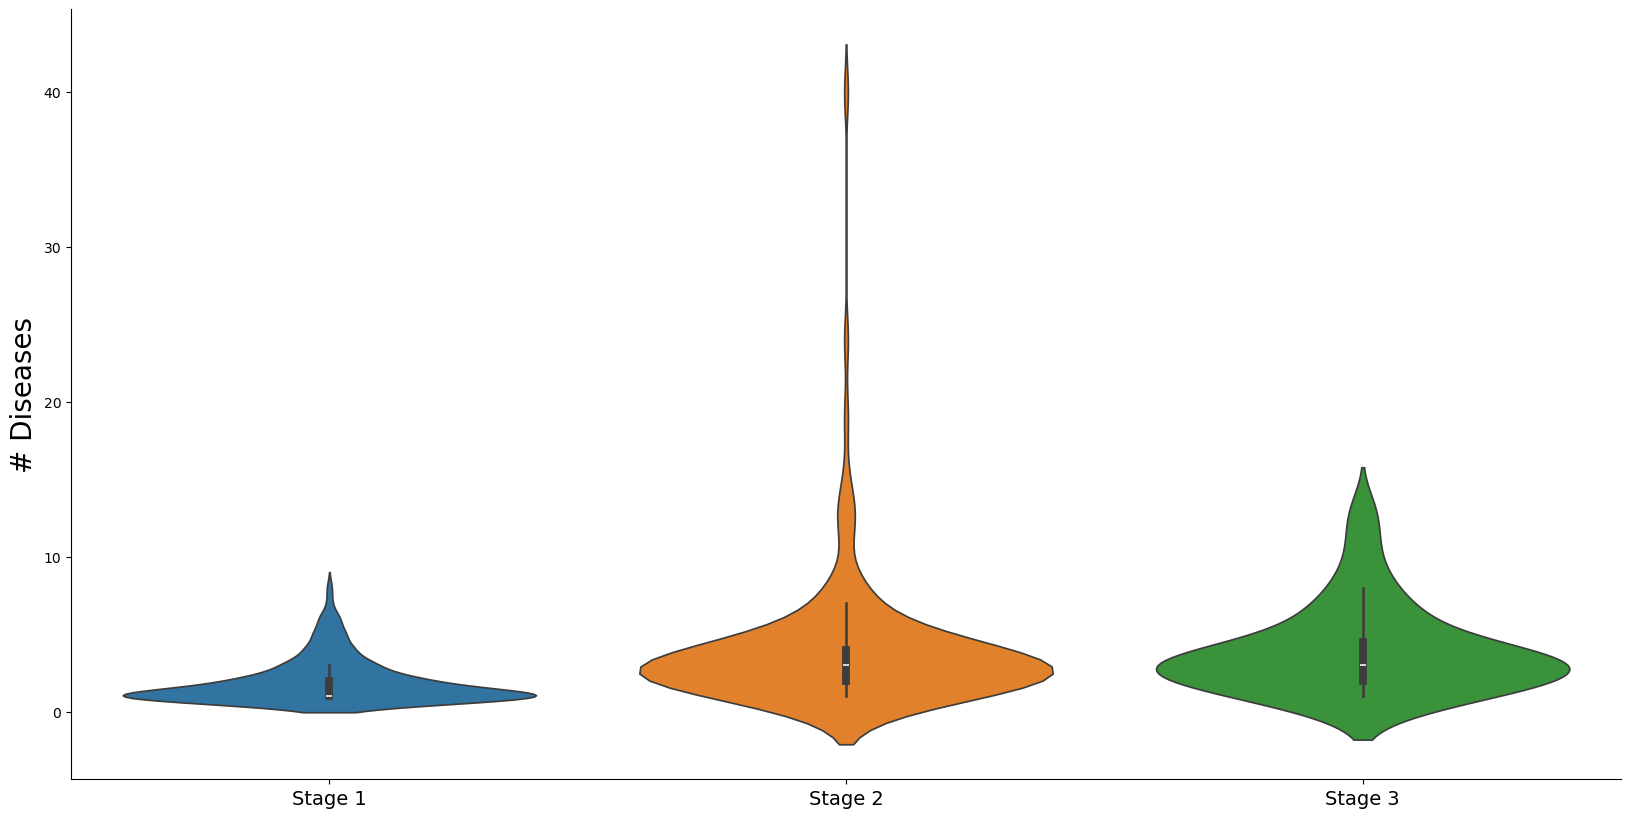

In [219]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_dis_list,trj_s2_dis_list,trj_s3_dis_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeDiseaseTrajperStage_Female_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show


In [221]:

print("The number of disease trajectory in Stage 1 is %s and their average size is %s"%(len(trj_s1_dis_list),np.median(trj_s1_dis_list)))
print("The number of disease trajectory in Stage 2 is %s and their average size is %s"%(len(trj_s2_dis_list),np.median(trj_s2_dis_list)))
print("The number of disease trajectory in Stage 3 is %s and their average size is %s"%(len(trj_s3_dis_list),np.median(trj_s3_dis_list)))


The number of disease trajectory in Stage 1 is 161 and their average size is 1.0
The number of disease trajectory in Stage 2 is 161 and their average size is 3.0
The number of disease trajectory in Stage 3 is 35 and their average size is 3.0


In [222]:
from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(trj_s1_dis_list,trj_s2_dis_list)
print("T-test Stage 1 vs Stage 2, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s1_dis_list,trj_s3_dis_list)
print("T-test Stage 1 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(trj_s2_dis_list,trj_s3_dis_list)
print("T-test Stage 2 vs Stage 3, p-value is %s"%p_value)


T-test Stage 1 vs Stage 2, p-value is 4.5712133869394126e-08
T-test Stage 1 vs Stage 3, p-value is 8.097729297292364e-09
T-test Stage 2 vs Stage 3, p-value is 0.981696959786954


In [223]:
#Let's make a dictionary that takes all the diseases at each stage and their frequency

tot_gen_dis_dict={}
for i in range(1,4):
    tot_dislist = []
    for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        try:
            tot_dislist.extend(list(stage_dict[i]))
        except:
            pass
    tot_gen_dis_dict[i] = tot_dislist


tot_gen_dis_counter_dict={}
for gen,dislist in tot_gen_dis_dict.items():
    dislist_count=Counter(dislist).most_common()
    tot_gen_dis_counter_dict[gen]=dislist_count

In [224]:
for gen,dislist in tot_gen_dis_counter_dict.items():
    print(gen)
    print(dislist[:3])

1
[('M51', 6), ('D70', 5), ('G47', 4)]
2
[('M48', 9), ('M51', 7), ('M43', 6)]
3
[('G63', 3), ('G57', 3), ('M51', 3)]


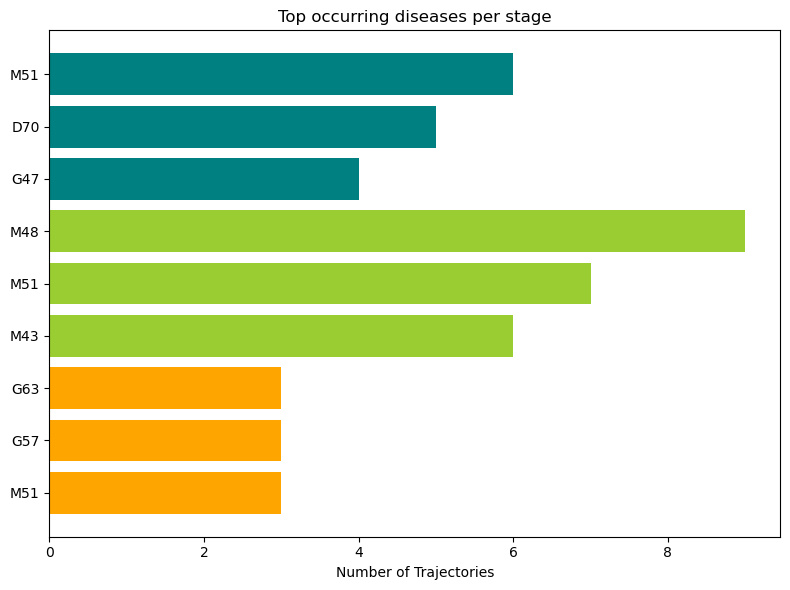

In [225]:
#Let's make it as a barplot
dis_list = ['M51','D70','G47','M48','M51','M43','G63','G57','M51']
frequency_list = [6,5,4,9,7,6,3,3,3]
color_list = ['teal', 'yellowgreen','orange']
# Assign colors cycling every three bars
bar_colors = [color_list[(i // 3) % len(color_list)] for i in range(len(dis_list))]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(dis_list))

ax.barh(y_pos, frequency_list, color=bar_colors, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dis_list)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top occurring diseases per stage')

plt.tight_layout()
plt.savefig('Figures/FemaleDisFrequencyBarplot_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [226]:
#Now, let's select the total number of genes associated with each stage

tot_s1_gene_list=[]
tot_s2_gene_list=[]
tot_s3_gene_list=[]


for dis in tot_s1_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s1_gene_list:
                tot_s1_gene_list.append(gene)
    except:
        pass

for dis in tot_s2_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s2_gene_list:
                tot_s2_gene_list.append(gene)
    except:
        pass

for dis in tot_s3_dis_list:
    try:
        for gene in icd_genes_ppi_dict[dis]:
            if gene not in tot_s3_gene_list:
                tot_s3_gene_list.append(gene)
    except:
        pass
        



/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/3328590873.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

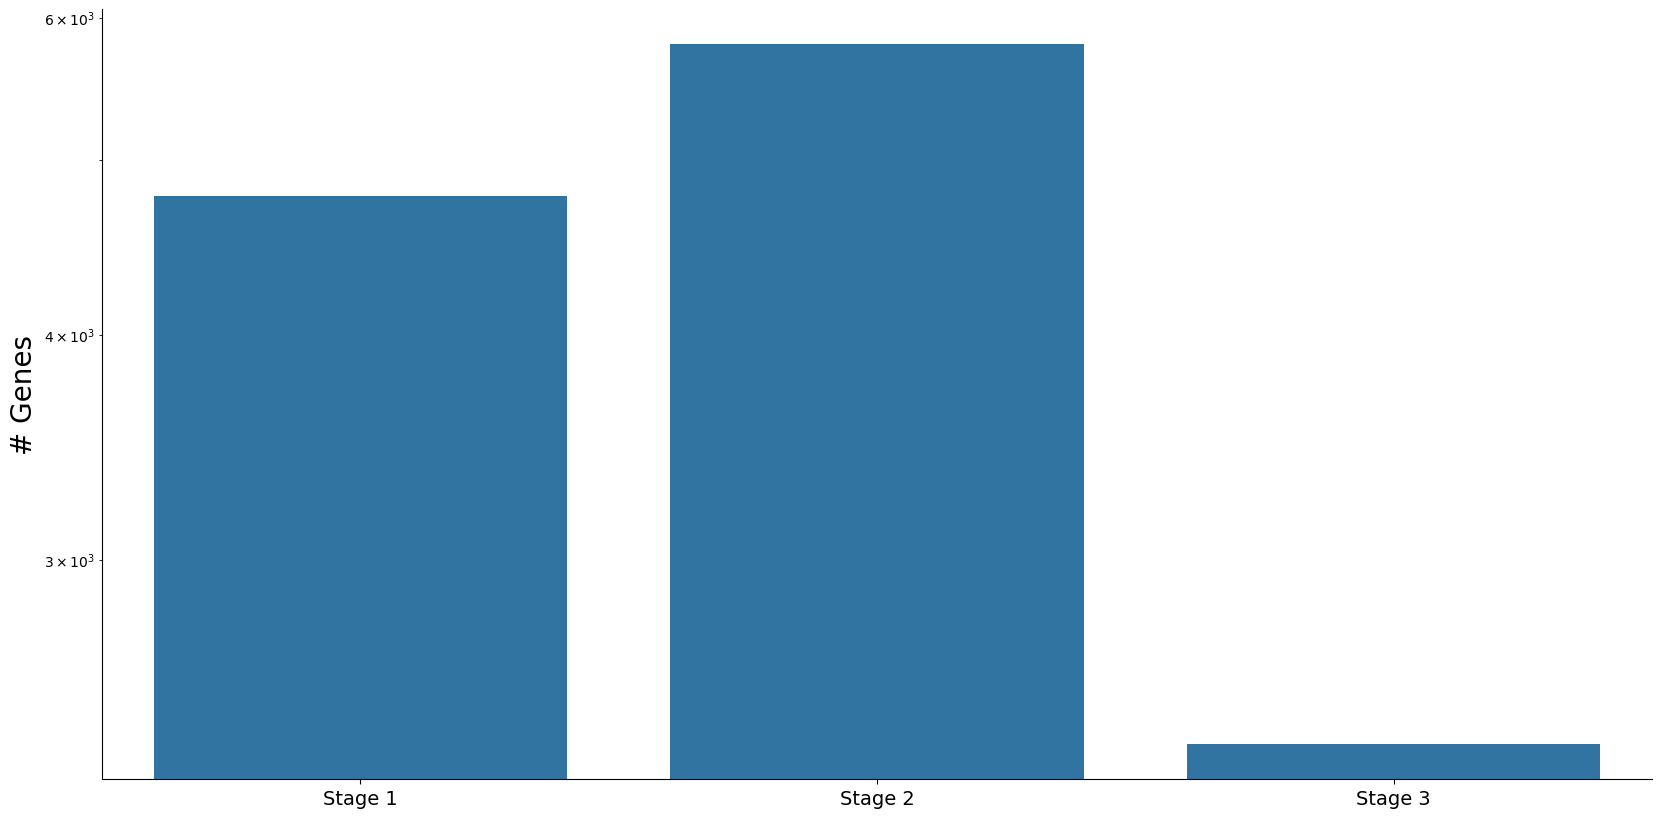

In [227]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(tot_s1_gene_list),len(tot_s2_gene_list),len(tot_s3_gene_list)]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/NumberGenesperStage_Female_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show

In [228]:

trj_s1_gene_list=[]
trj_s2_gene_list=[]
trj_s3_gene_list=[]



for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    trj_s1_gene_list.append(len(genelist_s1))
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s2:
                        genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    trj_s2_gene_list.append(len(genelist_s2))
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s3:
                        genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    trj_s3_gene_list.append(len(genelist_s3))


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/1314806455.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

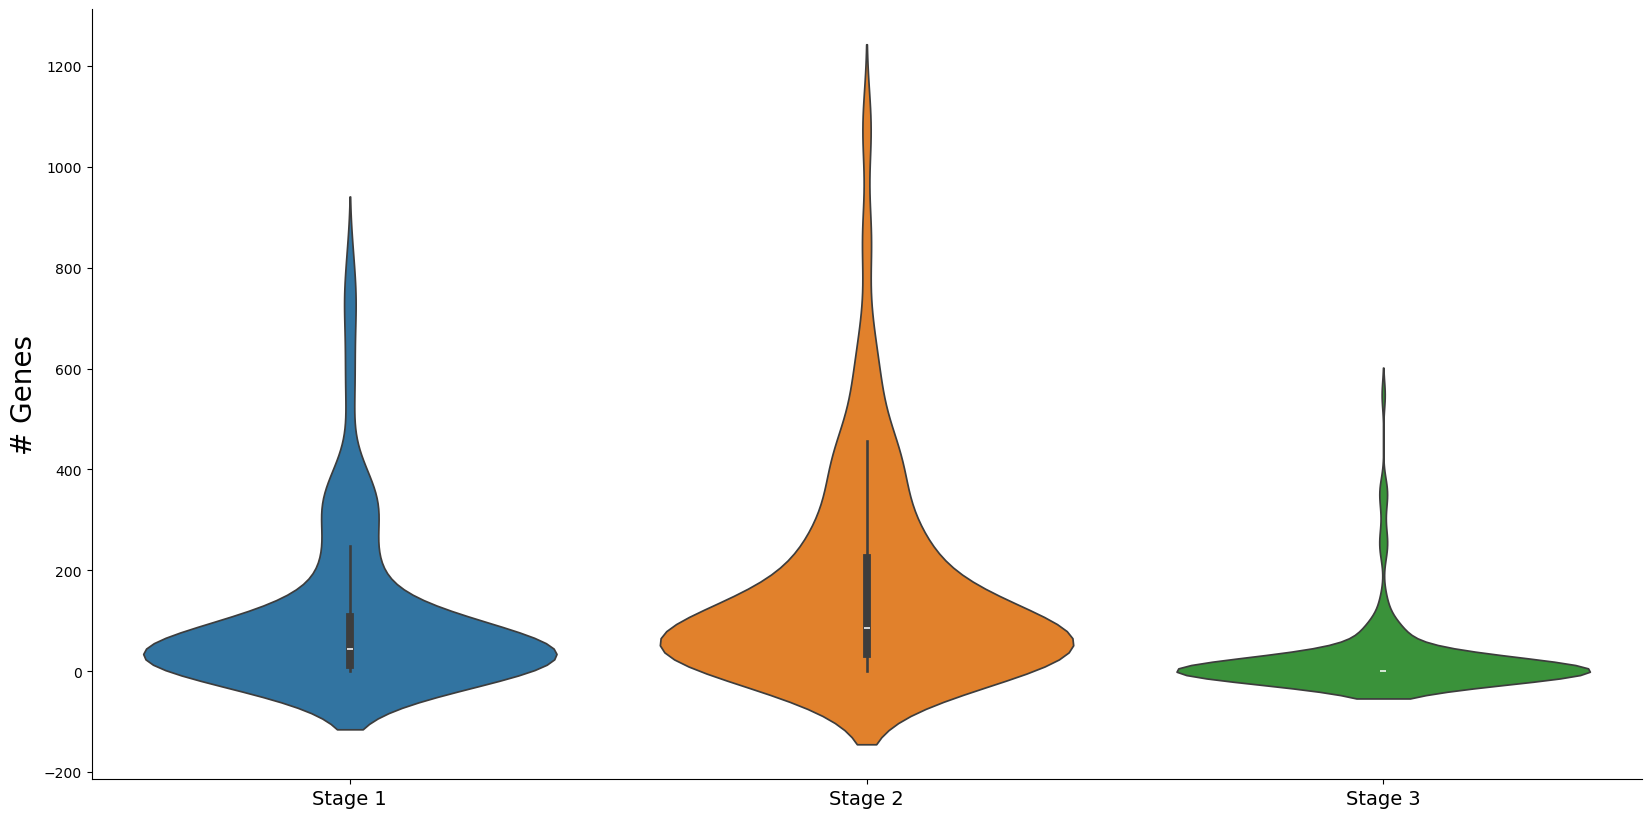

In [229]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_gene_list,trj_s2_gene_list,trj_s3_gene_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeGenesTrajperStage_Female_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/402669577.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


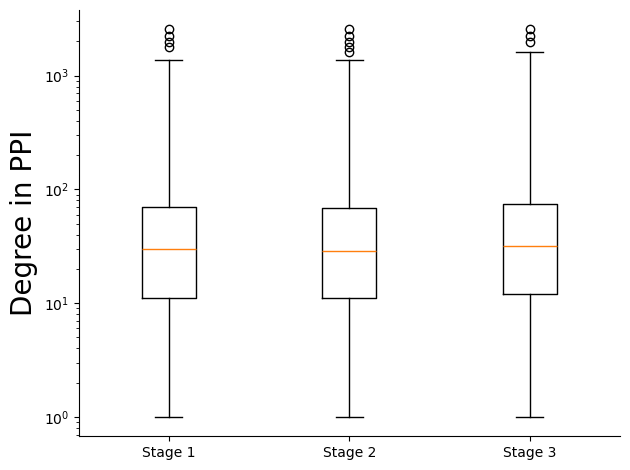

In [230]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

plt.ylabel('Degree in PPI',fontsize=20)
comparing_group_list= [
            [G_ppi.degree(gene) for gene in tot_s1_gene_list],
            [G_ppi.degree(gene) for gene in tot_s2_gene_list],
            [G_ppi.degree(gene) for gene in tot_s3_gene_list]
]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.yscale("log")
plt.tight_layout()
plt.show()




In [231]:
print(np.median([G_ppi.degree(gene) for gene in tot_s1_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s2_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s3_gene_list]))



30.0
29.0
32.0


In [232]:

#Let's make a dictionary that takes all the genes associated with the trajectories at each stage
#Here, we will count the number of trajectories each gene appear for each stage
#This is different than counting the number of diseases, because we are treating the trajectories as meta-diseases
#which means that if we have a trajectory with 5 diseases targeting the same gene, that gene will be counted just one

tot_gen_gene_dict={}
for i in range(1,4):
    tot_genelist = []
    for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        genelist = []
        try:
            for dis in stage_dict[i]:
                for gene in list(icd_genes_ppi_dict[dis]):
                    if gene not in genelist:
                        genelist.append(gene)
        except:
            pass
        tot_genelist.extend(genelist)
    tot_gen_gene_dict[i] = tot_genelist


tot_gen_gene_counter_dict={}
for gen,genelist in tot_gen_gene_dict.items():
    genelist_count=Counter(genelist).most_common()
    tot_gen_gene_counter_dict[gen]=genelist_count

In [233]:
tot_gen_gene_counter_dict[1][:10]


[('TNF', 59),
 ('NR3C1', 48),
 ('IL6', 47),
 ('HLA-DQB1', 41),
 ('HLA-DRB1', 41),
 ('HLA-DQA1', 39),
 ('MTHFR', 39),
 ('IL1B', 38),
 ('IL10', 36),
 ('APOE', 35)]

In [234]:
tot_gen_gene_counter_dict[2][:10]


[('TNF', 78),
 ('IL1B', 57),
 ('IL6', 55),
 ('HLA-DQB1', 53),
 ('HLA-DQA1', 50),
 ('PTGS2', 50),
 ('MTHFR', 50),
 ('NR3C1', 48),
 ('IL1RN', 48),
 ('TGFB1', 47)]

In [235]:
tot_gen_gene_counter_dict[3][:10]


[('TNF', 17),
 ('IL1RN', 13),
 ('IL10', 12),
 ('PTGS2', 12),
 ('IL6', 11),
 ('HLA-DQA1', 11),
 ('IFNG', 10),
 ('HLA-DQB1', 9),
 ('IL1B', 9),
 ('VEGFA', 9)]

In [236]:
for gen,genelist in tot_gen_gene_dict.items():
    print(gen,len(set(genelist)))

1 4775
2 5697
3 2369


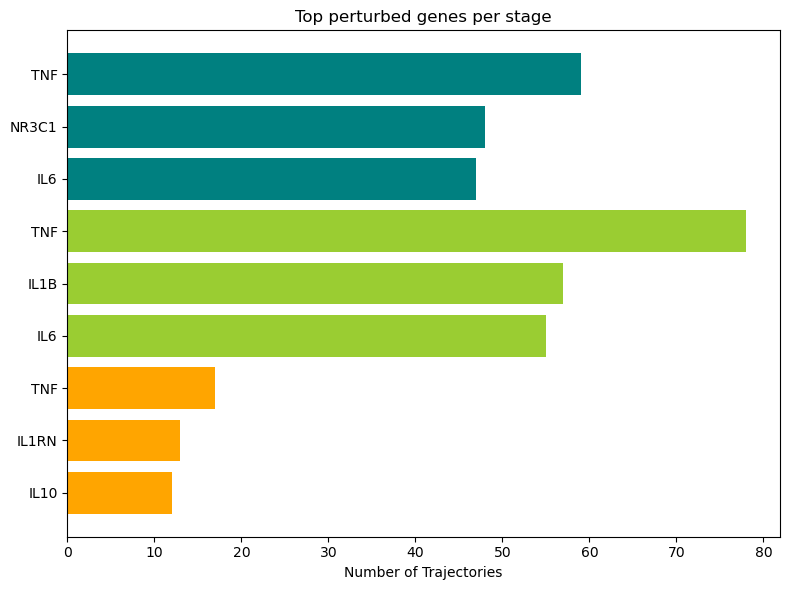

In [237]:

#Let's make it as a barplot
dis_list = ['TNF','NR3C1','IL6','TNF','IL1B','IL6','TNF','IL1RN','IL10']
frequency_list = [59,48,47,78,57,55,17,13,12]
color_list = ['teal', 'yellowgreen','orange']
# Assign colors cycling every three bars
bar_colors = [color_list[(i // 3) % len(color_list)] for i in range(len(dis_list))]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(dis_list))

ax.barh(y_pos, frequency_list, color=bar_colors, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dis_list)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top perturbed genes per stage')

plt.tight_layout()
plt.savefig('Figures/FemaleGeneFrequencyBarplot_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [71]:
#ENRICH

In [238]:

tot_gen_genes_counter_dict_df={}

for gen,genecount in tot_gen_gene_counter_dict.items():
    rank_df=pd.DataFrame(columns=('gene', 'rank'))
    gene_list=[]
    rank_genelist=[]
    for el in genecount:
        gene_list.append(el[0])
        rank_genelist.append(el[1])
    rank_df['gene']=gene_list
    rank_df['rank']=rank_genelist
    rank_df=rank_df.sort_values(by=['rank'],ascending=False)
    tot_gen_genes_counter_dict_df[gen]=rank_df

In [239]:

for gen,rank_df in tot_gen_genes_counter_dict_df.items():
        
    lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
                     processes=4,min_size=3,max_size=5000,outdir=None,   #we impose at least 5 enriched common genes
                     permutation_num=500) # reduce number to speed up testing
    # to save your figure, make sure that ``ofname`` is not None
    ax = dotplot(lib_pre_res.res2d,
                 column="FDR q-val",
                 title='Female KEGG at stage %s'%gen,
                 cmap=plt.cm.viridis,
                 size=6, # adjust dot size
                 figsize=(4,5), cutoff=0.25, ofname='Figures/Female KEGG at stage %s_official.pdf'%gen, show_ring=False)

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/821053471.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2026-03-01 19:27:54,115 [WARNING] Duplicated values found in preranked stats: 99.23% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/821053471.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2026-03-01 19:27:54,998 [WARNING] Duplicated values found in preranked stats: 99.18% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/821053471.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2026-03-01 19:27:56,163 [WA

In [240]:
#Let's calculate the z-score connectivity for the genes associated at each stage in each trajectory

tot_gen_connectivity_zscore_dict={}
for i in range(1,4):
    tot_zscore_list = []
    for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        genelist_s_i = []
        try:
            for dis in stage_dict[i]:
                genelist_s_i.extend(list(icd_genes_ppi_dict[dis]))
        except:
            pass
        geneset_s_i = set(genelist_s_i)
        geneset_s_i_cl = [i for i in geneset_s_i if str(i)!='nan']
        z_score_s_i = net_modularity(geneset_s_i_cl,G_ppi)
        if str(z_score_s_i)!='nan':
            tot_zscore_list.append(z_score_s_i)
        
    tot_gen_connectivity_zscore_dict[i] = tot_zscore_list

In [241]:

with open('output/tot_gen_connectivity_zscore_dict_female_v2026_official.pickle', 'wb') as handle:
    pk.dump(tot_gen_connectivity_zscore_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/1122450910.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


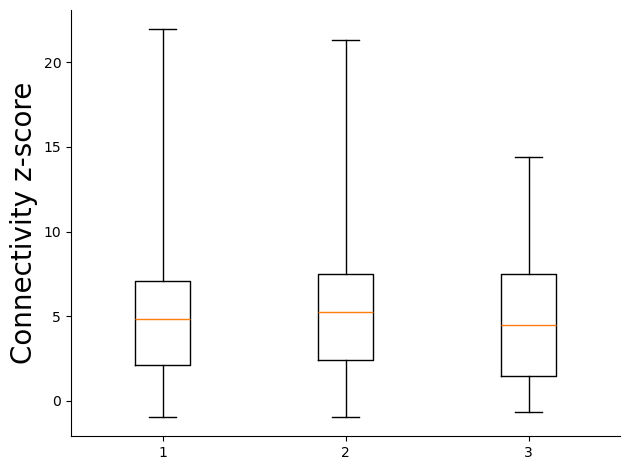

In [242]:


fig1, ax1 = plt.subplots()
labels=list([str(i) for i in tot_gen_connectivity_zscore_dict.keys()])
plt.ylabel('Connectivity z-score',fontsize=20)
comparing_group_list= list(tot_gen_connectivity_zscore_dict.values())
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

#plt.yscale("log")
plt.tight_layout()
plt.savefig('Figures/ConnectivityzscoreperStage_Female_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [243]:


t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[1],tot_gen_connectivity_zscore_dict[2])
print("T-test Stage 1 vs Stage 2, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[1],tot_gen_connectivity_zscore_dict[3])
print("T-test Stage 1 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(tot_gen_connectivity_zscore_dict[2],tot_gen_connectivity_zscore_dict[3])
print("T-test Stage 2 vs Stage 3, p-value is %s"%p_value)


T-test Stage 1 vs Stage 2, p-value is 0.4107805959606481
T-test Stage 1 vs Stage 3, p-value is 0.5104526573952566
T-test Stage 2 vs Stage 3, p-value is 0.263149727247275


In [249]:
hub_threshold = np.percentile(list(dict(nx.degree(G_ppi)).values()), 90)

trj_hub_dict = {}
for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    stage_hub_dict = {}
    for stage, dislist in stage_dict.items():
        tot_genelist = []
        for dis in dislist:
            try:
                genelist = list(icd_genes_ppi_dict[dis])
                tot_genelist.extend(genelist)
            except:
                pass
        data = [G_ppi.degree(gene) for gene in tot_genelist]
        hub_count = sum(1 for x in data if x >= hub_threshold)
        # Calculate Proportion
        p = hub_count / len(data) if data else 0
        stage_hub_dict[stage] = p * 100
    trj_hub_dict[trj] = stage_hub_dict



In [250]:
#Let's divide the trajectories in those which stage-specific genes degree tend to inrease and those that decreases
#We will just compare the last and the first stage point

ascending_trj = []
descending_trj = []
for trj,hub in trj_hub_dict.items():
    gen_max_degree_idx = np.argmax(list(hub.values())) 
    if gen_max_degree_idx !=0:
        ascending_trj.append(trj)
    else:
        descending_trj.append(trj)

print(len(ascending_trj))
print(len(descending_trj))

74
87


In [251]:

trj_list = []
status_list = []
max_stage_indices = []
max_stage_values = []
dis_max_degree_list = []

for trj, gen_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    hub_proportions_dict = trj_hub_dict[trj]
    
    # Use np.argmax to find the index of the maximum value
    gen_max_degree_idx = np.argmax(list(hub_proportions_dict.values())) 
    max_val = list(hub_proportions_dict.values())[gen_max_degree_idx]
    
    max_stage_indices.append(gen_max_degree_idx+1)
    max_stage_values.append(max_val)
    trj_list.append(trj)
    
    # 2. Status assignment
    if trj in ascending_trj:
        status_list.append("Ascending")
    elif trj in descending_trj:
        status_list.append("Descending")
    else:
        pass

    # Get the list of diseases at the stage where the trajectory peaked
    # We use .get() or check existence to be safe
    dis_hub_dict = {}
    diseases_at_stage = gen_dict.get(gen_max_degree_idx+1, [])
    
    for dis in diseases_at_stage:
        # Get genes, ensuring they exist in the PPI graph to avoid errors
        genes = allsources_icd_gene_dict_unified.get(dis, [])
        valid_genes = [g for g in genes if g in G_ppi.nodes()]
        data = [G_ppi.degree(gene) for gene in valid_genes]
        hub_count = sum(1 for x in data if x >= hub_threshold)
        # Calculate Proportion
        p = hub_count / len(data) if data else 0
        dis_hub_dict[dis] = p+100

    # 4. Fix: Find the disease with the maximum calculated degree
    if dis_hub_dict:
        # Valid python to find key with max value
        best_dis = max(dis_hub_dict, key=dis_hub_dict.get)
        dis_max_degree_list.append(best_dis)
    else:
        dis_max_degree_list.append(None)

# 5. Build DataFrame (renaming columns to avoid overwriting)
female_trj_evolving_status_df = pd.DataFrame()
female_trj_evolving_status_df["trj"] = trj_list
female_trj_evolving_status_df["status"] = status_list
female_trj_evolving_status_df["max_stage_idx"] = max_stage_indices
female_trj_evolving_status_df["max_stage_val"] = max_stage_values
female_trj_evolving_status_df["disease_with_max_hub_percentage"] = dis_max_degree_list
female_trj_evolving_status_df.head()

,trj,status,max_stage_idx,max_stage_val,disease_with_max_hub_percentage
0,2,Descending,1,33.333333,A08
1,3,Ascending,3,16.197183,G51
2,5,Descending,1,18.279570,B00
3,9,Descending,1,50.000000,J20
4,13,Descending,1,15.254237,J34


In [252]:
female_trj_evolving_status_df.to_csv("output/female_trj_evolving_status_df_official.csv",index=False)

In [254]:
for trj in descending_trj:
    if len(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])>2:
        print(trj,female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])

35 {1: ['B00'], 2: ['J31', 'J35'], 3: ['K07']}
152 {1: ['M06'], 2: ['M05', 'M06'], 3: ['M13']}
159 {1: ['B16'], 2: ['B18'], 3: ['B18', 'K73']}
160 {1: ['G83', 'H10'], 2: ['M54', 'M76'], 3: ['J04', 'J31', 'M76']}
232 {1: ['M65'], 2: ['M24', 'M65', 'M67'], 3: ['M24', 'M65', 'M67', 'M72']}
236 {1: ['N04'], 2: ['A69', 'B99', 'E07', 'I10', 'I31', 'I46', 'I71', 'J03', 'J30', 'J41', 'J42', 'J81', 'J84', 'K55', 'K75', 'L50', 'L98', 'M86', 'N30'], 3: ['E26', 'N03']}
239 {1: ['E21'], 2: ['E21', 'N18', 'N19'], 3: ['E21', 'N17', 'N19']}
265 {1: ['M47'], 2: ['D34', 'E04', 'E21', 'E55', 'E83', 'J38'], 3: ['E07']}
274 {1: ['E16'], 2: ['E10'], 3: ['E10', 'E13', 'E16', 'G63']}
284 {1: ['G93'], 2: ['G40', 'G93'], 3: ['G41']}
315 {1: ['M16'], 2: ['E66', 'I89', 'L30', 'M16', 'M87'], 3: ['E65', 'I89', 'K45', 'N62']}
374 {1: ['H10'], 2: ['F13', 'F33', 'F41', 'F43', 'F45'], 3: ['F13', 'F33', 'F41', 'F43', 'F45', 'K59']}
375 {1: ['K20', 'K51'], 2: ['A49', 'K20', 'K29', 'K51'], 3: ['J37', 'K51', 'N89']}
407 {1

In [255]:
for trj in ascending_trj:
    if len(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])>2:
        print(trj,female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict[trj])

3 {1: ['A38', 'G47', 'H04'], 2: ['J35', 'J36'], 3: ['B07', 'B34', 'G51', 'H53', 'H72', 'H74', 'J15']}
15 {1: ['E66', 'G47'], 2: ['H90'], 3: ['F81', 'H66', 'H90', 'J00', 'N83']}
71 {1: ['E03'], 2: ['D50', 'D64', 'E03'], 3: ['E03', 'E06']}
147 {1: ['K76'], 2: ['K76', 'N28'], 3: ['B37']}
156 {1: ['E21', 'N18', 'N19'], 2: ['E21', 'I15', 'N18', 'N19'], 3: ['I15', 'N17', 'N19']}
179 {1: ['E13'], 2: ['E11', 'E13', 'G63', 'L03'], 3: ['G63', 'M86', 'N08']}
191 {1: ['M51'], 2: ['M43', 'M48', 'M51'], 3: ['G57', 'M51', 'M96']}
193 {1: ['M51'], 2: ['M43', 'M48', 'M51'], 3: ['G54', 'G57', 'M40', 'M51', 'M54', 'M96']}
229 {1: ['M20', 'M77'], 2: ['M20', 'M21'], 3: ['G57', 'M20']}
243 {1: ['A04'], 2: ['K80', 'K81', 'K82'], 3: ['D72']}
244 {1: ['A08', 'J31', 'M46'], 2: ['A49', 'K29', 'K55'], 3: ['D22', 'K20', 'L28', 'N60']}
275 {1: ['I99'], 2: ['A04', 'E78', 'E83', 'G46', 'G51', 'M10', 'M85'], 3: ['E83', 'F50', 'N04', 'N05', 'N62', 'N87']}
279 {1: ['F06', 'F48'], 2: ['F32', 'F40', 'F44', 'F48'], 3: ['D1

In [256]:
#Let's see what happens if we remove the genes that were already perturbed at the previous time points of each trajectory

tot_s1_gene_list=[]
tot_s2_gene_list=[]
tot_s3_gene_list=[]

trj_s1_gene_list=[]
trj_s2_gene_list=[]
trj_s3_gene_list=[]


for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    tot_s1_gene_list.extend(genelist_s1)
    trj_s1_gene_list.append(len(genelist_s1))
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1: 
                        if gene not in genelist_s2: 
                            genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    tot_s2_gene_list.extend(genelist_s2)
    trj_s2_gene_list.append(len(genelist_s2))
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2:
                        if gene not in genelist_s3:
                            genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    tot_s3_gene_list.extend(genelist_s3)
    trj_s3_gene_list.append(len(genelist_s3))



/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/3974314704.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

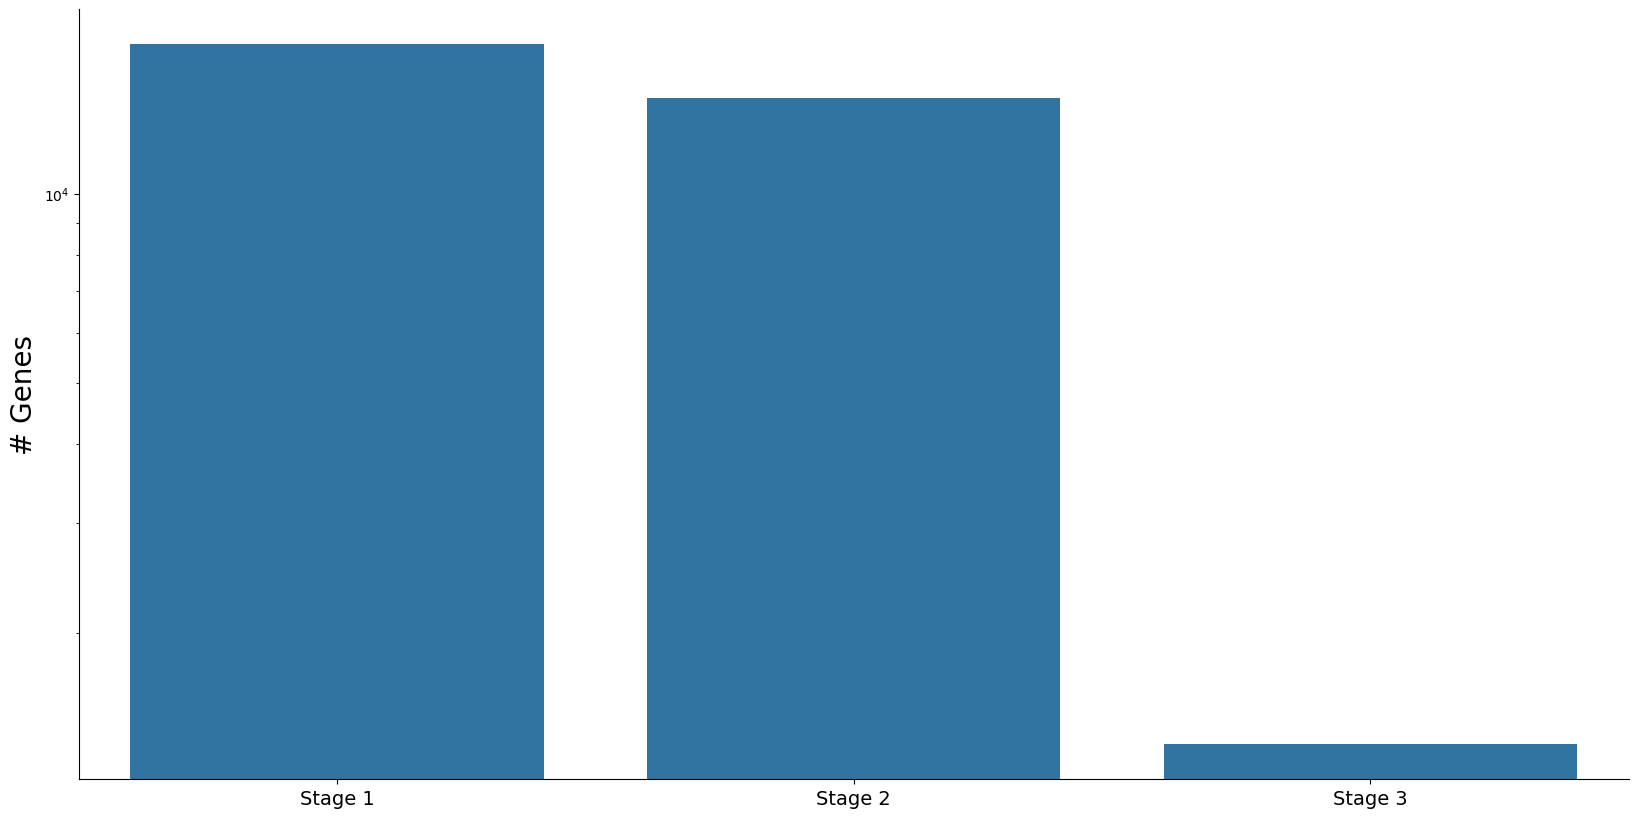

In [257]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(tot_s1_gene_list),len(tot_s2_gene_list),len(tot_s3_gene_list)]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()
plt.savefig('Figures/NumberGenesperStage_Female_RemovedPriorGenes_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")

# Show the plot
plt.show

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/3645835067.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

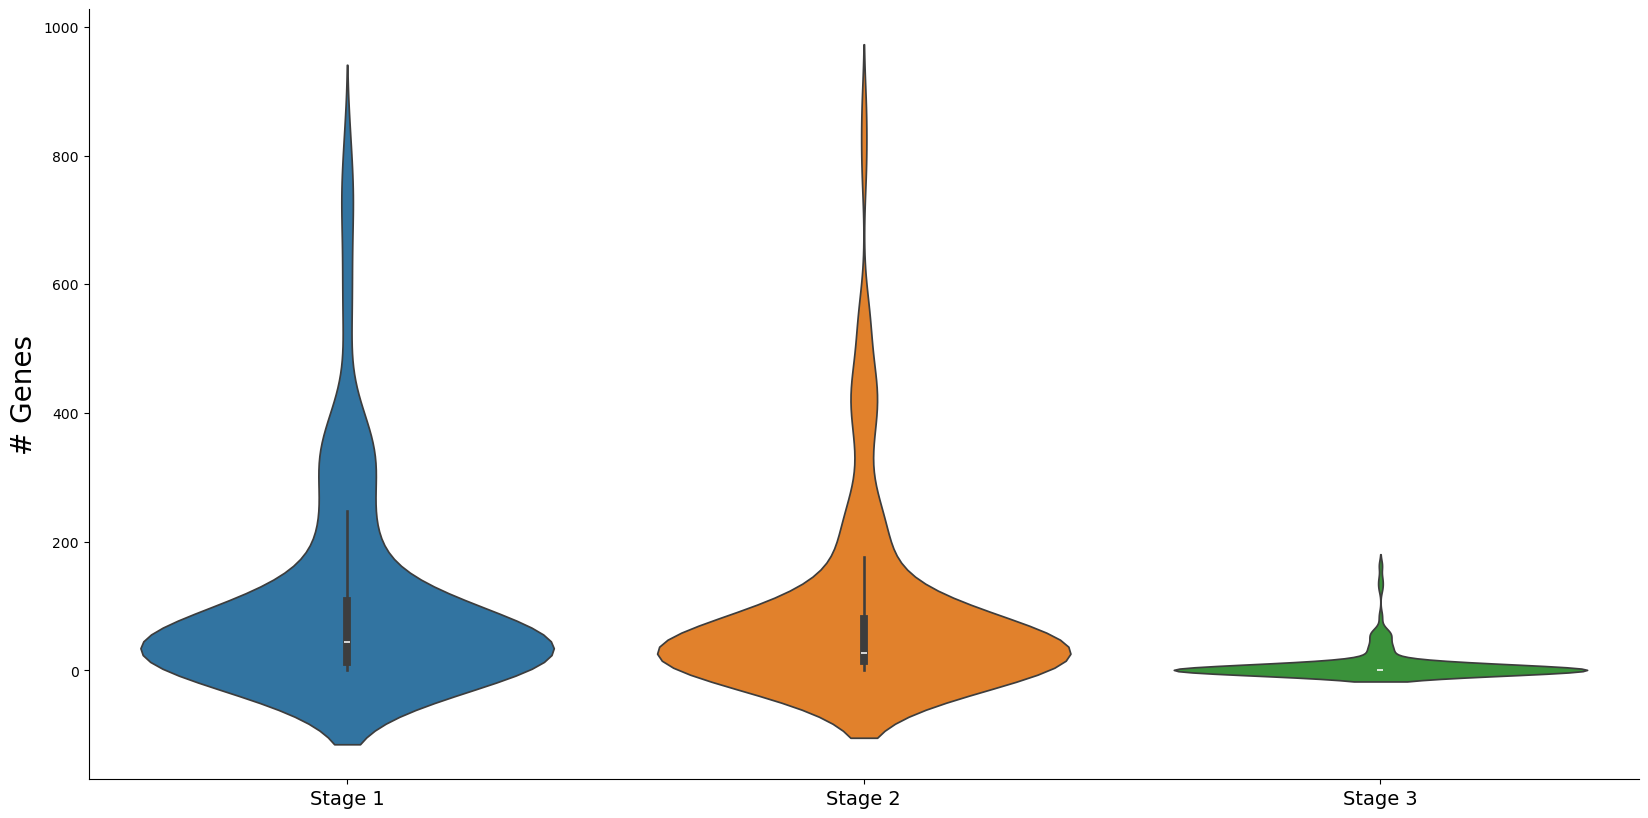

In [258]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Genes', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_gene_list,trj_s2_gene_list,trj_s3_gene_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeGenesTrajperStage_Female_RemovePriorGenes_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/823234882.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


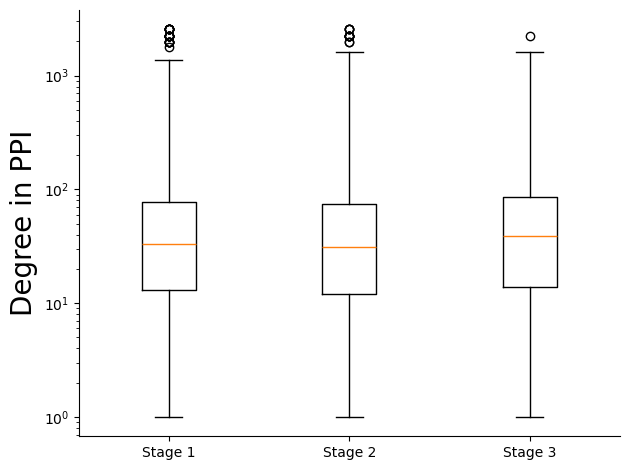

In [259]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

plt.ylabel('Degree in PPI',fontsize=20)
comparing_group_list= [
            [G_ppi.degree(gene) for gene in tot_s1_gene_list],
            [G_ppi.degree(gene) for gene in tot_s2_gene_list],
            [G_ppi.degree(gene) for gene in tot_s3_gene_list]
]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.yscale("log")
plt.tight_layout()

plt.show()



In [260]:
print(np.median([G_ppi.degree(gene) for gene in tot_s1_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s2_gene_list]))
print(np.median([G_ppi.degree(gene) for gene in tot_s3_gene_list]))


33.0
31.0
39.0


In [261]:
#Let's make a dictionary that takes all the genes associated with the diseases at each stage

tot_gen_gene_dict_removed_genes={}


tot_s1_gene_list=[]
tot_s2_gene_list=[]
tot_s3_gene_list=[]


for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    tot_s1_gene_list.extend(genelist_s1)
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1: 
                        if gene not in genelist_s2: 
                            genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    tot_s2_gene_list.extend(genelist_s2)
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2:
                        if gene not in genelist_s3:
                            genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    tot_s3_gene_list.extend(genelist_s3)

    
tot_gen_gene_dict_removed_genes[1] = tot_s1_gene_list
tot_gen_gene_dict_removed_genes[2] = tot_s2_gene_list
tot_gen_gene_dict_removed_genes[3] = tot_s3_gene_list



tot_gen_gene_dict_removed_genes_counter={}
for gen,genelist in tot_gen_gene_dict_removed_genes.items():
    genelist_count=Counter(genelist).most_common()
    tot_gen_gene_dict_removed_genes_counter[gen]=genelist_count

In [262]:
tot_gen_gene_dict_removed_genes_counter[1][:10]


[('TNF', 59),
 ('NR3C1', 48),
 ('IL6', 47),
 ('HLA-DQB1', 41),
 ('HLA-DRB1', 41),
 ('HLA-DQA1', 39),
 ('MTHFR', 39),
 ('IL1B', 38),
 ('IL10', 36),
 ('APOE', 35)]

In [263]:
tot_gen_gene_dict_removed_genes_counter[2][:10]


[('IL1RN', 30),
 ('TNF', 30),
 ('NOS2', 27),
 ('PTGS2', 27),
 ('FTO', 26),
 ('IL1B', 26),
 ('ABCB1', 25),
 ('CAT', 24),
 ('CCL2', 23),
 ('HMOX1', 23)]

In [264]:
tot_gen_gene_dict_removed_genes_counter[3][:10]


[('IL1RN', 8),
 ('TRPV1', 6),
 ('SOD1', 6),
 ('PTGS2', 6),
 ('SCN8A', 5),
 ('SCN2A', 5),
 ('IL10', 5),
 ('FAAH', 5),
 ('IFNG', 5),
 ('EGFR', 4)]

In [265]:
for gen,genelist in tot_gen_gene_dict_removed_genes_counter.items():
    print(gen,len(set(genelist)))

1 4775
2 4428
3 1016


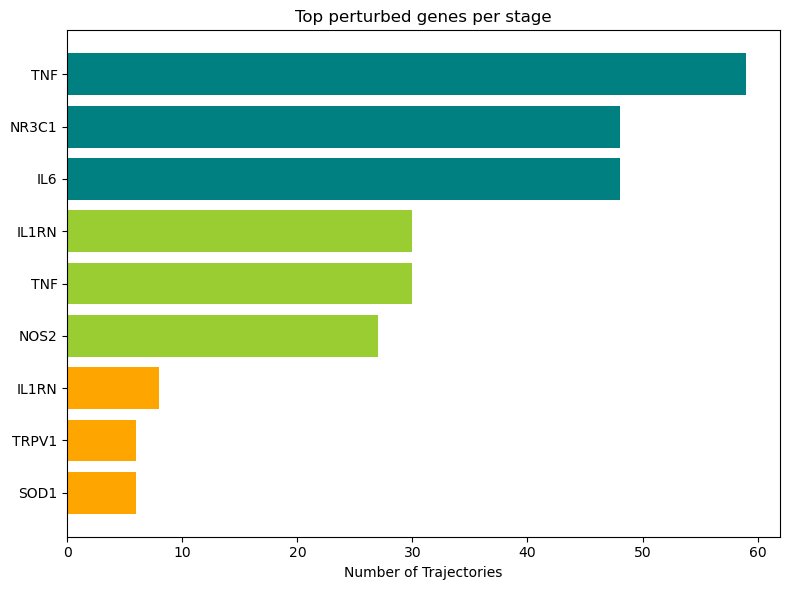

In [266]:

#Let's make it as a barplot
dis_list = ['TNF','NR3C1','IL6','IL1RN','TNF','NOS2','IL1RN','TRPV1','SOD1']
frequency_list = [59,48,48,30,30,27,8,6,6]
color_list = ['teal', 'yellowgreen','orange']
# Assign colors cycling every three bars
bar_colors = [color_list[(i // 3) % len(color_list)] for i in range(len(dis_list))]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(dis_list))

ax.barh(y_pos, frequency_list, color=bar_colors, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(dis_list)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top perturbed genes per stage')

plt.tight_layout()
plt.savefig('Figures/FemaleGeneFrequencyBarplot_RemovePriorGenes_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

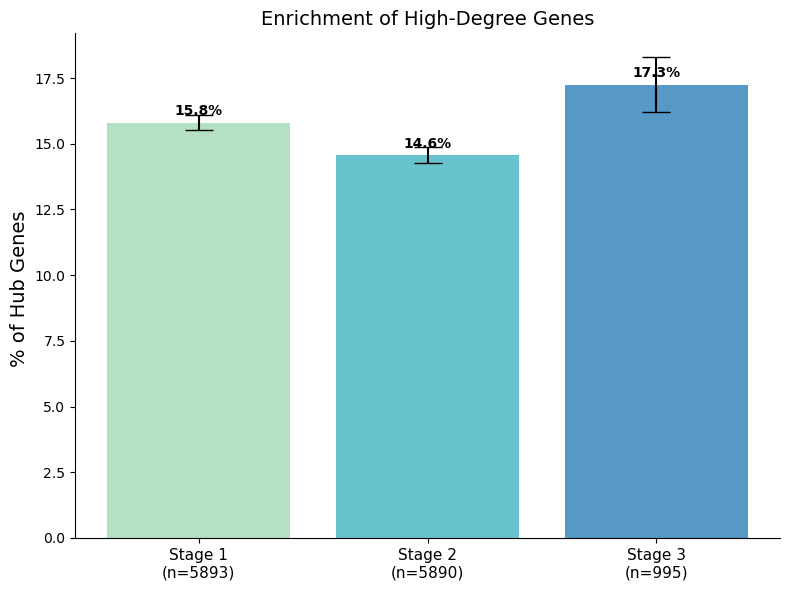

In [267]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

# 1. Gather your data
data_lists = [
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[1]], # Stage 1
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[2]], # Stage 2
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[3]] # Stage 3
]
labels = ['Stage 1\n(n=5893)', 'Stage 2\n(n=5890)', 'Stage 3\n(n=995)']

# 2. Define "High Degree" (The Tail)
# In scale-free networks, the median is always low. The difference is in the top 10%.
# Let's define "Hubs" as the top 10% of the combined data, or a fixed number (e.g., > 20 connections)
all_degrees = np.concatenate(data_lists)
hub_threshold = np.percentile(list(dict(nx.degree(G_ppi)).values()), 90) # Top 10% cutoff
# Alternatively, set a hard threshold: hub_threshold = 50

proportions = []
errors = []

for data in data_lists:
    n = len(data)
    # Count how many genes are "Hubs"
    hub_count = sum(1 for x in data if x >= hub_threshold)
    
    # Calculate Proportion
    p = hub_count / n
    proportions.append(p * 100) # Convert to %
    
    # Calculate Standard Error for Proportion: sqrt( p*(1-p) / n )
    # This specifically accounts for the small N of Stage 4!
    sem = sqrt((p * (1 - p)) / n)
    errors.append(sem * 100) # Convert to %

# 3. Plot
fig, ax = plt.subplots(figsize=(8, 6))

x_pos = np.arange(len(labels))
bars = ax.bar(x_pos, proportions, yerr=errors, align='center', 
              alpha=0.8, ecolor='black', capsize=10, 
              color=['#a1dab4', '#41b6c4', '#2c7fb8'])

ax.set_ylabel(f'% of Hub Genes ', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11)
ax.set_title(f'Enrichment of High-Degree Genes', fontsize=14)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()


plt.savefig('Figures/Hub_Percentage_Female_RemovedGenes_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [268]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

# 1. Setup Data (Recalculating the counts from your lists)
# ---------------------------------------------------------
data_lists = [
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[1]], # Stage 1
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[2]], # Stage 2
    [G_ppi.degree(gene) for gene in tot_gen_gene_dict_removed_genes[3]] # Stage 3
]
stage_names = ['Stage 1', 'Stage 2', 'Stage 3']
hub_threshold = np.percentile(list(dict(nx.degree(G_ppi)).values()), 90)

# Create a summary table: [Successes (Hubs), Total N]
successes = []
nobs = [] # Number of observations

for data in data_lists:
    n = len(data)
    count_hubs = sum(1 for x in data if x >= hub_threshold)
    successes.append(count_hubs)
    nobs.append(n)

print(f"Threshold for 'High Degree': >= {hub_threshold}")
print(f"Counts of Hubs: {successes}")
print(f"Total Genes (N): {nobs}")
print("-" * 30)

# 2. Global Test: Chi-Squared
# ---------------------------------------------------------
# We construct a contingency table:
# [[Non-Hubs_S1, Hubs_S1],
#  [Non-Hubs_S2, Hubs_S2], ...]
contingency_table = []
for i in range(3):
    contingency_table.append([nobs[i] - successes[i], successes[i]])

chi2, p_global, dof, expected = chi2_contingency(contingency_table)

print(f"Global Chi-Squared Test P-value: {p_global:.2e}")
if p_global < 0.05:
    print(">> Result: Significant difference found among stages.")
else:
    print(">> Result: No significant difference found.")

print("-" * 30)

# 3. Post-Hoc Test: Pairwise Z-Test (Stage X vs Stage Y)
# ---------------------------------------------------------
# Only meaningful if Global P < 0.05
if p_global < 0.05:
    print("Pairwise Comparisons (Stage vs Stage):")
    
    # Compare Stage 1 vs Stage 4 (or any other pair)
    # You can loop through all combinations if needed
    pairs_to_test = [(0, 1), (0, 2), (1, 2)] # Indices of stages to compare
    
    for i, j in pairs_to_test:
        count = np.array([successes[i], successes[j]])
        nobs_pair = np.array([nobs[i], nobs[j]])
        
        stat, p_val = proportions_ztest(count, nobs_pair)
        
        # Bonferroni correction: Multiply p-value by number of tests done? 
        # Or just keep it raw for now. Usually, p < 0.05/Number_of_tests is safe.
        
        sig = "*" if p_val < 0.05 else "ns"
        print(f"{stage_names[i]} vs {stage_names[j]}: p={p_val:.2e} ({sig})")

Threshold for 'High Degree': >= 118.5
Counts of Hubs: [2733, 2070, 230]
Total Genes (N): [17293, 14211, 1333]
------------------------------
Global Chi-Squared Test P-value: 1.37e-03
>> Result: Significant difference found among stages.
------------------------------
Pairwise Comparisons (Stage vs Stage):
Stage 1 vs Stage 2: p=2.35e-03 (*)
Stage 1 vs Stage 3: p=1.63e-01 (ns)
Stage 2 vs Stage 3: p=8.22e-03 (*)


In [164]:
#ENRICH

In [269]:

tot_gen_gene_dict_removed_genes_counter_df={}

for gen,genecount in tot_gen_gene_dict_removed_genes_counter.items():
    rank_df=pd.DataFrame(columns=('gene', 'rank'))
    gene_list=[]
    rank_genelist=[]
    for el in genecount:
        gene_list.append(el[0])
        rank_genelist.append(el[1])
    rank_df['gene']=gene_list
    rank_df['rank']=rank_genelist
    rank_df=rank_df.sort_values(by=['rank'],ascending=False)
    tot_gen_gene_dict_removed_genes_counter_df[gen]=rank_df

In [270]:

for gen,rank_df in tot_gen_gene_dict_removed_genes_counter_df.items():
        
    lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
                     processes=4,min_size=3,max_size=5000,outdir=None,   #we impose at least 5 enriched common genes
                     permutation_num=500) # reduce number to speed up testing
    # to save your figure, make sure that ``ofname`` is not None
    ax = dotplot(lib_pre_res.res2d,
                 column="FDR q-val",
                 title='Female KEGG at stage %s'%gen,
                 cmap=plt.cm.viridis,
                 size=6, # adjust dot size
                 figsize=(4,5), cutoff=0.25, ofname='Figures/Female KEGG Removed Prior Genes at stage %s_official.pdf'%gen, show_ring=False)

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/1496787159.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2026-03-01 19:46:28,760 [WARNING] Duplicated values found in preranked stats: 99.23% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/1496787159.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2026-03-01 19:46:29,746 [WARNING] Duplicated values found in preranked stats: 99.37% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/1496787159.py:3: DeprecationWarning: processes is deprecated; use threads
  lib_pre_res = gp.prerank(rnk=rank_df, gene_sets='KEGG_2021_Human',
2026-03-01 19:46:30,604 

In [271]:

female_trj_deg_dict = {}
for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    genelist_s1 = []
    genelist_s2 = []
    genelist_s3 = []
    try:
        for dis in stage_dict[1]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1:
                        genelist_s1.append(gene)
            except:
                pass
    except:
        pass
    try:
        for dis in stage_dict[2]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1: 
                        if gene not in genelist_s2: 
                            genelist_s2.append(gene)
            except:
                pass
    except:
        pass
    try:
        for dis in stage_dict[3]:
            try:
                for gene in icd_genes_ppi_dict[dis]:
                    if gene not in genelist_s1 and gene not in genelist_s2:
                        if gene not in genelist_s3:
                            genelist_s3.append(gene)
            except:
                pass
    except:
        pass
    genelist_s1_deglist = [G_ppi.degree(gene) for gene in genelist_s1]
    genelist_s2_deglist = [G_ppi.degree(gene) for gene in genelist_s2]
    genelist_s3_deglist = [G_ppi.degree(gene) for gene in genelist_s3]
    female_trj_deg_dict[trj] = [np.median(genelist_s1_deglist),np.median(genelist_s2_deglist),np.median(genelist_s3_deglist)]





/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [272]:
female_stage_avg_deg_stage_dict = {}
for i in range(3):
    deglist = []
    for trj,avgdeglist in female_trj_deg_dict.items():
        if str(avgdeglist[i])!='nan':
            deglist.append(avgdeglist[i])
    female_stage_avg_deg_stage_dict[i+1] = deglist


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/1417298351.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


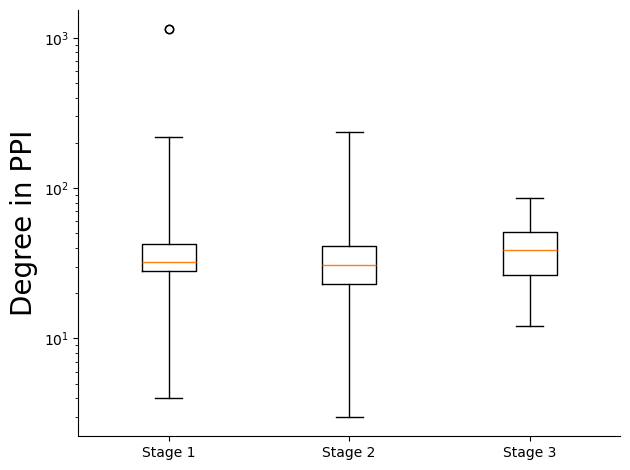

In [273]:
fig1, ax1 = plt.subplots()

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

plt.ylabel('Degree in PPI',fontsize=20)
comparing_group_list= list(female_stage_avg_deg_stage_dict.values())
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.yscale("log")
plt.tight_layout()
plt.savefig('Figures/MedianDegreeperTrjperStage_Female_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()


In [274]:


t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[1],stage_avg_deg_stage_dict[2])
print("T-test Stage 1 vs Stage 2, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[1],stage_avg_deg_stage_dict[3])
print("T-test Stage 1 vs Stage 3, p-value is %s"%p_value)

t_value,p_value=stats.ttest_ind(stage_avg_deg_stage_dict[2],stage_avg_deg_stage_dict[3])
print("T-test Stage 2 vs Stage 3, p-value is %s"%p_value)


T-test Stage 1 vs Stage 2, p-value is 0.11066816690265614
T-test Stage 1 vs Stage 3, p-value is 0.7273320071808735
T-test Stage 2 vs Stage 3, p-value is 0.3895609415529815


In [177]:
#Here, we remove the diseases that have been diagnosed already the previous time-point

In [276]:
female_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict = {}

for trj, disdict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    dis_dict_gen = {}
    back_dis_state = list(disdict[1])  # Ensure this is a new list to avoid modifying the original

    for i in range(1, len(disdict) + 1):  # Start from the second key
        if i==1:
            dis_dict_gen[i] = disdict[1]
        else:
            i_dis = []
            for dis in disdict[i]:
                if dis not in back_dis_state:
                    i_dis.append(dis)
                    back_dis_state.append(dis)  # Add the new disease to the tracked state
            if i_dis:  # Only include non-empty lists
                dis_dict_gen[i] = i_dis

    if len(dis_dict_gen) > 1:  # Ensure there is more than one state to include in the result
        female_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict[trj] = dis_dict_gen

print(len(female_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict))

161


In [277]:
#Let's see how many diseases are present at each stage for any trajectory:

tot_s1_dis_list=[]
tot_s2_dis_list=[]
tot_s3_dis_list=[]


trj_s1_dis_list=[]
trj_s2_dis_list=[]
trj_s3_dis_list=[]

for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict.items():
    try:
        tot_s1_dis_list.extend(stage_dict[1])
    except:
        pass
    try:
        tot_s2_dis_list.extend(stage_dict[2])
    except:
        pass
    try:
        tot_s3_dis_list.extend(stage_dict[3])
    except:
        pass


for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_no_repeateddis_dict.items():
    try:
        trj_s1_dis_list.append(len(stage_dict[1]))
    except:
        pass
    try:
        trj_s2_dis_list.append(len(stage_dict[2]))
    except:
        pass
    try:
        trj_s3_dis_list.append(len(stage_dict[3]))
    except:
        pass

    

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/827715883.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

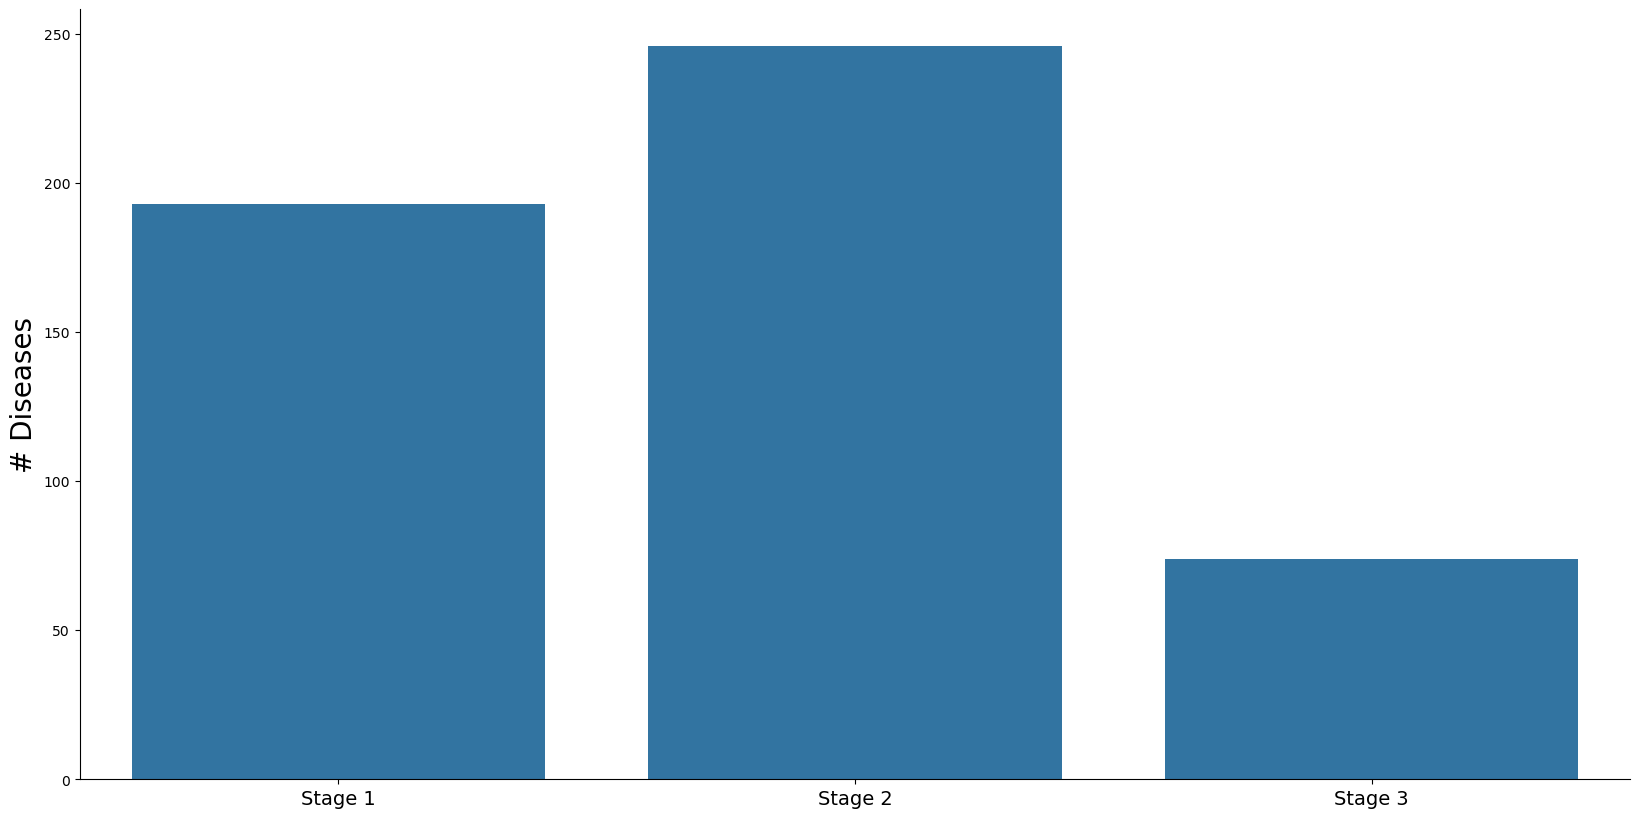

In [278]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [len(set(tot_s1_dis_list)),len(set(tot_s2_dis_list)),len(set(tot_s3_dis_list))]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.barplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()
plt.savefig('Figures/NumberDiseasesperStage_Female_RemovedPriorDiseases_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")

# Show the plot
plt.show

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_50734/69083140.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, fontsize=14)


<function matplotlib.pyplot.show(close=None, block=None)>

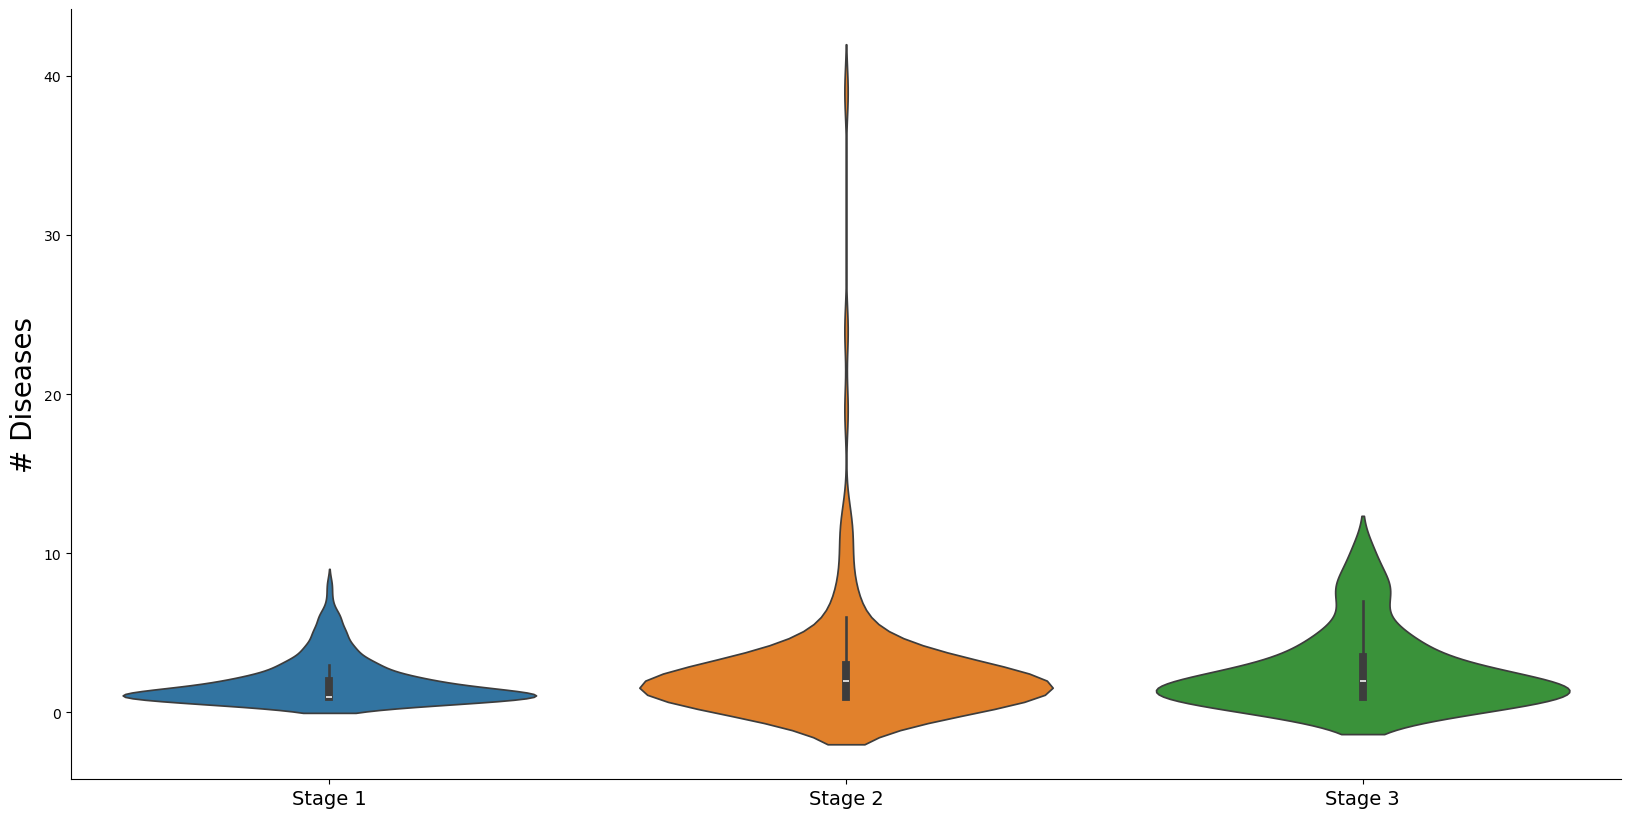

In [279]:
# Create the figure and axis with a larger size for better readability
fig1, ax1 = plt.subplots(figsize=(20, 10))

# Define custom labels for the plot
labels=['Stage 1',
        'Stage 2',
        'Stage 3']

# Set the y-axis to log scale
#plt.yscale('log')

# Set the y-axis label
plt.ylabel('# Diseases', fontsize=20)

# Create a list of data to plot, from original variable names
comparing_group_list = [trj_s1_dis_list,trj_s2_dis_list,trj_s3_dis_list]

# Creating a seaborn violin plot. In contrast to a box plot, a violin plot shows the full distribution of the data.
sns.violinplot(data=comparing_group_list)

# Set the x-axis labels with a larger font size for better readability
ax1.set_xticklabels(labels, fontsize=14)

# Disable the top and right axis spines, which are not needed
sns.despine()

plt.savefig('Figures/SizeDiseaseTrajperStage_Female_RemovedPriorDiseases_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
# Show the plot
plt.show



In [127]:
#Let's import the trajectory dataset
female_trj_evolving_status_df = pd.read_csv("output/female_trj_evolving_status_df_official.csv")

In [128]:
#Let's collect the hub genes of the disease with the highest hub percentage for ascending and discending trajectories
hub_threshold = np.percentile(list(dict(nx.degree(G_ppi)).values()), 90)
ascending_max_hub_dis_list = list(female_trj_evolving_status_df[female_trj_evolving_status_df['status']=="Ascending"]["disease_with_max_hub_percentage"].unique())
descending_max_hub_dis_list = list(female_trj_evolving_status_df[female_trj_evolving_status_df['status']=="Descending"]["disease_with_max_hub_percentage"].unique())

ascending_max_hub_gene_list = []
descending_max_hub_gene_list = []

for dis in ascending_max_hub_dis_list:
    genelist = allsources_icd_gene_dict_unified[dis]
    for g in genelist:
          if G_ppi.degree(g)>hub_threshold:
                ascending_max_hub_gene_list.append(g)

for dis in descending_max_hub_dis_list:
    genelist = allsources_icd_gene_dict_unified[dis]
    for g in genelist:
          if G_ppi.degree(g)>hub_threshold:
                descending_max_hub_gene_list.append(g)

print(len(set(ascending_max_hub_gene_list)))
print(len(set(descending_max_hub_gene_list)))

262
393


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_88360/2779568961.py:12: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if G_ppi.degree(g)>hub_threshold:
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_88360/2779568961.py:18: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if G_ppi.degree(g)>hub_threshold:


In [ ]:
#Let's import the housekeeping and the essential genes
#Housekeeping genes
housekeeping_gene_df=pd.read_csv("input/Housekeeping_GenesHuman.csv",sep=";")
housekeeping_gene_list = list(set(housekeeping_gene_df['Gene.name'].tolist()) & G_ppi.nodes())


#I will consider now a list of essential genes from https://github.com/macarthur-lab/gene_lists

Essential_genes=[]


file1 = open('input/culture_essential.txt', 'r')
Lines = file1.readlines()
count = 0
# Strips the newline character
for line in Lines:
    count += 1
    Essential_genes.append(line.strip())

file1 = open('input/CRISPR_essential.txt', 'r')
Lines = file1.readlines()
count = 0
# Strips the newline character
for line in Lines:
    count += 1
    Essential_genes.append(line.strip())    
    
file1 = open('input/mice_essential.txt', 'r')
Lines = file1.readlines()
count = 0
# Strips the newline character
for line in Lines:
    count += 1
    Essential_genes.append(line.strip())    
    
essential_genes_ppi=[]
for gene in Essential_genes:
    if gene in G_ppi.nodes():
        essential_genes_ppi.append(gene)
        
print("There are %s essential genes" %(len(set(essential_genes_ppi))))    

There are 3020 essential genes


In [46]:
print(overlap_genelists(set(essential_genes_ppi),set(ascending_max_hub_gene_list)))
print(overlap_genelists(set(essential_genes_ppi),set(descending_max_hub_gene_list)))
print(overlap_genelists(set(housekeeping_gene_list),set(ascending_max_hub_gene_list)))
print(overlap_genelists(set(housekeeping_gene_list),set(descending_max_hub_gene_list)))

4.119977980056713e-47
2.8187956574256666e-61
3.3424744276443623e-07
4.4408179080375034e-14


In [47]:
ascending_max_hub_gene_list_unique = set(ascending_max_hub_gene_list) - set(descending_max_hub_gene_list)
descending_max_hub_gene_list_unique = set(descending_max_hub_gene_list) - set(ascending_max_hub_gene_list)

print(len(ascending_max_hub_gene_list_unique))
print(len(descending_max_hub_gene_list_unique))

100
231


In [48]:
print(overlap_genelists(set(essential_genes_ppi),set(ascending_max_hub_gene_list_unique)))
print(overlap_genelists(set(essential_genes_ppi),set(descending_max_hub_gene_list_unique)))
print(overlap_genelists(set(housekeeping_gene_list),set(ascending_max_hub_gene_list_unique)))
print(overlap_genelists(set(housekeeping_gene_list),set(descending_max_hub_gene_list_unique)))

1.7608467863642074e-12
7.955917410771765e-27
0.0002517889608576565
1.4291750549242082e-11


In [131]:
#Let's collect the full trajectories
ascending_trj_list = [str(el) for el in list(female_trj_evolving_status_df[female_trj_evolving_status_df['status']=="Ascending"]["trj"].unique())]
descending_trj_list = [str(el) for el in list(female_trj_evolving_status_df[female_trj_evolving_status_df['status']=="Descending"]["trj"].unique())]


ascending_trj_genelist = []
descending_trj_genelist = []
for trj,genelist in female_trajectories_dict_filtered_unique_agglomerated_genes.items():
    if trj in ascending_trj_list:
        ascending_trj_genelist.extend(genelist)
    elif trj in descending_trj_list:
        descending_trj_genelist.extend(genelist)

ascending_trj_hub_genelist = []
for g in ascending_trj_genelist:
    if G_ppi.degree(g)>hub_threshold:
        ascending_trj_hub_genelist.append(g)
        
descending_trj_hub_genelist = []
for g in descending_trj_genelist:
    if G_ppi.degree(g)>hub_threshold:
        descending_trj_hub_genelist.append(g)

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_88360/484329574.py:16: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if G_ppi.degree(g)>hub_threshold:
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_88360/484329574.py:21: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if G_ppi.degree(g)>hub_threshold:


In [133]:
len(set(descending_trj_hub_genelist))

628

In [50]:
print(overlap_genelists(set(housekeeping_gene_list),set(ascending_trj_hub_genelist)))
print(overlap_genelists(set(housekeeping_gene_list),set(descending_trj_hub_genelist)))

6.036646190867061e-31
1.8475507729706076e-35


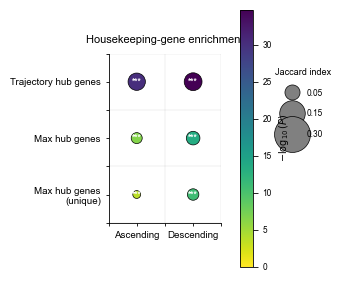

In [51]:
"""
Housekeeping-gene enrichment: ascending vs. descending hub-gene trajectories
============================================================================

Produces a Nature-style bubble/dot heatmap:
    - rows    = hub-gene list variant (trajectory hubs / max hubs / max hubs, unique)
    - columns = trajectory direction (ascending / descending)
    - dot size  -> Jaccard index of the overlap with housekeeping_gene_list
    - dot color -> enrichment significance (-log10 p-value, Fisher's exact test)

This is self-contained: it recomputes Jaccard index and Fisher's exact p-value
directly from a background gene universe, rather than relying on the internals
of `overlap_genelists`, so the two encodings (size, color) are guaranteed to be
consistent with each other.

Requires: ascending_trj_hub_genelist, descending_trj_hub_genelist,
          ascending_max_hub_gene_list, descending_max_hub_gene_list,
          ascending_max_hub_gene_list_unique, descending_max_hub_gene_list_unique,
          housekeeping_gene_list, and a `background_genes` universe
          (e.g. all genes in the PPI network) already defined in your session.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import fisher_exact

# ----------------------------------------------------------------------
# 0. Nature-style rcParams
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": 7,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "pdf.fonttype": 42,   # editable text in Illustrator
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


# ----------------------------------------------------------------------
# 1. Enrichment statistics (Jaccard index + Fisher's exact p-value)
# ----------------------------------------------------------------------
def enrichment_stats(set_a, set_b, background):
    """
    Jaccard index and one-sided (over-representation) Fisher's exact p-value
    for the overlap of set_a and set_b within a shared background universe.
    """
    background = set(background)
    a = set(set_a) & background
    b = set(set_b) & background

    intersection = a & b
    union = a | b
    jaccard = len(intersection) / len(union) if union else 0.0

    n_total = len(background)
    n_a_only = len(a - b)
    n_b_only = len(b - a)
    n_neither = n_total - len(a | b)

    table = [[len(intersection), n_b_only],
             [n_a_only, n_neither]]
    _, p_value = fisher_exact(table, alternative="greater")

    return jaccard, p_value


# ----------------------------------------------------------------------
# 2. Assemble the comparisons
# ----------------------------------------------------------------------
row_labels = [
    "Trajectory hub genes",
    "Max hub genes",
    "Max hub genes\n(unique)",
]

ascending_lists = [
    ascending_trj_hub_genelist,
    ascending_max_hub_gene_list,
    ascending_max_hub_gene_list_unique,
]

descending_lists = [
    descending_trj_hub_genelist,
    descending_max_hub_gene_list,
    descending_max_hub_gene_list_unique,
]

col_labels = ["Ascending", "Descending"]


background = set(G_ppi.nodes())

n_rows, n_cols = len(row_labels), len(col_labels)
jaccard_mat = np.zeros((n_rows, n_cols))
pval_mat = np.ones((n_rows, n_cols))

for i, (asc_list, desc_list) in enumerate(zip(ascending_lists, descending_lists)):
    for j, gene_list in enumerate([asc_list, desc_list]):
        jacc, p = enrichment_stats(housekeeping_gene_list, gene_list, background)
        jaccard_mat[i, j] = jacc
        pval_mat[i, j] = p

neglog10_p = -np.log10(np.clip(pval_mat, 1e-300, None))


# ----------------------------------------------------------------------
# 3. Plot: bubble / dot heatmap
# ----------------------------------------------------------------------
fig_width_in = 89 / 25.4    # single-column Nature width (89 mm)
fig_height_in = 1.55 * fig_width_in * (n_rows / 4)
fig, ax = plt.subplots(figsize=(fig_width_in, max(fig_height_in, 2.0)))

x_coords, y_coords = np.meshgrid(np.arange(n_cols), np.arange(n_rows))

# Scale Jaccard (0-1, typically small) to a legible marker-size range
size_scale = 2200
sizes = jaccard_mat.flatten() * size_scale + 8  # small floor so 0 is still visible as a dot

cmap = plt.cm.viridis_r
vmin, vmax = 0, max(neglog10_p.max(), 2)  # ensure colorbar is informative even for small effects

sc = ax.scatter(
    x_coords.flatten(), y_coords.flatten(),
    s=sizes, c=neglog10_p.flatten(),
    cmap=cmap, vmin=vmin, vmax=vmax,
    edgecolors="black", linewidths=0.5, zorder=3,
)

# Significance asterisks
sig_thresholds = [(0.001, "***"), (0.01, "**"), (0.05, "*")]
for i in range(n_rows):
    for j in range(n_cols):
        p = pval_mat[i, j]
        label = next((s for thr, s in sig_thresholds if p < thr), "")
        if label:
            ax.text(j, i, label, ha="center", va="center",
                    fontsize=6, color="white", fontweight="bold", zorder=4)

# Axes cosmetics
ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels(col_labels)
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(row_labels)
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(n_rows - 0.5, -0.5)
ax.set_aspect("equal")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(length=2)
ax.set_title("Housekeeping-gene enrichment", fontsize=8, pad=8)

# Faint gridlines to guide the eye across the dot grid
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="grey", linewidth=0.3, alpha=0.3, zorder=0)

# Colorbar for -log10(p-value)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.12)
cbar.set_label(r"$-\log_{10}(P)$", fontsize=7)
cbar.ax.tick_params(labelsize=6)

# Size legend for Jaccard index
legend_jaccard_values = [0.05, 0.15, 0.30]
legend_handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="grey", markeredgecolor="black", markeredgewidth=0.5,
           markersize=np.sqrt(v * size_scale + 8), label=f"{v:.2f}")
    for v in legend_jaccard_values
]
legend = ax.legend(
    handles=legend_handles, title="Jaccard index",
    loc="upper left", bbox_to_anchor=(1.35, 1.0),
    frameon=False, fontsize=6, title_fontsize=6.5,
    labelspacing=1.4, borderpad=1.2,
)

fig.tight_layout()

# ----------------------------------------------------------------------
# 4. Save at publication quality
# ----------------------------------------------------------------------
fig.savefig("Figures/housekeeping_enrichment_bubble_heatmap_female.pdf",
            dpi=600, bbox_inches="tight")
fig.savefig("Figures/housekeeping_enrichment_bubble_heatmap_female.svg",
            dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
def enrichment_from_genelist(gene_list,libraries):   #This function returns the enrichment df for GOBP,GOCC,GOMF,KeGG  
    import gseapy as gp
    enr_df_dict={}
    for l in libraries:
        enr_df = gp.enrichr(gene_list=gene_list,
                             gene_sets=l,
                             organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                             outdir=None, # don't write to disk
                            )
        enr_df_dict[l]=enr_df

    return enr_df_dict

lib_list=['GO_Biological_Process_2025']


In [ ]:



ascending_trj_hub_enr_dict=enrichment_from_genelist(ascending_trj_hub_genelist,lib_list)
descending_trj_hub_enr_dict=enrichment_from_genelist(descending_trj_hub_genelist,lib_list)

In [57]:
ascending_trj_hub_enr_aggdf=pd.concat([v.res2d for v in list(ascending_trj_hub_enr_dict.values())], join="inner")


In [59]:
ascending_trj_hub_enr_aggdf[ascending_trj_hub_enr_aggdf["Adjusted P-value"]<0.05]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Apoptotic Process (GO:0042981),103/704,3.043350e-41,1.086780e-37,0,0,6.287542,586.583807,APP;MRE11;TFRC;YEATS4;PARK7;TNF;CLU;IKZF3;ETS1...
1,GO_Biological_Process_2025,Positive Regulation of DNA-templated Transcrip...,134/1274,1.023014e-37,1.826591e-34,0,0,4.458602,379.752069,APP;SMARCB1;HNRNPU;YEATS4;PARK7;RBPJ;NR3C1;TNF...
2,GO_Biological_Process_2025,Positive Regulation of Intracellular Signal Tr...,91/652,1.062698e-34,1.264965e-31,0,0,5.827190,455.844049,ITGB1;YWHAE;APP;DDX3X;TFRC;THRA;IRS1;PTEN;ILK;...
3,GO_Biological_Process_2025,Negative Regulation of Apoptotic Process (GO:0...,75/475,3.371564e-32,3.009964e-29,0,0,6.592014,477.705753,RB1;ITGB1;GSK3B;MRE11;DDX3X;TFRC;HSPB1;PARK7;C...
4,GO_Biological_Process_2025,Negative Regulation of DNA-templated Transcrip...,108/1006,7.005957e-31,5.003654e-28,0,0,4.385367,304.490810,RB1;APP;UBE2D3;ATN1;HNRNPU;KEAP1;ENO1;IKZF1;RB...
...,...,...,...,...,...,...,...,...,...,...
1479,GO_Biological_Process_2025,Integrated Stress Response Signaling (GO:0140467),4/34,1.977491e-02,4.764926e-02,0,0,4.223677,16.570927,CEBPA;JUN;FOS;EIF2S1
1480,GO_Biological_Process_2025,Regulation of Cardiac Muscle Contraction (GO:0...,4/34,1.977491e-02,4.764926e-02,0,0,4.223677,16.570927,ATP2A2;PRKCA;CALM1;CALM2
1481,GO_Biological_Process_2025,Regulation of Response to Biotic Stimulus (GO:...,4/34,1.977491e-02,4.764926e-02,0,0,4.223677,16.570927,CASP8;DAPK1;TRAF3;XIAP
1482,GO_Biological_Process_2025,Positive Regulation of Actin Filament Bundle A...,5/51,1.984988e-02,4.779765e-02,0,0,3.446009,13.506828,TPM1;LPAR1;NF2;RHOA;TGFBR1


In [ ]:
descending_trj_hub_enr_aggdf=pd.concat([v.res2d for v in list(descending_trj_hub_enr_dict.values())], join="inner")
descending_trj_hub_enr_aggdf[descending_trj_hub_enr_aggdf["Adjusted P-value"]<0.05]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Apoptotic Process (GO:0042981),101/704,7.904606e-39,2.826687e-35,0,0,5.965331,523.358651,APP;MRE11;TFRC;YEATS4;PARK7;TNF;CLU;IKZF3;ETS1...
1,GO_Biological_Process_2025,Positive Regulation of DNA-templated Transcrip...,134/1274,1.098987e-36,1.964989e-33,0,0,4.338177,359.195340,APP;TCERG1;SMARCB1;HNRNPU;YEATS4;PARK7;RBPJ;NR...
2,GO_Biological_Process_2025,Protein Phosphorylation (GO:0006468),70/373,2.134149e-34,2.543906e-31,0,0,7.894945,612.093736,GSK3B;TP53RK;LRRK2;IGF1R;IKBKB;STK11;TBK1;CHEK...
3,GO_Biological_Process_2025,Negative Regulation of Apoptotic Process (GO:0...,77/475,3.153576e-33,2.819297e-30,0,0,6.662158,498.574418,RB1;GSK3B;MRE11;TFRC;HSPB1;PARK7;CLU;TNF;ICAM1...
4,GO_Biological_Process_2025,Positive Regulation of Transcription by RNA Po...,110/983,3.034545e-32,2.170306e-29,0,0,4.499839,326.565262,APP;TCERG1;SMARCB1;HNRNPU;PARK7;RBPJ;NR3C1;TNF...
...,...,...,...,...,...,...,...,...,...,...
1513,GO_Biological_Process_2025,Regulation of Type II Interferon Production (G...,7/88,2.069969e-02,4.889174e-02,0,0,2.684579,10.409821,NDUFA2;RARA;HMGB1;HLA-A;TYK2;JAK2;HSPD1
1514,GO_Biological_Process_2025,JNK Cascade (GO:0007254),4/34,2.117501e-02,4.988264e-02,0,0,4.132906,15.932077,MAPK9;MAPK8;DAXX;LRRK2
1515,GO_Biological_Process_2025,Liver Development (GO:0001889),4/34,2.117501e-02,4.988264e-02,0,0,4.132906,15.932077,CEBPA;CEBPB;NF1;AURKA
1516,GO_Biological_Process_2025,Regulation of Cardiac Muscle Contraction (GO:0...,4/34,2.117501e-02,4.988264e-02,0,0,4.132906,15.932077,ATP2A2;PRKCA;CALM1;CALM2


In [62]:
def enrichment_from_genelist(gene_list, libraries, permutation_num=1000, seed=0, threads=4):
    """
    Prerank GSEA enrichment, weighting genes by their frequency in gene_list
    (i.e. genes appearing multiple times are ranked higher).
    Returns a dict of {library_name: prerank_result}.
    """
    import gseapy as gp
    import pandas as pd
    from collections import Counter

    # Collapse repeats into a single row per gene, using frequency as the rank metric
    gene_freq = Counter(gene_list)
    rnk = (
        pd.DataFrame({'gene': list(gene_freq.keys()), 'freq': list(gene_freq.values())})
        .sort_values('freq', ascending=False)
        .reset_index(drop=True)
    )

    enr_df_dict = {}
    for l in libraries:
        pre_res = gp.prerank(
            rnk=rnk,                 # two-column DataFrame: gene, score
            gene_sets=l,
            organism='human',        # match to your species
            permutation_num=permutation_num,
            seed=seed,
            threads=threads,
            outdir=None,             # don't write to disk
        )
        enr_df_dict[l] = pre_res

    return enr_df_dict


lib_list = ['GO_Biological_Process_2025']

In [79]:
female_ascending_trj_hub_enr_dict=enrichment_from_genelist(ascending_trj_hub_genelist,lib_list)
female_descending_trj_hub_enr_dict=enrichment_from_genelist(descending_trj_hub_genelist,lib_list)
female_descending_trj_hub_enr_aggdf=pd.concat([v.res2d for v in list(female_descending_trj_hub_enr_dict.values())], join="inner")
sig_female_descending_enrichment_term = len(female_descending_trj_hub_enr_aggdf[female_descending_trj_hub_enr_aggdf["FDR q-val"]<0.05])
female_ascending_trj_hub_enr_aggdf=pd.concat([v.res2d for v in list(female_ascending_trj_hub_enr_dict.values())], join="inner")
sig_female_ascending_enrichment_term = len(female_ascending_trj_hub_enr_aggdf[female_ascending_trj_hub_enr_aggdf["FDR q-val"]<0.05])


2026-07-26 16:00:44,624 [WARNING] Duplicated values found in preranked stats: 96.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-07-26 16:00:44,922 [WARNING] Duplicated values found in preranked stats: 96.66% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


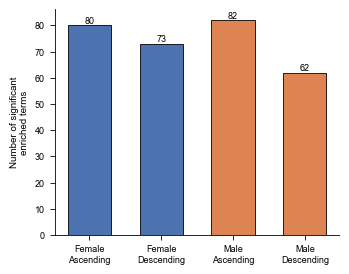

In [82]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": 7,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

labels = ["Female\nAscending", "Female\nDescending", "Male\nAscending", "Male\nDescending"]
values = [
    sig_female_ascending_enrichment_term,
    sig_female_descending_enrichment_term,
    sig_male_ascending_enrichment_term,
    sig_male_descending_enrichment_term,
]
colors = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452"]  # blue = female, orange = male

fig, ax = plt.subplots(figsize=(89 / 25.4, 70 / 25.4))  # single-column Nature width

bars = ax.bar(labels, values, color=colors, edgecolor="black", linewidth=0.6, width=0.6)

# value labels on top of each bar
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v, str(v),
             ha="center", va="bottom", fontsize=6.5)

ax.set_ylabel("Number of significant\nenriched terms", fontsize=7)
ax.tick_params(axis="both", labelsize=6.5)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
fig.savefig("Figures/sig_enrichment_counts_barplot.pdf", dpi=600, bbox_inches="tight")
fig.savefig("Figures/sig_enrichment_counts_barplot.svg", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
from scipy.stats import fisher_exact, linregress

UP = "Mortality/"
PICKLE_DIR = "output/"
SUMMARY_FILE = "summary_all_diagfilterd.csv"
MIN_DISEASES = 2


def combined_mortality_M(m_vals):
    """Probability exactly one co-occurring mortality event happens."""
    if len(m_vals) <= 1:
        return m_vals[0] if m_vals else None
    return sum(m_vals[i] * pd.Series([1 - m_vals[j] for j in range(len(m_vals)) if j != i]).prod()
               for i in range(len(m_vals)))


def get_timeline(members_str):
    """[(age_bracket, [codes]), ...] grouped by shared age bracket, in order."""
    seen, groups = [], {}
    for entry in members_str.split(","):
        entry = entry.strip().replace("__", "-")
        code, age = entry.split("-")[0], "-".join(entry.split("-")[1:])
        if age not in seen:
            seen.append(age)
            groups[age] = []
        groups[age].append(code)
    return [(age, groups[age]) for age in seen]


def compute_growing(sex, id_col, members_col, mort, los, hosp, length_map):
    raw = pd.read_excel(UP + f"All_identified_trajectories_in_{sex}s_trajectories_smaller_than_100_members.xlsx")
    status = pd.read_csv(UP + f"{sex}_trj_evolving_status_df_official.csv")
    id_to_status = dict(zip(status["trj"], status["status"]))

    rows = []
    for _, r in raw.iterrows():
        trj = r[id_col]
        st = id_to_status.get(trj)
        if st not in ("Ascending", "Descending"):
            continue

        m_series, l_series, h_series = {}, {}, {}
        for age, codes in get_timeline(r[members_col]):
            mid = (int(age.split("-")[0]) + int(age.split("-")[1])) / 2
            m = [mort[c] for c in codes if c in mort]
            l = [los[c] for c in codes if c in los]
            h = [hosp[c] for c in codes if c in hosp]
            if m: m_series[mid] = combined_mortality_M(m)
            if l: l_series[mid] = sum(l)
            if h: h_series[mid] = sum(h)

        row = {"sex": sex, "trj": trj, "status": st, "n_diseases": length_map.get(trj)}
        for name, series in [("mortality", m_series), ("los", l_series), ("hosp", h_series)]:
            if len(series) >= 2:
                slope, *_ = linregress(list(series.keys()), list(series.values()))
                row[f"{name}_growing"] = int(slope > 0)
        rows.append(row)
    return pd.DataFrame(rows)


def report(label, df):
    print(f"\n{label}")
    for outcome in ["mortality_growing", "los_growing", "hosp_growing"]:
        d = df.dropna(subset=[outcome])
        asc, desc = d[d.status == "Ascending"][outcome], d[d.status == "Descending"][outcome]
        a_g, d_g = int((asc > 0).sum()), int((desc > 0).sum())
        _, p = fisher_exact([[a_g, d_g], [len(asc) - a_g, len(desc) - d_g]])
        print(f"  {outcome}: Asc {a_g}/{len(asc)} ({100*a_g/len(asc):.1f}%)  "
              f"Desc {d_g}/{len(desc)} ({100*d_g/len(desc):.1f}%)  p={p:.4f}")


# --- run ---
df_sum = pd.read_csv(UP + SUMMARY_FILE)
mort = dict(zip(df_sum.icd_code, df_sum.mortality_rate))
los = dict(zip(df_sum.icd_code, df_sum.avg_los_days))
hosp = dict(zip(df_sum.icd_code, df_sum.avg_stays_per_patient))

length_maps = {}
for sex in ["male", "female"]:
    with open(PICKLE_DIR + f"{sex}_trajectories_dict_filtered.pickle", "rb") as f:
        length_maps[sex] = {trj: len(dis) for trj, dis in pk.load(f).items()}

male = compute_growing("male", "Community_ID", "Members of community", mort, los, hosp, length_maps["male"])
female = compute_growing("female", "Community ID", "Members", mort, los, hosp, length_maps["female"])
combined = pd.concat([male, female], ignore_index=True)

report("MALE", male)
report("FEMALE", female)
report("COMBINED", combined)

filtered = combined[combined.n_diseases > MIN_DISEASES]
report(f"MALE (filtered > {MIN_DISEASES})", filtered[filtered.sex == "male"])
report(f"FEMALE (filtered > {MIN_DISEASES})", filtered[filtered.sex == "female"])
report(f"COMBINED (filtered > {MIN_DISEASES})", filtered)

combined.to_csv("version1_growing_results.csv", index=False)